In [1]:
# ============================================================
# STEP 0: Install and Load Required Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "DESeq2",
  "sva",
  "edgeR",
  "org.Hs.eg.db",
  "AnnotationDbi"
), update = FALSE)

install.packages(c("ggplot2", "data.table", "stringr", "dplyr"))

library(DESeq2)
library(sva)
library(edgeR)
library(org.Hs.eg.db)
library(AnnotationDbi)
library(ggplot2)
library(data.table)
library(stringr)
library(dplyr)

cat("All packages loaded successfully\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'sva' 'edgeR' 'org.Hs.eg.db'
  'AnnotationDbi'"
Installing packages into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'ggplot2' successfully unpacked and MD5 sums checked
package 'data.table' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'data.table'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\data.table\libs\x64\data_table.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\data.table\libs\x64\data_table.dll: Permission denied"
Warning message:
"restored 'data.table'"


package 'stringr' successfully unpacked and MD5 sums checked
package 'dplyr' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'dplyr'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\dplyr\libs\x64\dplyr.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\dplyr\libs\x64\dplyr.dll: Permission denied"
Warning message:
"restored 'dplyr'"



The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpyMs7r4\downloaded_packages


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: 'S4Vectors'


The following object is masked from 'package:utils':

    findMatches


The follo

All packages loaded successfully


In [2]:
# ============================================================
# STEP 1: Load Your STAR Count Files
# ============================================================

# --- Define your file paths ---
path_lusc <- "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz"
path_luad <- "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz"

# --- Read the files ---
# fread() from data.table is used because these files are very large
# It reads .gz compressed files automatically — no need to unzip manually

cat("Loading TCGA-LUSC file...\n")
lusc_raw <- fread(path_lusc, header = TRUE, sep = "\t")

cat("Loading TCGA-LUAD file...\n")
luad_raw <- fread(path_luad, header = TRUE, sep = "\t")

# --- Remove the first 4 STAR summary rows ---
# These rows start with "N_" and are NOT real genes
# Keeping them would corrupt your count matrix

lusc_raw <- lusc_raw[!grepl("^N_", lusc_raw[[1]]), ]
luad_raw <- luad_raw[!grepl("^N_", luad_raw[[1]]), ]

# --- Quick inspection ---
cat("\n--- LUSC: dimensions ---\n")
cat(sprintf("Rows (genes): %d | Columns: %d\n", nrow(lusc_raw), ncol(lusc_raw)))

cat("\n--- LUAD: dimensions ---\n")
cat(sprintf("Rows (genes): %d | Columns: %d\n", nrow(luad_raw), ncol(luad_raw)))

# --- Look at the first few column names ---
cat("\n--- LUSC column names ---\n")
print(colnames(lusc_raw))

cat("\n--- First 3 rows of LUSC (gene info columns only) ---\n")
print(lusc_raw[1:3, 1:6])

Loading TCGA-LUSC file...
Loading TCGA-LUAD file...

--- LUSC: dimensions ---
Rows (genes): 60660 | Columns: 553

--- LUAD: dimensions ---
Rows (genes): 60660 | Columns: 590

--- LUSC column names ---
  [1] "Ensembl_ID"       "TCGA-60-2698-01A" "TCGA-33-4589-01A"
  [4] "TCGA-18-3410-01A" "TCGA-60-2715-01A" "TCGA-22-5471-01A"
  [7] "TCGA-21-1070-01A" "TCGA-NK-A5D1-01A" "TCGA-18-3407-01A"
 [10] "TCGA-60-2710-01A" "TCGA-56-8623-11A" "TCGA-56-8504-01A"
 [13] "TCGA-43-7658-01A" "TCGA-90-6837-01A" "TCGA-90-7964-01A"
 [16] "TCGA-33-4532-01A" "TCGA-43-8115-01A" "TCGA-43-A475-01A"
 [19] "TCGA-22-5481-11A" "TCGA-22-5481-01A" "TCGA-68-A59J-01A"
 [22] "TCGA-66-2780-01A" "TCGA-22-4605-01A" "TCGA-22-5478-11A"
 [25] "TCGA-L3-A524-01A" "TCGA-63-A5MI-01A" "TCGA-77-8139-01A"
 [28] "TCGA-34-7107-11A" "TCGA-34-7107-01A" "TCGA-56-A5DS-01A"
 [31] "TCGA-MF-A522-01A" "TCGA-85-A4QQ-01A" "TCGA-66-2786-01A"
 [34] "TCGA-63-A5MJ-01A" "TCGA-63-A5MM-01A" "TCGA-51-4079-11A"
 [37] "TCGA-79-5596-01A" "TCGA-66-2777-01A"

In [3]:
# ============================================================
# STEP 2: Inspect Data + Map Ensembl IDs → HGNC Gene Symbols
# ============================================================

# --- PART A: Confirm what values are in your matrix ---
# This is critical — it tells us which normalization path to take

cat("=== Checking value types in your data ===\n\n")

# Extract just the numeric sample columns (everything except Ensembl_ID)
sample_cols_lusc <- colnames(lusc_raw)[-1]  # Remove first column (Ensembl_ID)

# Look at a sample of values
sample_values <- as.numeric(lusc_raw[1:10, ..sample_cols_lusc][[1]])
cat("First 10 values from sample 1:\n")
print(round(sample_values, 3))

# Check if values are integers (raw counts) or decimals (normalized)
are_integers <- all(sample_values == floor(sample_values), na.rm = TRUE)

if (are_integers) {
  cat("\n✔ Values appear to be RAW INTEGER COUNTS\n")
  cat("→ We will apply VST normalization via DESeq2\n")
  data_type <- "raw_counts"
} else {
  cat("\n⚠ Values appear to be ALREADY NORMALIZED (decimals detected)\n")
  cat("→ These may be log2-transformed TPM or FPKM values\n")
  cat("→ We will NOT apply VST (cannot normalize already-normalized data)\n")
  cat("→ We will use these values directly after batch correction\n")
  data_type <- "normalized"
}

cat(sprintf("\nValue range: [%.3f, %.3f]\n",
    min(as.matrix(lusc_raw[, -1])),
    max(as.matrix(lusc_raw[, -1]))))

=== Checking value types in your data ===

First 10 values from sample 1:
 [1] 12.003  0.000 10.725 10.588 10.316 10.948 11.635 12.062 12.985 10.849

⚠ Values appear to be ALREADY NORMALIZED (decimals detected)
→ These may be log2-transformed TPM or FPKM values
→ We will NOT apply VST (cannot normalize already-normalized data)
→ We will use these values directly after batch correction

Value range: [0.000, 21.838]


In [4]:
# --- PART B: Strip version numbers from Ensembl IDs ---

cat("\n=== Cleaning Ensembl IDs ===\n")

strip_version <- function(ids) {
  gsub("\\.\\d+$", "", ids)
}

lusc_raw$Ensembl_clean <- strip_version(lusc_raw$Ensembl_ID)
luad_raw$Ensembl_clean <- strip_version(luad_raw$Ensembl_ID)

# Verify it worked
cat("Before cleaning:", lusc_raw$Ensembl_ID[1], "\n")
cat("After cleaning: ", lusc_raw$Ensembl_clean[1], "\n")


=== Cleaning Ensembl IDs ===
Before cleaning: ENSG00000000003.15 
After cleaning:  ENSG00000000003 


In [5]:
# --- PART C: Map Ensembl IDs to HGNC Gene Symbols ---

cat("\n=== Mapping Ensembl IDs to HGNC Gene Symbols ===\n")

map_to_hgnc <- function(df, dataset_name) {
  
  cat(sprintf("Mapping %s...\n", dataset_name))
  
  gene_symbols <- mapIds(
    org.Hs.eg.db,
    keys      = df$Ensembl_clean,
    column    = "SYMBOL",
    keytype   = "ENSEMBL",
    multiVals = "first"
  )
  
  df$HGNC_symbol <- gene_symbols
  
  total    <- nrow(df)
  mapped   <- sum(!is.na(df$HGNC_symbol))
  unmapped <- sum(is.na(df$HGNC_symbol))
  
  cat(sprintf("  Total genes:  %d\n", total))
  cat(sprintf("  Mapped:       %d (%.1f%%)\n", mapped, mapped/total*100))
  cat(sprintf("  Unmapped:     %d (will be removed)\n", unmapped))
  
  # Remove unmapped genes
  df_mapped <- df[!is.na(df$HGNC_symbol), ]
  
  return(df_mapped)
}

lusc_mapped <- map_to_hgnc(lusc_raw, "TCGA-LUSC")
luad_mapped <- map_to_hgnc(luad_raw, "TCGA-LUAD")

# Preview
cat("\n--- Preview: first 5 genes after mapping ---\n")
print(lusc_mapped[1:5, c("Ensembl_ID", "Ensembl_clean", "HGNC_symbol")])


=== Mapping Ensembl IDs to HGNC Gene Symbols ===
Mapping TCGA-LUSC...


'select()' returned 1:many mapping between keys and columns



  Total genes:  60660
  Mapped:       36748 (60.6%)
  Unmapped:     23912 (will be removed)
Mapping TCGA-LUAD...


'select()' returned 1:many mapping between keys and columns



  Total genes:  60660
  Mapped:       36748 (60.6%)
  Unmapped:     23912 (will be removed)

--- Preview: first 5 genes after mapping ---
           Ensembl_ID   Ensembl_clean HGNC_symbol
               <char>          <char>      <char>
1: ENSG00000000003.15 ENSG00000000003      TSPAN6
2:  ENSG00000000005.6 ENSG00000000005        TNMD
3: ENSG00000000419.13 ENSG00000000419        DPM1
4: ENSG00000000457.14 ENSG00000000457       SCYL3
5: ENSG00000000460.17 ENSG00000000460       FIRRM


In [6]:
# ============================================================
# STEP 3: Build Clean Expression Matrix
# ============================================================

# --- PART A: Extract sample columns + gene symbols only ---
# We no longer need Ensembl_ID or Ensembl_clean columns
# Rows = genes, Columns = samples

cat("=== Building Expression Matrix ===\n\n")

build_expression_matrix <- function(df_mapped, dataset_name) {
  
  cat(sprintf("Processing %s...\n", dataset_name))
  
  # Identify sample columns (they all start with "TCGA-")
  all_cols     <- colnames(df_mapped)
  sample_cols  <- all_cols[grepl("^TCGA-", all_cols)]
  
  cat(sprintf("  → Found %d sample columns\n", length(sample_cols)))
  
  # Extract numeric matrix with gene symbols
  expr_mat <- as.matrix(df_mapped[, ..sample_cols])
  rownames(expr_mat) <- df_mapped$HGNC_symbol
  
  cat(sprintf("  → Matrix dimensions: %d genes × %d samples\n",
              nrow(expr_mat), ncol(expr_mat)))
  
  return(expr_mat)
}

lusc_mat <- build_expression_matrix(lusc_mapped, "TCGA-LUSC")
luad_mat <- build_expression_matrix(luad_mapped, "TCGA-LUAD")

=== Building Expression Matrix ===

Processing TCGA-LUSC...
  → Found 552 sample columns
  → Matrix dimensions: 36748 genes × 552 samples
Processing TCGA-LUAD...
  → Found 589 sample columns
  → Matrix dimensions: 36748 genes × 589 samples


In [7]:
# --- PART B: Handle Duplicate Gene Symbols ---
# Keep the row with the highest average expression across samples
# This is the most common and accepted approach

cat("\n=== Handling Duplicate Gene Symbols ===\n\n")

remove_duplicates <- function(expr_mat, dataset_name) {
  
  cat(sprintf("Processing %s...\n", dataset_name))
  
  # Count duplicates before removal
  dup_count <- sum(duplicated(rownames(expr_mat)))
  cat(sprintf("  → Duplicate gene symbols found: %d\n", dup_count))
  
  if (dup_count == 0) {
    cat("  → No duplicates — matrix is clean\n")
    return(expr_mat)
  }
  
  # Calculate average expression per row
  row_means <- rowMeans(expr_mat, na.rm = TRUE)
  
  # Order by mean expression (highest first)
  expr_mat_ordered <- expr_mat[order(-row_means), ]
  
  # Keep first occurrence of each gene symbol (= highest expressed)
  expr_mat_clean <- expr_mat_ordered[!duplicated(rownames(expr_mat_ordered)), ]
  
  cat(sprintf("  → Genes before deduplication: %d\n", nrow(expr_mat)))
  cat(sprintf("  → Genes after deduplication:  %d\n", nrow(expr_mat_clean)))
  
  return(expr_mat_clean)
}

lusc_clean <- remove_duplicates(lusc_mat, "TCGA-LUSC")
luad_clean <- remove_duplicates(luad_mat, "TCGA-LUAD")


=== Handling Duplicate Gene Symbols ===

Processing TCGA-LUSC...
  → Duplicate gene symbols found: 98
  → Genes before deduplication: 36748
  → Genes after deduplication:  36650
Processing TCGA-LUAD...
  → Duplicate gene symbols found: 98
  → Genes before deduplication: 36748
  → Genes after deduplication:  36650


In [8]:
# --- PART C: Final check on both matrices ---

cat("\n=== Final Matrix Summary ===\n")

cat("\nLUSC matrix:\n")
cat(sprintf("  Genes:   %d\n", nrow(lusc_clean)))
cat(sprintf("  Samples: %d\n", ncol(lusc_clean)))
cat(sprintf("  Value range: [%.3f, %.3f]\n",
            min(lusc_clean), max(lusc_clean)))

cat("\nLUAD matrix:\n")
cat(sprintf("  Genes:   %d\n", nrow(luad_clean)))
cat(sprintf("  Samples: %d\n", ncol(luad_clean)))
cat(sprintf("  Value range: [%.3f, %.3f]\n",
            min(luad_clean), max(luad_clean)))

# Preview top-left corner of matrix
cat("\n--- Preview: LUSC matrix (5 genes × 4 samples) ---\n")
print(round(lusc_clean[1:5, 1:4], 3))


=== Final Matrix Summary ===

LUSC matrix:
  Genes:   36650
  Samples: 552
  Value range: [0.000, 21.838]

LUAD matrix:
  Genes:   36650
  Samples: 589
  Value range: [0.000, 22.391]

--- Preview: LUSC matrix (5 genes × 4 samples) ---
       TCGA-60-2698-01A TCGA-33-4589-01A TCGA-18-3410-01A TCGA-60-2715-01A
MT-CO1           18.175           16.405           18.572           19.645
MT-ND4           17.739           15.521           17.440           19.206
ACTB             18.820           18.710           18.054           18.788
EEF1A1           18.733           17.715           18.904           18.473
FTL              18.420           18.520           17.002           18.806


In [9]:
# ============================================================
# STEP 4: Merge LUSC and LUAD into One Combined Matrix
# ============================================================

# --- PART A: Find common genes between both datasets ---

cat("=== Merging Datasets ===\n\n")

# Find genes present in BOTH matrices
common_genes <- intersect(rownames(lusc_clean), rownames(luad_clean))

cat(sprintf("Genes in LUSC:          %d\n", nrow(lusc_clean)))
cat(sprintf("Genes in LUAD:          %d\n", nrow(luad_clean)))
cat(sprintf("Common genes (kept):    %d\n", length(common_genes)))
cat(sprintf("Genes dropped:          %d\n",
            nrow(lusc_clean) + nrow(luad_clean) - 2 * length(common_genes)))

=== Merging Datasets ===

Genes in LUSC:          36650
Genes in LUAD:          36650
Common genes (kept):    36650
Genes dropped:          0


In [10]:
# --- PART B: Subset both matrices to common genes ---
# This ensures both matrices have identical rows
# before we combine them side by side

lusc_common <- lusc_clean[common_genes, ]
luad_common <- luad_clean[common_genes, ]

# Confirm dimensions match on genes
cat(sprintf("\nLUSC subset: %d genes × %d samples\n",
            nrow(lusc_common), ncol(lusc_common)))
cat(sprintf("LUAD subset: %d genes × %d samples\n",
            nrow(luad_common), ncol(luad_common)))

# Confirm row order is identical (critical before merging)
identical_rows <- identical(rownames(lusc_common), rownames(luad_common))
cat(sprintf("\nRow order identical: %s\n",
            ifelse(identical_rows, "YES - safe to merge", "NO - something went wrong")))


LUSC subset: 36650 genes × 552 samples
LUAD subset: 36650 genes × 589 samples

Row order identical: YES - safe to merge


In [11]:
# --- PART C: Combine side by side (cbind) ---
# cbind = column bind = stick matrices side by side
# Rows (genes) stay the same, columns (samples) are combined

combined_matrix <- cbind(lusc_common, luad_common)

cat(sprintf("\n=== Combined Matrix ===\n"))
cat(sprintf("Total genes:    %d\n", nrow(combined_matrix)))
cat(sprintf("Total samples:  %d\n", ncol(combined_matrix)))
cat(sprintf("  LUSC samples: %d\n", ncol(lusc_common)))
cat(sprintf("  LUAD samples: %d\n", ncol(luad_common)))
cat(sprintf("Value range:    [%.3f, %.3f]\n",
            min(combined_matrix), max(combined_matrix)))


=== Combined Matrix ===
Total genes:    36650
Total samples:  1141
  LUSC samples: 552
  LUAD samples: 589
Value range:    [0.000, 22.391]


In [12]:
# --- PART D: Create batch labels ---
# This is very important for the next step (batch correction)
# We need to tell ComBat which samples came from which dataset
# LUSC = batch 1, LUAD = batch 2

batch_labels <- c(
  rep("LUSC", ncol(lusc_common)),
  rep("LUAD", ncol(luad_common))
)

# Verify labels match sample count
cat(sprintf("\n=== Batch Labels ===\n"))
cat(sprintf("LUSC labels: %d\n", sum(batch_labels == "LUSC")))
cat(sprintf("LUAD labels: %d\n", sum(batch_labels == "LUAD")))
cat(sprintf("Total labels: %d | Total samples: %d\n",
            length(batch_labels), ncol(combined_matrix)))

# They must be equal — if not something is wrong
if (length(batch_labels) == ncol(combined_matrix)) {
  cat("✔ Batch labels match sample count — ready for batch correction\n")
} else {
  cat("✘ ERROR: Mismatch between labels and samples — check your matrices\n")
}


=== Batch Labels ===
LUSC labels: 552
LUAD labels: 589
Total labels: 1141 | Total samples: 1141
✔ Batch labels match sample count — ready for batch correction


In [13]:
# --- PART E: Preview the combined matrix ---

cat("\n--- Preview: combined matrix (5 genes × 6 samples) ---\n")

# Show 3 LUSC + 3 LUAD samples side by side
preview_cols <- c(1:3, (ncol(lusc_common)+1):(ncol(lusc_common)+3))
print(round(combined_matrix[1:5, preview_cols], 3))

cat("\n--- Sample names confirm dataset source ---\n")
cat("First 3 columns (should be LUSC barcodes):\n")
print(colnames(combined_matrix)[1:3])
cat("Last 3 columns (should be LUAD barcodes):\n")
print(tail(colnames(combined_matrix), 3))


--- Preview: combined matrix (5 genes × 6 samples) ---
       TCGA-60-2698-01A TCGA-33-4589-01A TCGA-18-3410-01A TCGA-38-7271-01A
MT-CO1           18.175           16.405           18.572           18.358
MT-ND4           17.739           15.521           17.440           18.367
ACTB             18.820           18.710           18.054           17.812
EEF1A1           18.733           17.715           18.904           17.612
FTL              18.420           18.520           17.002           17.019
       TCGA-55-7914-01A TCGA-95-7043-01A
MT-CO1           17.439           18.758
MT-ND4           17.318           18.745
ACTB             17.704           16.267
EEF1A1           17.245           16.019
FTL              16.488           20.045

--- Sample names confirm dataset source ---
First 3 columns (should be LUSC barcodes):
[1] "TCGA-60-2698-01A" "TCGA-33-4589-01A" "TCGA-18-3410-01A"
Last 3 columns (should be LUAD barcodes):
[1] "TCGA-44-A47G-01A" "TCGA-55-6969-01A" "TCGA-55-6969-1

=== Visualizing data BEFORE batch correction ===

✔ PCA plot saved: PCA_before_batch_correction.png


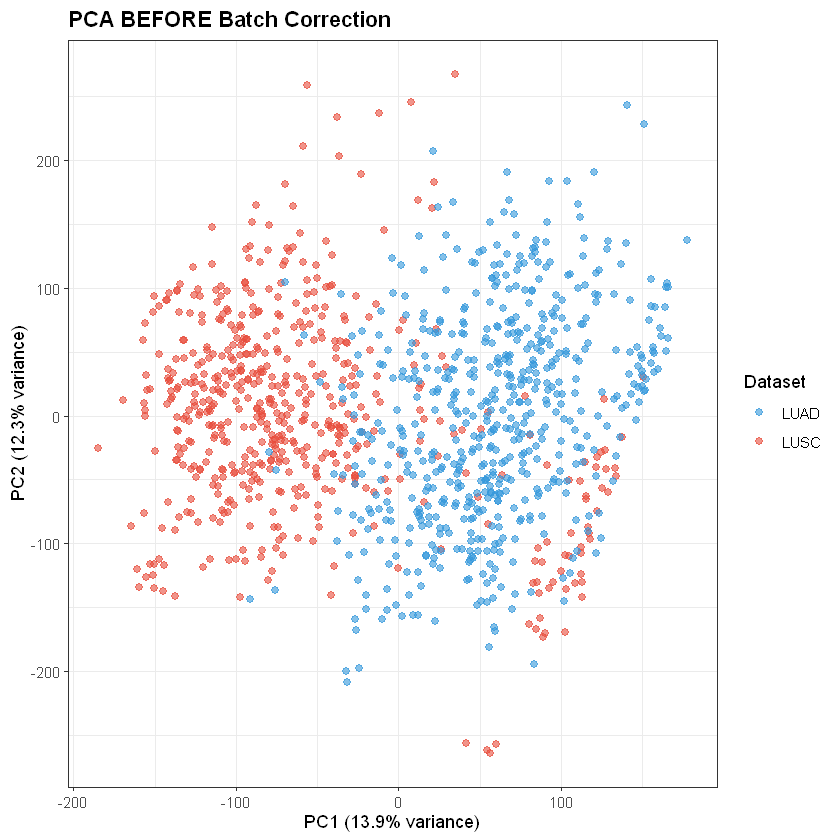

In [14]:
# ============================================================
# STEP 5: Batch Correction with ComBat
# ============================================================

# --- PART A: Visualize batch effect BEFORE correction ---
# We do a quick PCA to SEE the batch effect before removing it
# This helps confirm that batch correction actually worked

cat("=== Visualizing data BEFORE batch correction ===\n\n")

# PCA on combined matrix (transpose: samples as rows)
pca_before <- prcomp(t(combined_matrix), scale. = FALSE, center = TRUE)

# Build plotting dataframe
pca_before_df <- data.frame(
  PC1     = pca_before$x[, 1],
  PC2     = pca_before$x[, 2],
  Dataset = batch_labels,
  Sample  = colnames(combined_matrix)
)

# Calculate variance explained by PC1 and PC2
var_exp_before <- round(summary(pca_before)$importance[2, 1:2] * 100, 1)

# Plot
plot_before <- ggplot(pca_before_df, aes(x = PC1, y = PC2, color = Dataset)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_color_manual(values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")) +
  labs(
    title    = "PCA BEFORE Batch Correction",
    x        = sprintf("PC1 (%.1f%% variance)", var_exp_before[1]),
    y        = sprintf("PC2 (%.1f%% variance)", var_exp_before[2])
  ) +
  theme_bw() +
  theme(plot.title = element_text(face = "bold"))

# Save plot
ggsave("PCA_before_batch_correction.png", plot_before,
       width = 8, height = 6, dpi = 150)

cat("✔ PCA plot saved: PCA_before_batch_correction.png\n")
print(plot_before)

In [15]:
# --- PART B: Apply ComBat batch correction ---
# ComBat expects:
#   dat   = genes × samples matrix (rows = genes, cols = samples)
#   batch = vector of batch labels (one per sample)
# It returns a corrected matrix of the same dimensions

cat("\n=== Applying ComBat Batch Correction ===\n\n")
cat("This may take 1-3 minutes depending on matrix size...\n\n")

# Run ComBat
# mod = NULL means we are not protecting any biological covariate
# If you have tumor vs normal labels, you can add them here later
corrected_matrix <- ComBat(
  dat   = combined_matrix,   # genes × samples
  batch = batch_labels,      # "LUSC" or "LUAD" per sample
  mod   = NULL,              # No biological covariate to protect
  par.prior = TRUE,          # Parametric adjustment (faster, standard)
  prior.plots = FALSE        # Set TRUE if you want diagnostic plots
)

cat(sprintf("\n✔ Batch correction complete\n"))
cat(sprintf("Corrected matrix: %d genes × %d samples\n",
            nrow(corrected_matrix), ncol(corrected_matrix)))
cat(sprintf("Value range after correction: [%.3f, %.3f]\n",
            min(corrected_matrix), max(corrected_matrix)))


=== Applying ComBat Batch Correction ===

This may take 1-3 minutes depending on matrix size...

Found 1442 genes with uniform expression within a single batch (all zeros); these will not be adjusted for batch.


Found2batches

Adjusting for0covariate(s) or covariate level(s)

Standardizing Data across genes

Fitting L/S model and finding priors

Finding parametric adjustments

Adjusting the Data





✔ Batch correction complete
Corrected matrix: 36650 genes × 1141 samples
Value range after correction: [-4.758, 34.247]



=== Visualizing data AFTER batch correction ===
✔ PCA plot saved: PCA_after_batch_correction.png


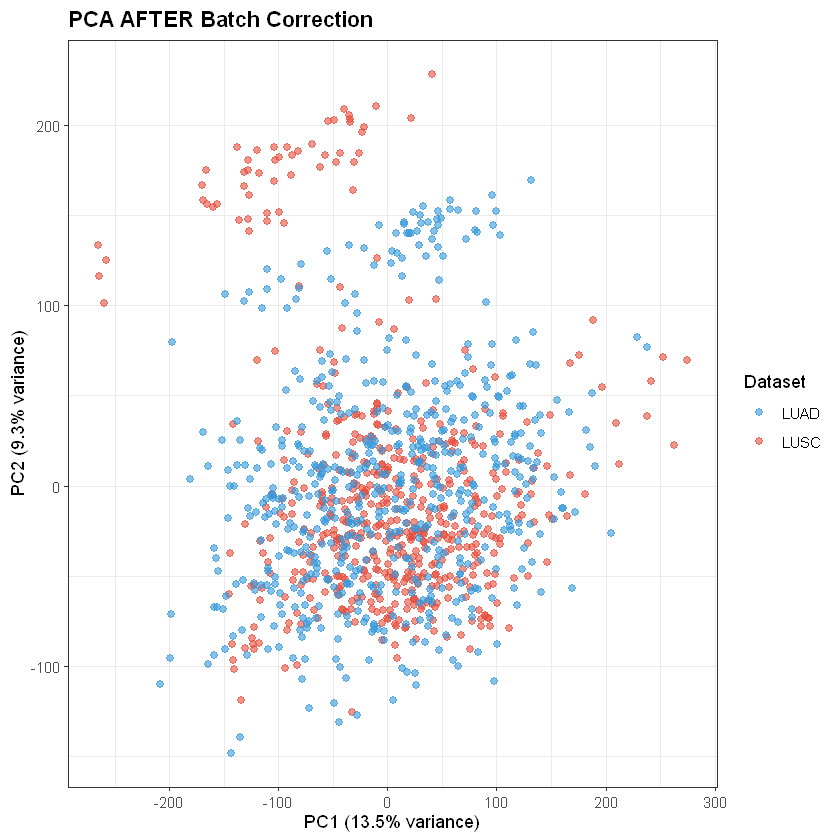

In [16]:
# --- PART C: Visualize AFTER correction ---
# Now we repeat the PCA on the corrected matrix
# If ComBat worked: LUSC and LUAD should be more intermixed
# They may still separate (that is BIOLOGY not batch effect)
# but the separation should be less extreme

cat("\n=== Visualizing data AFTER batch correction ===\n")

pca_after <- prcomp(t(corrected_matrix), scale. = FALSE, center = TRUE)

pca_after_df <- data.frame(
  PC1     = pca_after$x[, 1],
  PC2     = pca_after$x[, 2],
  Dataset = batch_labels,
  Sample  = colnames(corrected_matrix)
)

var_exp_after <- round(summary(pca_after)$importance[2, 1:2] * 100, 1)

plot_after <- ggplot(pca_after_df, aes(x = PC1, y = PC2, color = Dataset)) +
  geom_point(alpha = 0.6, size = 2) +
  scale_color_manual(values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")) +
  labs(
    title    = "PCA AFTER Batch Correction",
    x        = sprintf("PC1 (%.1f%% variance)", var_exp_after[1]),
    y        = sprintf("PC2 (%.1f%% variance)", var_exp_after[2])
  ) +
  theme_bw() +
  theme(plot.title = element_text(face = "bold"))

ggsave("PCA_after_batch_correction.png", plot_after,
       width = 8, height = 6, dpi = 150)

cat("✔ PCA plot saved: PCA_after_batch_correction.png\n")
print(plot_after)

In [17]:
# --- PART D: Quick sanity check on corrected values ---

cat("\n=== Sanity Check on Corrected Matrix ===\n")

# Check for any NA or infinite values introduced by ComBat
na_count  <- sum(is.na(corrected_matrix))
inf_count <- sum(is.infinite(corrected_matrix))

cat(sprintf("NA values:       %d\n", na_count))
cat(sprintf("Infinite values: %d\n", inf_count))

if (na_count == 0 & inf_count == 0) {
  cat("✔ Matrix is clean — no NA or infinite values\n")
} else {
  cat("⚠ Issues found — we will clean these in next step\n")
}

# Preview corrected values
cat("\n--- Preview: corrected matrix (5 genes × 4 samples) ---\n")
print(round(corrected_matrix[1:5, 1:4], 3))


=== Sanity Check on Corrected Matrix ===
NA values:       0
Infinite values: 0
✔ Matrix is clean — no NA or infinite values

--- Preview: corrected matrix (5 genes × 4 samples) ---
       TCGA-60-2698-01A TCGA-33-4589-01A TCGA-18-3410-01A TCGA-60-2715-01A
MT-CO1           18.262           16.350           18.691           19.850
MT-ND4           17.598           15.021           17.251           19.302
ACTB             18.800           18.681           17.964           18.766
EEF1A1           18.576           17.524           18.753           18.307
FTL              18.327           18.429           16.871           18.723


In [18]:
# ============================================================
# STEP 6: Quality Control and Outlier Removal
# ============================================================

# --- PART A: Method 1 — PCA Distance Outlier Detection ---
# Calculate how far each sample sits from the group center
# Samples beyond 3 standard deviations are flagged as outliers

cat("=== METHOD 1: PCA Distance ===\n\n")

# Use the PCA we already computed on corrected matrix
pca_scores <- pca_after$x[, 1:10]  # Use first 10 PCs

# Calculate Euclidean distance of each sample from the center (origin)
# The center of PCA space is 0,0 — distance tells us how "extreme" a sample is
pca_distances <- sqrt(rowSums(pca_scores^2))

# Flag samples beyond 3 standard deviations from mean distance
mean_dist <- mean(pca_distances)
sd_dist   <- sd(pca_distances)
threshold <- mean_dist + 3 * sd_dist

outliers_pca <- names(pca_distances[pca_distances > threshold])

cat(sprintf("Mean PCA distance:     %.2f\n", mean_dist))
cat(sprintf("SD of distances:       %.2f\n", sd_dist))
cat(sprintf("Threshold (mean+3SD):  %.2f\n", threshold))
cat(sprintf("Outliers detected:     %d\n", length(outliers_pca)))

if (length(outliers_pca) > 0) {
  cat("Outlier samples:\n")
  print(outliers_pca)
}

=== METHOD 1: PCA Distance ===

Mean PCA distance:     133.19
SD of distances:       46.67
Threshold (mean+3SD):  273.20
Outliers detected:     18
Outlier samples:
 [1] "TCGA-51-4079-11A" "TCGA-33-4566-01A" "TCGA-51-4080-11A" "TCGA-43-3394-11A"
 [5] "TCGA-51-4081-11A" "TCGA-18-3417-01A" "TCGA-44-2656-01B" "TCGA-44-3918-01B"
 [9] "TCGA-44-5645-01B" "TCGA-44-2665-01B" "TCGA-44-2668-01B" "TCGA-44-2666-01B"
[13] "TCGA-44-6146-01B" "TCGA-44-3917-01B" "TCGA-44-6147-01B" "TCGA-44-6775-01C"
[17] "TCGA-44-4112-01B" "TCGA-44-2662-01B"



=== METHOD 2: Sample-to-Sample Correlation ===

Calculating correlation matrix (may take 1-2 minutes)...
Correlation threshold:  0.85
Mean correlation range: [0.872, 0.962]
Outliers detected:      0
✔ Plot saved: QC_correlation_distribution.png


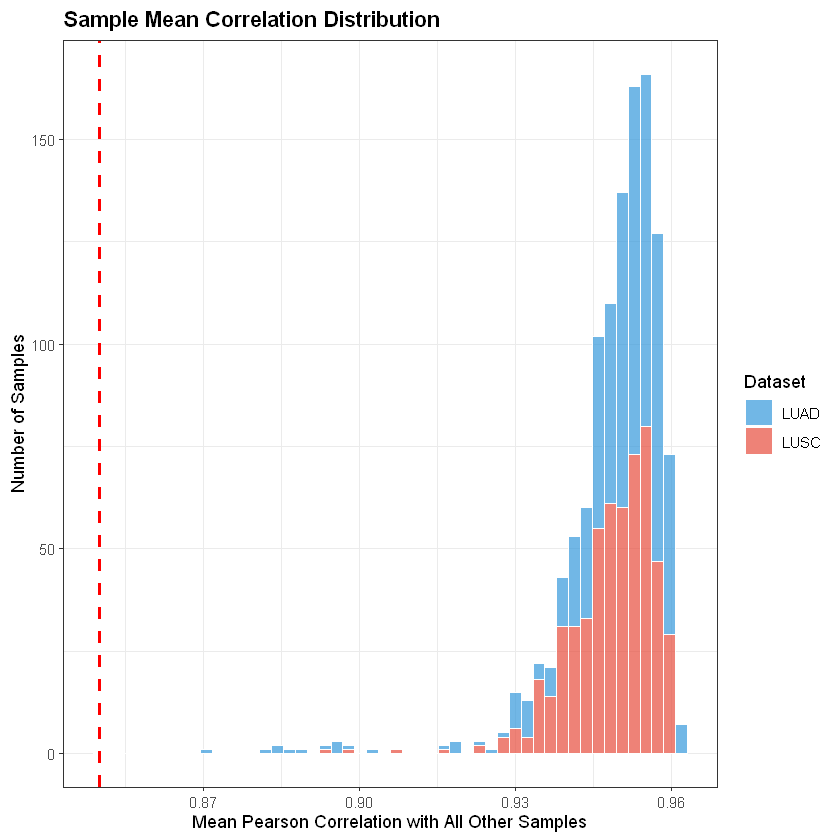

In [19]:
# --- PART B: Method 2 — Sample-to-Sample Correlation ---
# Calculate Pearson correlation between every pair of samples
# A good quality sample should correlate well (r > 0.85) with most others
# A poor quality sample will have low average correlation

cat("\n=== METHOD 2: Sample-to-Sample Correlation ===\n\n")
cat("Calculating correlation matrix (may take 1-2 minutes)...\n")

# Calculate correlation between all samples
# We transpose so samples are columns for cor()
cor_matrix <- cor(corrected_matrix, method = "pearson")

# For each sample, calculate its mean correlation with ALL other samples
mean_cor <- rowMeans(cor_matrix)

# Flag samples with mean correlation below threshold
# 0.85 is standard — adjust down to 0.80 if too many flagged
cor_threshold  <- 0.85
outliers_cor   <- names(mean_cor[mean_cor < cor_threshold])

cat(sprintf("Correlation threshold:  %.2f\n", cor_threshold))
cat(sprintf("Mean correlation range: [%.3f, %.3f]\n",
            min(mean_cor), max(mean_cor)))
cat(sprintf("Outliers detected:      %d\n", length(outliers_cor)))

if (length(outliers_cor) > 0) {
  cat("Outlier samples:\n")
  print(outliers_cor)
}

# Plot mean correlation distribution
cor_df <- data.frame(
  Sample  = names(mean_cor),
  MeanCor = mean_cor,
  Dataset = batch_labels
)

plot_cor <- ggplot(cor_df, aes(x = MeanCor, fill = Dataset)) +
  geom_histogram(bins = 50, alpha = 0.7, color = "white") +
  geom_vline(xintercept = cor_threshold,
             color = "red", linetype = "dashed", linewidth = 1) +
  scale_fill_manual(values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")) +
  labs(
    title    = "Sample Mean Correlation Distribution",
    x        = "Mean Pearson Correlation with All Other Samples",
    y        = "Number of Samples"
  ) +
  theme_bw() +
  theme(plot.title = element_text(face = "bold"))

ggsave("QC_correlation_distribution.png", plot_cor,
       width = 8, height = 5, dpi = 150)

cat("✔ Plot saved: QC_correlation_distribution.png\n")
print(plot_cor)

In [20]:
# --- PART C: Method 3 — Expression Distribution Check ---
# Check each sample's median expression level
# Samples with very low or very high median may have technical problems

cat("\n=== METHOD 3: Expression Distribution ===\n\n")

# Calculate median expression per sample
sample_medians <- apply(corrected_matrix, 2, median)

# Flag samples beyond 3 SD from mean median
mean_med  <- mean(sample_medians)
sd_med    <- sd(sample_medians)
upper_med <- mean_med + 3 * sd_med
lower_med <- mean_med - 3 * sd_med

outliers_expr <- names(sample_medians[
  sample_medians > upper_med | sample_medians < lower_med
])

cat(sprintf("Median expression range: [%.3f, %.3f]\n",
            min(sample_medians), max(sample_medians)))
cat(sprintf("Lower threshold:         %.3f\n", lower_med))
cat(sprintf("Upper threshold:         %.3f\n", upper_med))
cat(sprintf("Outliers detected:       %d\n", length(outliers_expr)))

if (length(outliers_expr) > 0) {
  cat("Outlier samples:\n")
  print(outliers_expr)
}


=== METHOD 3: Expression Distribution ===

Median expression range: [0.903, 4.990]
Lower threshold:         1.226
Upper threshold:         4.629
Outliers detected:       5
Outlier samples:
[1] "TCGA-33-4566-01A" "TCGA-21-5782-01A" "TCGA-33-4583-01A" "TCGA-18-3417-01A"
[5] "TCGA-NJ-A55R-01A"


In [21]:
# --- PART D: Combine all 3 methods ---
# Only remove samples flagged by 2 or more methods
# This prevents removing samples based on one method alone
# which could be too aggressive

cat("\n=== Combining Outlier Results ===\n\n")

# Count how many methods flagged each sample
all_samples  <- colnames(corrected_matrix)
flag_counts  <- rep(0, length(all_samples))
names(flag_counts) <- all_samples

# Add 1 for each method that flagged each sample
flag_counts[outliers_pca]  <- flag_counts[outliers_pca]  + 1
flag_counts[outliers_cor]  <- flag_counts[outliers_cor]  + 1
flag_counts[outliers_expr] <- flag_counts[outliers_expr] + 1

# Samples flagged by 2 or more methods = remove
samples_to_remove <- names(flag_counts[flag_counts >= 2])

cat(sprintf("Flagged by PCA only:         %d\n",
            sum(flag_counts == 1 & names(flag_counts) %in% outliers_pca)))
cat(sprintf("Flagged by correlation only: %d\n",
            sum(flag_counts == 1 & names(flag_counts) %in% outliers_cor)))
cat(sprintf("Flagged by expression only:  %d\n",
            sum(flag_counts == 1 & names(flag_counts) %in% outliers_expr)))
cat(sprintf("Flagged by 2+ methods:       %d  ← THESE WILL BE REMOVED\n",
            length(samples_to_remove)))

if (length(samples_to_remove) > 0) {
  cat("\nSamples to be removed:\n")
  print(samples_to_remove)
}


=== Combining Outlier Results ===

Flagged by PCA only:         16
Flagged by correlation only: 0
Flagged by expression only:  3
Flagged by 2+ methods:       2  ← THESE WILL BE REMOVED

Samples to be removed:
[1] "TCGA-33-4566-01A" "TCGA-18-3417-01A"


In [22]:
# --- PART E: Remove outliers and produce final clean matrix ---

cat("\n=== Removing Outliers ===\n\n")

if (length(samples_to_remove) == 0) {
  cat("✔ No outliers to remove — all samples pass QC\n")
  final_matrix <- corrected_matrix
  final_batch  <- batch_labels

} else {
  # Remove outlier columns from matrix
  keep_samples <- setdiff(colnames(corrected_matrix), samples_to_remove)
  final_matrix <- corrected_matrix[, keep_samples]

  # Update batch labels to match
  final_batch  <- batch_labels[colnames(corrected_matrix) %in% keep_samples]

  cat(sprintf("Samples before QC: %d\n", ncol(corrected_matrix)))
  cat(sprintf("Samples removed:   %d\n", length(samples_to_remove)))
  cat(sprintf("Samples after QC:  %d\n", ncol(final_matrix)))
}

cat(sprintf("\n=== FINAL CLEAN MATRIX ===\n"))
cat(sprintf("Genes:   %d\n", nrow(final_matrix)))
cat(sprintf("Samples: %d\n", ncol(final_matrix)))
cat(sprintf("Value range: [%.3f, %.3f]\n",
            min(final_matrix), max(final_matrix)))


=== Removing Outliers ===

Samples before QC: 1141
Samples removed:   2
Samples after QC:  1139

=== FINAL CLEAN MATRIX ===
Genes:   36650
Samples: 1139
Value range: [-4.758, 34.247]


In [23]:
# --- PART F: Save the final matrix to disk ---
# This is your analysis-ready file for all downstream work

cat("\n=== Saving Final Matrix ===\n")

# Convert to dataframe with gene names as first column
final_df <- data.frame(
  Gene = rownames(final_matrix),
  final_matrix,
  check.names = FALSE
)

# Save as compressed file
output_path <- "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv"

write.table(
  final_df,
  file      = output_path,
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("✔ Final matrix saved to:\n  %s\n", output_path))
cat(sprintf("  Size: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))


=== Saving Final Matrix ===
✔ Final matrix saved to:
  C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv
  Size: 36650 genes × 1139 samples


In [24]:
# ============================================================
# FINAL STEP: PCA Plot on Clean Preprocessed Matrix
# ============================================================

# --- PART A: Run PCA on final clean matrix ---

cat("=== Running Final PCA ===\n\n")

# Transpose: PCA needs samples as rows, genes as columns
pca_final <- prcomp(
  t(final_matrix),
  center = TRUE,
  scale. = FALSE   # Already log2 normalized — no need to rescale
)

# Calculate variance explained by each PC
var_explained <- summary(pca_final)$importance[2, ] * 100

cat(sprintf("PC1 variance explained: %.2f%%\n", var_explained[1]))
cat(sprintf("PC2 variance explained: %.2f%%\n", var_explained[2]))
cat(sprintf("PC3 variance explained: %.2f%%\n", var_explained[3]))
cat(sprintf("Total (PC1+PC2):        %.2f%%\n",
            var_explained[1] + var_explained[2]))

=== Running Final PCA ===

PC1 variance explained: 13.28%
PC2 variance explained: 9.28%
PC3 variance explained: 4.08%
Total (PC1+PC2):        22.55%


In [25]:
# --- PART B: Build PCA dataframe with sample metadata ---
# We extract useful information from TCGA barcodes
# TCGA barcode structure: TCGA-XX-XXXX-01A
#                                         ^^
#                                         01 = tumor
#                                         11 = normal

cat("\n=== Extracting Sample Metadata from Barcodes ===\n")

pca_final_df <- data.frame(
  PC1     = pca_final$x[, 1],
  PC2     = pca_final$x[, 2],
  PC3     = pca_final$x[, 3],
  Sample  = colnames(final_matrix),
  Dataset = final_batch
)

# Extract sample type from barcode (positions 14-15)
# "01" = Primary Tumor, "11" = Solid Normal Tissue
pca_final_df$SampleType <- ifelse(
  substr(pca_final_df$Sample, 14, 15) == "11",
  "Normal", "Tumor"
)

# Create a combined label for plotting
pca_final_df$Group <- paste(pca_final_df$Dataset,
                             pca_final_df$SampleType, sep = "_")

# Count groups
cat("\nSample breakdown:\n")
print(table(pca_final_df$Group))


=== Extracting Sample Metadata from Barcodes ===

Sample breakdown:

LUAD_Normal  LUAD_Tumor LUSC_Normal  LUSC_Tumor 
         59         530          51         499 


✔ Plot saved: Final_PCA_by_Dataset.png


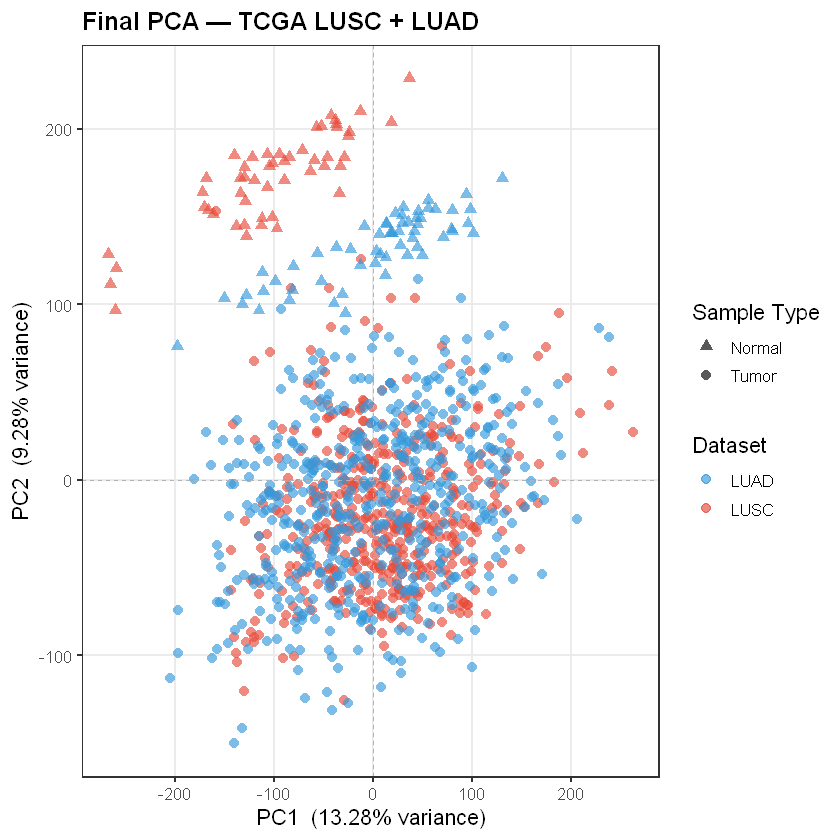

In [26]:
# --- PART C: Main PCA plot — colored by Dataset ---
# This shows whether batch effect has been successfully removed

plot_pca_dataset <- ggplot(
  pca_final_df,
  aes(x = PC1, y = PC2, color = Dataset, shape = SampleType)
) +
  geom_point(alpha = 0.65, size = 2.5) +
  scale_color_manual(
    values = c("LUSC" = "#E74C3C", "LUAD" = "#3498DB")
  ) +
  scale_shape_manual(
    values = c("Tumor" = 16, "Normal" = 17)  # circle vs triangle
  ) +
  labs(
    title    = "Final PCA — TCGA LUSC + LUAD",
    x        = sprintf("PC1  (%.2f%% variance)", var_explained[1]),
    y        = sprintf("PC2  (%.2f%% variance)", var_explained[2]),
    color    = "Dataset",
    shape    = "Sample Type"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title    = element_text(face = "bold", size = 15),
    plot.subtitle = element_text(color = "gray40"),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  ) +
  # Add a center crosshair at 0,0
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4) +
  geom_vline(xintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4)

ggsave("Final_PCA_by_Dataset.png", plot_pca_dataset,
       width = 9, height = 7, dpi = 200)

cat("✔ Plot saved: Final_PCA_by_Dataset.png\n")
print(plot_pca_dataset)

✔ Plot saved: Final_PCA_by_SampleType.png


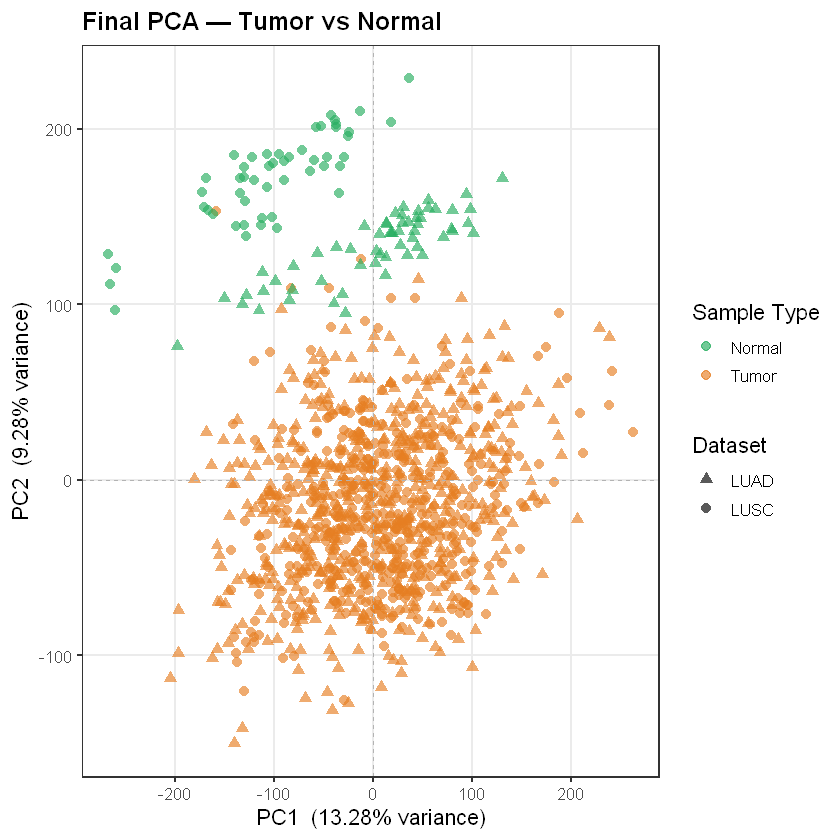

In [27]:
# --- PART D: Second PCA plot — colored by Tumor vs Normal ---
# This is biologically more meaningful
# Tumor and Normal should separate clearly on PC1 or PC2
# That separation = real biological signal, not batch effect

plot_pca_type <- ggplot(
  pca_final_df,
  aes(x = PC1, y = PC2, color = SampleType, shape = Dataset)
) +
  geom_point(alpha = 0.65, size = 2.5) +
  scale_color_manual(
    values = c("Tumor" = "#E67E22", "Normal" = "#27AE60")
  ) +
  scale_shape_manual(
    values = c("LUSC" = 16, "LUAD" = 17)
  ) +
  labs(
    title    = "Final PCA — Tumor vs Normal",
    x        = sprintf("PC1  (%.2f%% variance)", var_explained[1]),
    y        = sprintf("PC2  (%.2f%% variance)", var_explained[2]),
    color    = "Sample Type",
    shape    = "Dataset"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 15),
    plot.subtitle    = element_text(color = "gray40"),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  ) +
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4) +
  geom_vline(xintercept = 0, linetype = "dashed",
             color = "gray70", linewidth = 0.4)

ggsave("Final_PCA_by_SampleType.png", plot_pca_type,
       width = 9, height = 7, dpi = 200)

cat("✔ Plot saved: Final_PCA_by_SampleType.png\n")
print(plot_pca_type)

✔ Plot saved: Final_PCA_scree_plot.png


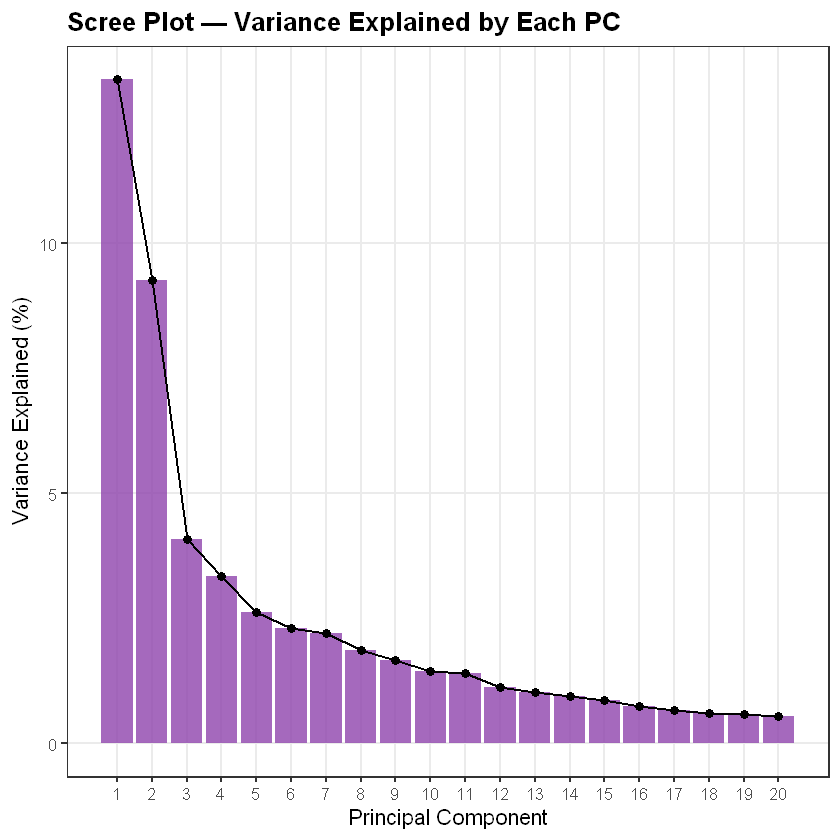

In [28]:
# --- PART E: Scree plot ---
# Shows how much variance each PC captures
# Helps decide how many PCs are meaningful

scree_df <- data.frame(
  PC       = 1:20,
  Variance = var_explained[1:20]
)

plot_scree <- ggplot(scree_df, aes(x = PC, y = Variance)) +
  geom_col(fill = "#8E44AD", alpha = 0.8) +
  geom_line(color = "black", linewidth = 0.7) +
  geom_point(color = "black", size = 2) +
  scale_x_continuous(breaks = 1:20) +
  labs(
    title = "Scree Plot — Variance Explained by Each PC",
    x     = "Principal Component",
    y     = "Variance Explained (%)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

ggsave("Final_PCA_scree_plot.png", plot_scree,
       width = 9, height = 5, dpi = 200)

cat("✔ Plot saved: Final_PCA_scree_plot.png\n")
print(plot_scree)

In [ ]:
# Install magick (only once)
install.packages("magick")

# Load the library in your session
library(magick)


In [30]:
"package:magick" %in% search()

[1] FALSE

In [31]:
sessionInfo()

R version 4.6.0 (2026-04-24 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: Asia/Katmandu
tzcode source: internal

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] patchwork_1.3.2             dplyr_1.2.1                
 [3] stringr_1.6.0               data.table_1.18.4          
 [5] ggplot2_4.0.3               org.Hs.eg.db_3.23.1        
 [7] AnnotationDbi_1.74.0        edgeR_4.10.1               
 [9] limma_3.68.4                sva_3.60.0                 
[11] BiocParallel_1.46.0         genefilter_1.94.0          
[13] mgcv_1.9-4                  nlme_3.1-169               

In [32]:
library(magick)

ERROR: Error in library(magick): there is no package called 'magick'


In [33]:
# Step 1: Install magick (only once)
install.packages("magick")

# Step 2: Load the library in your current R session
library(magick)

Installing package into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'magick' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpyMs7r4\downloaded_packages


Linking to ImageMagick 6.9.13.29
Enabled features: cairo, freetype, fftw, ghostscript, heic, lcms, pango, raw, rsvg, webp
Disabled features: fontconfig, x11



In [34]:
library(magick)

In [37]:
# Load the library
library(magick)

# Now run the stitching code
img_before <- image_read("PCA_before_batch_correction.png")
img_after  <- image_read("PCA_after_batch_correction.png")
img_scree  <- image_read("Final_PCA_scree_plot.png")
img_type   <- image_read("Final_PCA_by_SampleType.png")

combined   <- image_append(c(img_before, img_after), stack = FALSE)
combined2  <- image_append(c(img_scree, img_type), stack = FALSE)
final_panel <- image_append(c(combined, combined2), stack = TRUE)

image_write(final_panel, "QC_PCA_panel.png", format = "png")

In [38]:
# --- PART F: Final pipeline summary ---

cat("\n")
cat("============================================================\n")
cat("        PREPROCESSING PIPELINE COMPLETE\n")
cat("============================================================\n\n")

cat(sprintf("  Input datasets:         TCGA-LUSC + TCGA-LUAD\n"))
cat(sprintf("  Data type:              log2-normalized TPM\n"))
cat(sprintf("  Gene ID mapping:        Ensembl → HGNC symbols\n"))
cat(sprintf("  Batch correction:       ComBat\n"))
cat(sprintf("  Outlier removal:        3-method consensus\n\n"))

cat(sprintf("  Final genes:            %d\n", nrow(final_matrix)))
cat(sprintf("  Final samples:          %d\n", ncol(final_matrix)))
cat(sprintf("  LUSC samples:           %d\n",
            sum(final_batch == "LUSC")))
cat(sprintf("  LUAD samples:           %d\n",
            sum(final_batch == "LUAD")))
cat(sprintf("  Normal samples:         %d\n",
            sum(pca_final_df$SampleType == "Normal")))
cat(sprintf("  Tumor samples:          %d\n",
            sum(pca_final_df$SampleType == "Tumor")))
cat(sprintf("\n  Output saved to:\n"))
cat(sprintf("  C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv\n"))
cat("\n============================================================\n")


        PREPROCESSING PIPELINE COMPLETE

  Input datasets:         TCGA-LUSC + TCGA-LUAD
  Data type:              log2-normalized TPM
  Gene ID mapping:        Ensembl → HGNC symbols
  Batch correction:       ComBat
  Outlier removal:        3-method consensus

  Final genes:            36650
  Final samples:          1139
  LUSC samples:           550
  LUAD samples:           589
  Normal samples:         110
  Tumor samples:          1029

  Output saved to:
  C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv



In [39]:
# ============================================================
# DEG ANALYSIS - STEP 1: Load Required Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "limma",        # Core DEG analysis
  "edgeR"         # Used alongside limma for voom
), update = FALSE)

install.packages(c(
  "ggplot2",      # Volcano plot
  "ggrepel",      # Gene labels on volcano plot
  "pheatmap",     # Heatmap
  "dplyr",        # Data manipulation
  "RColorBrewer"  # Color palettes for heatmap
))

# Load all
library(limma)
library(edgeR)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)

cat("All packages loaded successfully\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'limma' 'edgeR'"
Warning message:
"packages 'ggplot2', 'dplyr' are in use and will not be installed"
Installing packages into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'ggrepel' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'ggrepel'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\aryan\AppData\Local\R\win-library\4.6\00LOCK\ggrepel\libs\x64\ggrepel.dll to C:\Users\aryan\AppData\Local\R\win-library\4.6\ggrepel\libs\x64\ggrepel.dll: Permission denied"
Warning message:
"restored 'ggrepel'"


package 'pheatmap' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpyMs7r4\downloaded_packages
All packages loaded successfully


In [40]:
# ============================================================
# DEG ANALYSIS - STEP 2: Create Sample Metadata
# ============================================================

# Extract sample type from TCGA barcode
# Position 14-15: "01" = Tumor, "11" = Normal
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor"
)

# Create metadata dataframe
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types, levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix)
)

# Quick check
cat("=== Sample Metadata Summary ===\n\n")
cat(sprintf("Total samples:   %d\n", nrow(metadata)))
cat(sprintf("Tumor samples:   %d\n", sum(metadata$SampleType == "Tumor")))
cat(sprintf("Normal samples:  %d\n", sum(metadata$SampleType == "Normal")))

cat("\nBreakdown by dataset:\n")
print(table(metadata$Dataset, metadata$SampleType))

=== Sample Metadata Summary ===

Total samples:   1139
Tumor samples:   1029
Normal samples:  110

Breakdown by dataset:
      
       Normal Tumor
  LUAD     59   530
  LUSC     51   499


In [41]:
# ============================================================
# DEG ANALYSIS - STEP 3: limma-voom
# ============================================================

# --- PART A: Create design matrix ---
# This tells limma which samples are tumor and which are normal
# ~ 0 + SampleType means we explicitly model both groups

cat("=== PART A: Creating Design Matrix ===\n")

design <- model.matrix(~ 0 + SampleType, data = metadata)

# Rename columns cleanly
colnames(design) <- c("Normal", "Tumor")

cat("Design matrix dimensions:\n")
cat(sprintf("  Rows (samples): %d\n", nrow(design)))
cat(sprintf("  Cols (groups):  %d\n", ncol(design)))
cat("\nFirst 3 rows of design matrix:\n")
print(head(design, 3))

=== PART A: Creating Design Matrix ===
Design matrix dimensions:
  Rows (samples): 1139
  Cols (groups):  2

First 3 rows of design matrix:
                 Normal Tumor
TCGA-60-2698-01A      0     1
TCGA-33-4589-01A      0     1
TCGA-18-3410-01A      0     1


In [42]:
# ============================================================
# FIX: Remove negative values before voom
# ============================================================

# Check minimum value
cat(sprintf("Minimum value before fix: %.3f\n", min(final_matrix)))

# Shift entire matrix so minimum value becomes 0
# We add the absolute value of the minimum to every value
final_matrix_shifted <- final_matrix - min(final_matrix)

# Verify fix
cat(sprintf("Minimum value after fix:  %.3f\n", min(final_matrix_shifted)))
cat(sprintf("Maximum value after fix:  %.3f\n", max(final_matrix_shifted)))

Minimum value before fix: -4.758
Minimum value after fix:  0.000
Maximum value after fix:  39.004



=== PART B (Fixed): Applying voom ===
✔ voom transformation complete
  Matrix: 36650 genes × 1139 samples


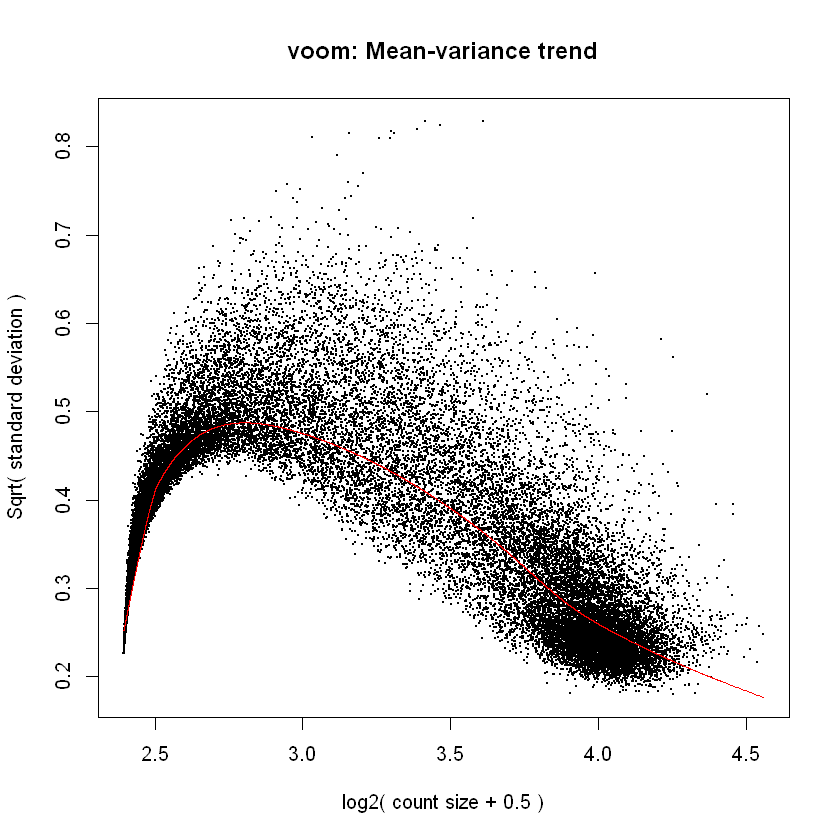

In [43]:
# --- Now rerun PART B with shifted matrix ---

cat("\n=== PART B (Fixed): Applying voom ===\n")

voom_result <- voom(
  counts = final_matrix_shifted,   # shifted matrix
  design = design,
  plot   = TRUE
)

cat("✔ voom transformation complete\n")
cat(sprintf("  Matrix: %d genes × %d samples\n",
            nrow(voom_result$E), ncol(voom_result$E)))

In [44]:
# Continue with Part C
fit <- lmFit(voom_result, design)
cat("✔ Linear model fitted\n")

# Part D
contrast_matrix <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design
)

# Part E
fit2 <- contrasts.fit(fit, contrast_matrix)
fit2 <- eBayes(fit2)
cat("✔ eBayes complete\n")

# Part F
deg_results <- topTable(
  fit2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

cat(sprintf("✔ Results extracted for %d genes\n", nrow(deg_results)))
cat("\n--- Preview: Top 10 DEGs ---\n")
print(head(deg_results, 10))

✔ Linear model fitted
✔ eBayes complete
✔ Results extracted for 36650 genes

--- Preview: Top 10 DEGs ---
                  logFC  AveExpr         t       P.Value     adj.P.Val        B
AGER         -0.5658662 5.468332 -56.51434  0.000000e+00  0.000000e+00 753.4687
SLC6A4       -0.8001615 4.939905 -57.30944  0.000000e+00  0.000000e+00 765.2969
RTKN2        -0.3832787 5.409297 -53.28775 4.454346e-312 4.931160e-308 704.8588
CD300LG      -0.8831877 4.595685 -53.27538 5.381894e-312 4.931160e-308 704.3373
FAM107A      -0.5093337 5.283068 -53.24955 7.990183e-312 5.856804e-308 704.2955
C10orf67-AS1 -0.8758236 4.310781 -53.10859 6.916320e-311 4.224719e-307 700.8371
GPD1         -0.5453819 5.098687 -52.58538 2.128105e-307 1.114215e-303 694.1027
CLEC3B       -0.5088052 5.111356 -52.18630 9.960332e-305 4.563077e-301 687.9580
GPM6A        -0.7193275 4.926289 -52.05236 7.878220e-304 3.208186e-300 685.8582
TEK          -0.3601428 5.327703 -50.40098 1.112130e-292 4.075956e-289 660.2488


In [45]:
# ============================================================
# STEP 4 FIXED: Apply Corrected Thresholds
# ============================================================

# --- PART A: Reclassify with |logFC| > 0.5 ---

cat("=== Applying Corrected DEG Thresholds ===\n")
cat("Threshold: |log2FC| > 0.5 AND adj.p < 0.05\n\n")

deg_results$Status <- "Not Significant"

deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Upregulated"

deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Downregulated"

deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant")
)

=== Applying Corrected DEG Thresholds ===
Threshold: |log2FC| > 0.5 AND adj.p < 0.05



In [46]:
# --- PART B: Count DEGs ---

total_genes   <- nrow(deg_results)
upregulated   <- sum(deg_results$Status == "Upregulated")
downregulated <- sum(deg_results$Status == "Downregulated")
not_sig       <- sum(deg_results$Status == "Not Significant")
total_degs    <- upregulated + downregulated

cat("=== DEG Summary ===\n\n")
cat(sprintf("Total genes tested:    %d\n", total_genes))
cat(sprintf("Total DEGs:            %d\n", total_degs))
cat(sprintf("  Upregulated:         %d\n", upregulated))
cat(sprintf("  Downregulated:       %d\n", downregulated))
cat(sprintf("Not significant:       %d\n", not_sig))
cat(sprintf("DEG rate:              %.1f%%\n",
            total_degs / total_genes * 100))

=== DEG Summary ===

Total genes tested:    36650
Total DEGs:            377
  Upregulated:         167
  Downregulated:       210
Not significant:       36273
DEG rate:              1.0%


In [49]:
# --- PART C: Extract significant DEGs ---

sig_degs <- deg_results[deg_results$Status != "Not Significant", ]
sig_degs <- sig_degs[order(-sig_degs$logFC), ]

cat("\n--- Top 20 Upregulated Genes ---\n")
print(head(sig_degs[sig_degs$Status == "Upregulated",
                    c("logFC", "adj.P.Val", "Status")], 20))

cat("\n--- Top 20 Downregulated Genes ---\n")
print(head(sig_degs[sig_degs$Status == "Downregulated",
                    c("logFC", "adj.P.Val", "Status")], 20))


--- Top 20 Upregulated Genes ---
                 logFC     adj.P.Val      Status
CASC9        0.8844172  7.545661e-40 Upregulated
PITX2        0.8670381  8.870830e-57 Upregulated
HOXC13       0.8514333 7.459573e-139 Upregulated
PRAME        0.8499343  7.361933e-22 Upregulated
CST1         0.8321232  1.181146e-32 Upregulated
LCAL1        0.7984911  4.735091e-27 Upregulated
SACK1A-AS1   0.7862638  2.296326e-61 Upregulated
BARX1        0.7844422  4.377812e-34 Upregulated
BBOX1-AS1    0.7828061  6.876416e-57 Upregulated
GABRA3       0.7673588  2.033247e-51 Upregulated
C12orf56     0.7595353  2.888291e-51 Upregulated
LOC124904701 0.7501783  1.404994e-78 Upregulated
GNGT1        0.7452534 1.061435e-146 Upregulated
KRTAP4-1     0.7371475 3.523198e-164 Upregulated
IL36RN       0.7315872  2.036536e-36 Upregulated
DLX6         0.7276276  8.668633e-57 Upregulated
FOXD3-AS1    0.7274440 1.218633e-160 Upregulated
ZIC2         0.7266607  9.199766e-40 Upregulated
AKR1B10      0.7211713  4.939853e-1

In [50]:
# --- PART D: Save results ---

write.table(
  data.frame(Gene = rownames(deg_results), deg_results),
  file      = "C:/Users/aryan/Downloads/DEG_full_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  data.frame(Gene = rownames(sig_degs), sig_degs),
  file      = "C:/Users/aryan/Downloads/DEG_significant_only.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Full results saved:      DEG_full_results.tsv\n")
cat("✔ Significant DEGs saved:  DEG_significant_only.tsv\n")


✔ Full results saved:      DEG_full_results.tsv
✔ Significant DEGs saved:  DEG_significant_only.tsv


In [51]:
# ============================================================
# DEG ANALYSIS - STEP 5: Volcano Plot
# ============================================================

# --- PART A: Prepare data for plotting ---

cat("=== Building Volcano Plot ===\n")

# Add -log10 adjusted p-value column for y axis
deg_results$neg_log10_p <- -log10(deg_results$adj.P.Val)

# Add gene names column
deg_results$Gene <- rownames(deg_results)

# Select top 10 up and top 10 down genes to label on plot
top_up <- deg_results[deg_results$Status == "Upregulated", ]
top_up <- head(top_up[order(-top_up$logFC), ], 10)

top_down <- deg_results[deg_results$Status == "Downregulated", ]
top_down <- head(top_down[order(top_down$logFC), ], 10)

genes_to_label <- rbind(top_up, top_down)

cat(sprintf("Genes to label on plot: %d\n", nrow(genes_to_label)))

=== Building Volcano Plot ===
Genes to label on plot: 20


✔ Volcano plot saved in working directory: Volcano_plot_DEGs.png


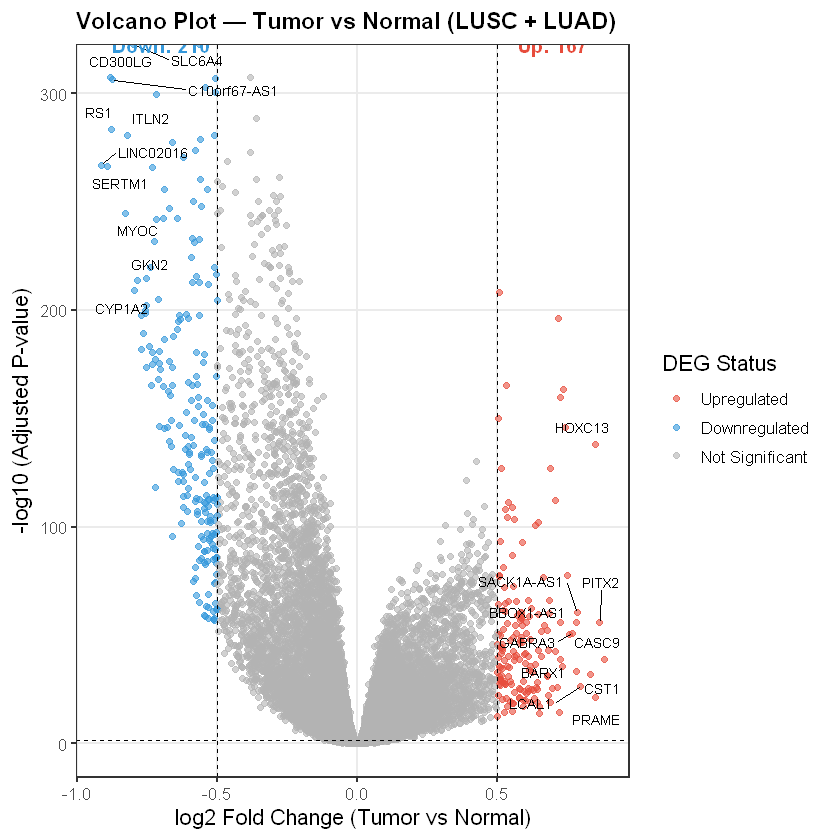

In [53]:
volcano_plot <- ggplot(
  deg_results,
  aes(x = logFC, y = neg_log10_p, color = Status)
) +
  geom_point(alpha = 0.6, size = 1.5) +
  scale_color_manual(values = c(
    "Upregulated"    = "#E74C3C",   # Red
    "Downregulated"  = "#3498DB",   # Blue
    "Not Significant"= "grey70"     # Grey
  )) +
  geom_vline(xintercept =  0.5, linetype = "dashed",
             color = "black", linewidth = 0.5) +
  geom_vline(xintercept = -0.5, linetype = "dashed",
             color = "black", linewidth = 0.5) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed",
             color = "black", linewidth = 0.5) +
  geom_text_repel(
    data        = genes_to_label,
    aes(label   = Gene),
    size        = 3,
    color       = "black",
    max.overlaps = 20,
    box.padding  = 0.4
  ) +
  labs(
    title    = "Volcano Plot — Tumor vs Normal (LUSC + LUAD)",
    x        = "log2 Fold Change (Tumor vs Normal)",
    y        = "-log10 (Adjusted P-value)",
    color    = "DEG Status"
  ) +
  annotate("text", x =  0.7, y = max(deg_results$neg_log10_p) * 0.95,
           label = paste0("Up: ", sum(deg_results$Status == "Upregulated")),
           color = "#E74C3C", fontface = "bold", size = 4) +
  annotate("text", x = -0.7, y = max(deg_results$neg_log10_p) * 0.95,
           label = paste0("Down: ", sum(deg_results$Status == "Downregulated")),
           color = "#3498DB", fontface = "bold", size = 4) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

# Save in working directory (wide rectangular panel style)
ggsave(
  "Volcano_plot_DEGs.png",   # <-- only filename, no path
  volcano_plot,
  width  = 12,
  height = 6,
  dpi    = 200
)

cat("✔ Volcano plot saved in working directory: Volcano_plot_DEGs.png\n")
print(volcano_plot)

In [54]:
# ============================================================
# DEG ANALYSIS - STEP 6: Heatmap
# ============================================================

# --- PART A: Select top genes for heatmap ---
# Using top 50 DEGs (25 up + 25 down) for clean visualization

cat("=== Building Heatmap ===\n\n")

# Top 25 upregulated
top25_up <- head(
  rownames(deg_results[deg_results$Status == "Upregulated", ][
    order(-deg_results[deg_results$Status == "Upregulated", "logFC"]), ]), 25)

# Top 25 downregulated
top25_down <- head(
  rownames(deg_results[deg_results$Status == "Downregulated", ][
    order(deg_results[deg_results$Status == "Downregulated", "logFC"]), ]), 25)

# Combine
top50_genes <- c(top25_up, top25_down)

cat(sprintf("Top upregulated genes selected:   %d\n", length(top25_up)))
cat(sprintf("Top downregulated genes selected:  %d\n", length(top25_down)))
cat(sprintf("Total genes for heatmap:           %d\n", length(top50_genes)))

=== Building Heatmap ===

Top upregulated genes selected:   25
Top downregulated genes selected:  25
Total genes for heatmap:           50


In [55]:
# --- PART B: Extract expression values for top genes ---
# Use final_matrix (preprocessed expression values)
# Subset to top 50 genes only

heatmap_mat <- final_matrix[top50_genes, ]

cat(sprintf("\nHeatmap matrix: %d genes × %d samples\n",
            nrow(heatmap_mat), ncol(heatmap_mat)))


Heatmap matrix: 50 genes × 1139 samples


In [56]:
# --- PART C: Scale genes (z-score per gene) ---
# Z-score scaling makes patterns visible across genes
# with different expression levels
# Each gene: subtract mean, divide by SD
# Result: values centered around 0

heatmap_scaled <- t(scale(t(heatmap_mat)))

# Cap extreme values for better color visualization
heatmap_scaled[heatmap_scaled >  3] <-  3
heatmap_scaled[heatmap_scaled < -3] <- -3

cat("Z-score scaling applied\n")
cat(sprintf("Value range after scaling: [%.2f, %.2f]\n",
            min(heatmap_scaled), max(heatmap_scaled)))

Z-score scaling applied
Value range after scaling: [-2.93, 3.00]


In [57]:
# --- PART D: Create annotation for samples ---
# This adds colored bars on top of heatmap
# showing which samples are Tumor/Normal and LUSC/LUAD

annotation_col <- data.frame(
  SampleType = metadata$SampleType,
  Dataset    = metadata$Dataset,
  row.names  = metadata$Sample
)

# Define colors for annotations
annotation_colors <- list(
  SampleType = c(
    "Tumor"  = "#E74C3C",
    "Normal" = "#27AE60"
  ),
  Dataset = c(
    "LUSC" = "#8E44AD",
    "LUAD" = "#F39C12"
  )
)

cat("Sample annotations created\n")

Sample annotations created


In [58]:
# --- PART E: Draw and save heatmap ---

cat("\nGenerating heatmap (may take a moment)...\n")

# Color palette: blue = low, white = middle, red = high
heatmap_colors <- colorRampPalette(
  c("#3498DB", "white", "#E74C3C")
)(100)

# Draw heatmap
pheatmap(
  mat               = heatmap_scaled,
  color             = heatmap_colors,
  annotation_col    = annotation_col,
  annotation_colors = annotation_colors,
  show_colnames     = FALSE,      # too many samples to show names
  show_rownames     = TRUE,       # show gene names
  cluster_rows      = TRUE,       # cluster genes
  cluster_cols      = TRUE,       # cluster samples
  clustering_method = "ward.D2",  # standard clustering method
  fontsize_row      = 8,          # gene name font size
  main              = "Heatmap — Top 50 DEGs (Tumor vs Normal)",
  filename          = "Heatmap_top50_DEGs.png",  # <-- only filename
  width             = 14,
  height            = 10
)

cat("✔ Heatmap saved in working directory: Heatmap_top50_DEGs.png\n")


Generating heatmap (may take a moment)...
✔ Heatmap saved in working directory: Heatmap_top50_DEGs.png


In [59]:
# ============================================================
# DEG ANALYSIS - STEP 7: Venn Diagram
# ============================================================

# --- PART A: Split samples by dataset ---
# We need to run DEG analysis separately for LUSC and LUAD
# Then compare which DEGs overlap

cat("=== PART A: Splitting by Dataset ===\n\n")

# Get sample names for each dataset
lusc_samples <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples <- rownames(metadata[metadata$Dataset == "LUAD", ])

cat(sprintf("LUSC samples: %d\n", length(lusc_samples)))
cat(sprintf("LUAD samples: %d\n", length(luad_samples)))

# Subset final matrix for each dataset
lusc_mat_deg <- final_matrix_shifted[, lusc_samples]
luad_mat_deg <- final_matrix_shifted[, luad_samples]

# Subset metadata for each dataset
lusc_meta <- metadata[lusc_samples, ]
luad_meta <- metadata[luad_samples, ]

cat(sprintf("\nLUSC matrix: %d genes × %d samples\n",
            nrow(lusc_mat_deg), ncol(lusc_mat_deg)))
cat(sprintf("LUAD matrix: %d genes × %d samples\n",
            nrow(luad_mat_deg), ncol(luad_mat_deg)))

# Check tumor/normal counts per dataset
cat("\nLUSC tumor/normal:\n")
print(table(lusc_meta$SampleType))
cat("\nLUAD tumor/normal:\n")
print(table(luad_meta$SampleType))

=== PART A: Splitting by Dataset ===

LUSC samples: 550
LUAD samples: 589

LUSC matrix: 36650 genes × 550 samples
LUAD matrix: 36650 genes × 589 samples

LUSC tumor/normal:

Normal  Tumor 
    51    499 

LUAD tumor/normal:

Normal  Tumor 
    59    530 


In [60]:
# --- PART B: Run limma-voom separately for LUSC ---

cat("\n=== PART B: DEG Analysis for LUSC ===\n")

# Design matrix for LUSC
design_lusc <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")

# voom
voom_lusc <- voom(lusc_mat_deg, design_lusc, plot = FALSE)

# Fit model
fit_lusc <- lmFit(voom_lusc, design_lusc)

# Contrast
contrast_lusc <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_lusc
)

# eBayes
fit_lusc2 <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2 <- eBayes(fit_lusc2)

# Extract results
deg_lusc <- topTable(
  fit_lusc2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

# Apply thresholds
sig_lusc <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUSC DEGs: %d\n", length(sig_lusc)))


=== PART B: DEG Analysis for LUSC ===
✔ LUSC DEGs: 852


In [61]:
# --- PART C: Run limma-voom separately for LUAD ---

cat("\n=== PART C: DEG Analysis for LUAD ===\n")

# Design matrix for LUAD
design_luad <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")

# voom
voom_luad <- voom(luad_mat_deg, design_luad, plot = FALSE)

# Fit model
fit_luad <- lmFit(voom_luad, design_luad)

# Contrast
contrast_luad <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_luad
)

# eBayes
fit_luad2 <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2 <- eBayes(fit_luad2)

# Extract results
deg_luad <- topTable(
  fit_luad2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

# Apply thresholds
sig_luad <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUAD DEGs: %d\n", length(sig_luad)))


=== PART C: DEG Analysis for LUAD ===
✔ LUAD DEGs: 232


In [62]:
# --- PART D: Find overlapping DEGs ---

cat("\n=== PART D: Overlap Analysis ===\n\n")

# Genes in both datasets
common_degs <- intersect(sig_lusc, sig_luad)

# Genes unique to each
only_lusc <- setdiff(sig_lusc, sig_luad)
only_luad <- setdiff(sig_luad, sig_lusc)

cat(sprintf("LUSC only DEGs:     %d\n", length(only_lusc)))
cat(sprintf("LUAD only DEGs:     %d\n", length(only_luad)))
cat(sprintf("Shared DEGs:        %d\n", length(common_degs)))

cat("\n--- Shared DEGs (most robust findings) ---\n")
print(common_degs)


=== PART D: Overlap Analysis ===

LUSC only DEGs:     684
LUAD only DEGs:     64
Shared DEGs:        168

--- Shared DEGs (most robust findings) ---
  [1] "ARHGEF4-AS1"  "GPD1"         "AGER"         "ADAMTS7P3"    "RS1"         
  [6] "CD300LG"      "FOXD3-AS1"    "LOC105373373" "VEGFD"        "CPB2"        
 [11] "MCEMP1"       "FAM107A"      "GPIHBP1"      "ADAMTS8"      "LINC02016"   
 [16] "TNNC1"        "CLDN18"       "GPM6A"        "C10orf67-AS1" "CA4"         
 [21] "GPA33"        "SLC6A4"       "GKN2"         "CNTN6"        "AGRP"        
 [26] "PLA2G1B"      "GRIA1"        "RETN"         "RXFP2"        "F11"         
 [31] "GDF10"        "MS4A15"       "NKX1-2"       "LINC01863"    "C8B"         
 [36] "CTXND1"       "ANKRD1"       "LINC00968"    "TMEM100"      "MYOC"        
 [41] "IHH"          "ANGPT4"       "LNCEGFL7OS"   "CD5L"         "CAV3"        
 [46] "ADRA1A"       "ITLN2"        "RSPO1"        "CYP1A2"       "HID1-AS1"    
 [51] "CHRM2"        "LOC124905092" "FRE


=== PART E: Drawing Venn Diagram ===


Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's colour values."


✔ Venn diagram saved: Venn_diagram_DEGs.png


Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's colour values."


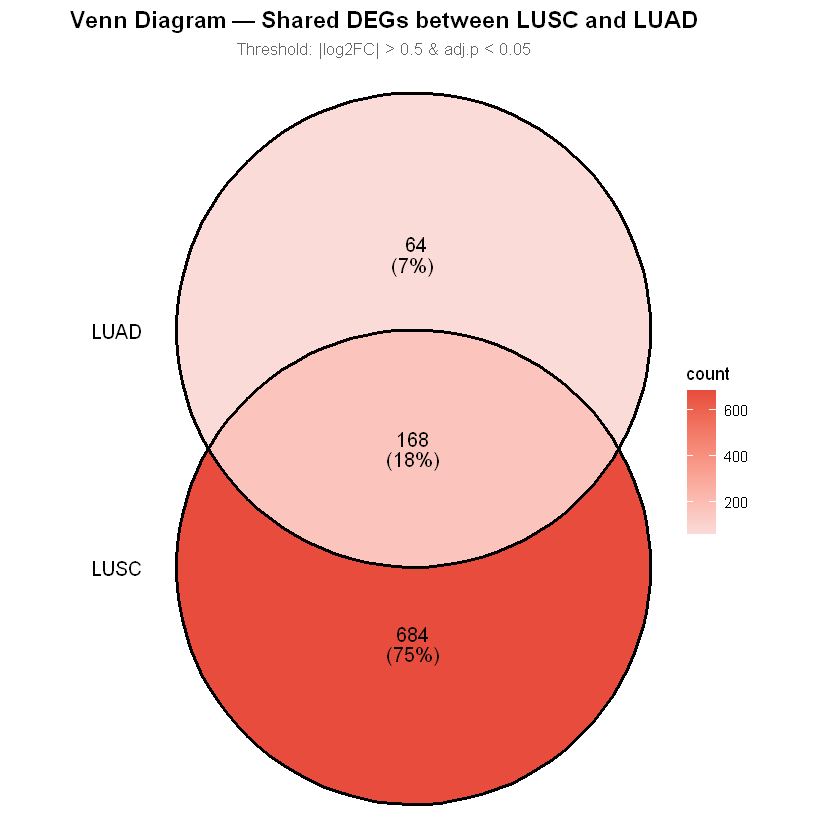

In [63]:
# --- PART E: Draw Venn Diagram ---

# Install if needed
if (!requireNamespace("ggVennDiagram", quietly = TRUE))
  install.packages("ggVennDiagram")

library(ggVennDiagram)

cat("\n=== PART E: Drawing Venn Diagram ===\n")

# Create list of DEG sets
venn_list <- list(
  LUSC = sig_lusc,
  LUAD = sig_luad
)

# Draw Venn diagram
venn_plot <- ggVennDiagram(
  venn_list,
  label_alpha = 0,
  edge_size   = 1
) +
  scale_fill_gradient(
    low  = "#FADBD8",
    high = "#E74C3C"
  ) +
  scale_color_manual(values = c(
    "LUSC" = "#8E44AD",
    "LUAD" = "#F39C12"
  )) +
  labs(
    title    = "Venn Diagram — Shared DEGs between LUSC and LUAD",
    subtitle = "Threshold: |log2FC| > 0.5 & adj.p < 0.05"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 14,
                                 hjust = 0.5),
    plot.subtitle = element_text(color = "gray40", size = 10,
                                 hjust = 0.5)
  )

# Save
ggsave(
  "Venn_diagram_DEGs.png",
  venn_plot,
  width  = 8,
  height = 6,
  dpi    = 200
)

cat("✔ Venn diagram saved: Venn_diagram_DEGs.png\n")
print(venn_plot)

In [64]:
# --- PART F: Save shared DEGs to file ---

cat("\n=== PART F: Saving Shared DEGs ===\n")

# Get full results for shared DEGs from combined analysis
shared_deg_results <- deg_results[common_degs, ]
shared_deg_results$Gene <- common_degs

write.table(
  shared_deg_results,
  file      = "C:/Users/aryan/Downloads/Shared_DEGs_LUSC_LUAD.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("✔ Shared DEGs saved: Shared_DEGs_LUSC_LUAD.tsv\n"))
cat(sprintf("  Total shared DEGs: %d\n", nrow(shared_deg_results)))

cat("\n============================================================\n")
cat("         DEG ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. DEG_full_results.tsv\n")
cat("  2. DEG_significant_only.tsv\n")
cat("  3. Volcano_plot_DEGs.png\n")
cat("  4. Heatmap_top50_DEGs.png\n")
cat("  5. Venn_diagram_DEGs.png\n")
cat("  6. Shared_DEGs_LUSC_LUAD.tsv\n")
cat("============================================================\n")


=== PART F: Saving Shared DEGs ===
✔ Shared DEGs saved: Shared_DEGs_LUSC_LUAD.tsv
  Total shared DEGs: 168

         DEG ANALYSIS COMPLETE
Files saved:
  1. DEG_full_results.tsv
  2. DEG_significant_only.tsv
  3. Volcano_plot_DEGs.png
  4. Heatmap_top50_DEGs.png
  5. Venn_diagram_DEGs.png
  6. Shared_DEGs_LUSC_LUAD.tsv


In [65]:
library(gridExtra)
library(png)
library(grid)

# Load images
img_before <- rasterGrob(readPNG("PCA_before_batch_correction.png"))
img_after  <- rasterGrob(readPNG("PCA_after_batch_correction.png"))
img_scree  <- rasterGrob(readPNG("Final_PCA_scree_plot.png"))
img_type   <- rasterGrob(readPNG("Final_PCA_by_SampleType.png"))

# Combine into one page
pdf("QC_PCA_panel.pdf", width = 14, height = 10)
grid.arrange(img_before, img_after, img_scree, img_type, ncol = 2)
dev.off()


Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:Biobase':

    combine


The following object is masked from 'package:BiocGenerics':

    combine




agg_record_5cc37681c91 
                     2

In [68]:
# --- Combine Volcano, Heatmap, and Venn Diagram into one image ---

# Install if needed
if (!requireNamespace("magick", quietly = TRUE))
  install.packages("magick")

library(magick)

# Read each saved plot image
volcano <- image_read("Volcano_plot_DEGs.png")
heatmap <- image_read("Heatmap_top50_DEGs.png")
venn    <- image_read("Venn_diagram_DEGs.png")

# Combine horizontally (side by side)
combined <- image_append(c(volcano, heatmap, venn))

# Save final composite figure
image_write(combined, "Combined_DEG_Figure.png", format = "png")

cat("✔ Combined figure saved: Combined_DEG_Figure.png\n")


✔ Combined figure saved: Combined_DEG_Figure.png



Attaching package: 'cowplot'


The following object is masked from 'package:patchwork':

    align_plots


Warning message:
"No shared levels found between `names(values)` of the manual scale and the data's colour values."


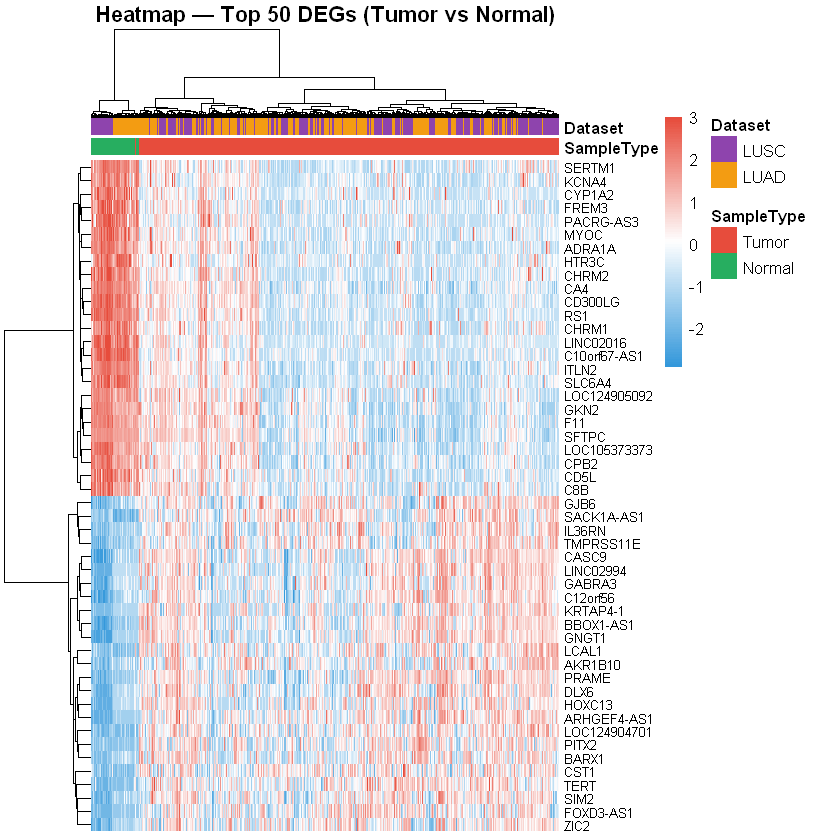

✔ Combined figure saved: Combined_DEG_Figure.pdf


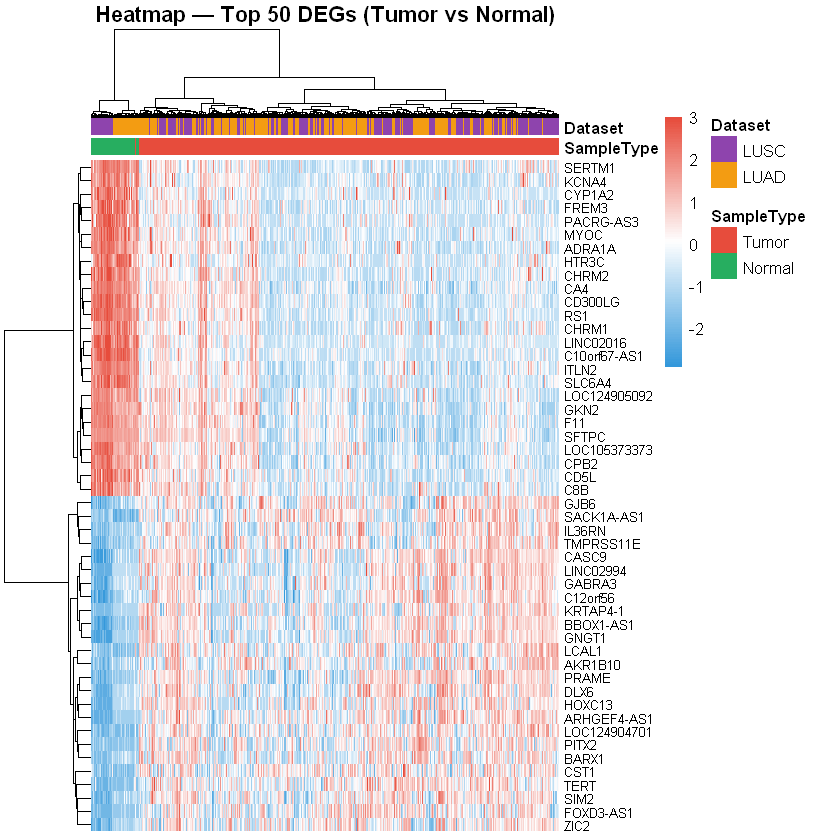

In [69]:
# --- Combine Volcano, Heatmap, and Venn Diagram into one PDF ---

# Install if needed
if (!requireNamespace("cowplot", quietly = TRUE))
  install.packages("cowplot")

library(cowplot)
library(gridExtra)

# If you already have the ggplot objects in memory:
# volcano_plot (ggplot), venn_plot (ggplot)
# For pheatmap, capture as a grid object:
heatmap_obj <- pheatmap(
  mat               = heatmap_scaled,
  color             = heatmap_colors,
  annotation_col    = annotation_col,
  annotation_colors = annotation_colors,
  show_colnames     = FALSE,
  show_rownames     = TRUE,
  cluster_rows      = TRUE,
  cluster_cols      = TRUE,
  clustering_method = "ward.D2",
  fontsize_row      = 8,
  main              = "Heatmap — Top 50 DEGs (Tumor vs Normal)"
)

# Arrange plots side by side
combined_plot <- plot_grid(
  volcano_plot,
  gridExtra::grid.arrange(heatmap_obj$gtable),
  venn_plot,
  ncol = 3,
  labels = c("A", "B", "C")
)

# Save as PDF
ggsave("Combined_DEG_Figure.pdf", combined_plot,
       width = 18, height = 6, dpi = 300)

cat("✔ Combined figure saved: Combined_DEG_Figure.pdf\n")


In [10]:
ego <- enrichGO(
    gene          = deg_list,
    OrgDb         = org.Hs.eg.db,
    keyType       = "ENTREZID",
    ont           = "BP",
    pAdjustMethod = "BH",
    qvalueCutoff  = 0.05
)
barplot(ego, showCategory = 20)


ERROR: Error: object 'deg_list' not found


In [11]:
# ============================================================
# FULL REBUILD FROM SAVED FILE
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(sva)

# --- Step 1: Reload final matrix from saved file ---
cat("Loading saved final matrix...\n")

final_df <- fread(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE,
  sep    = "\t"
)

# Convert back to matrix
final_matrix <- as.matrix(final_df[, -1])
rownames(final_matrix) <- final_df$Gene

cat(sprintf("✔ final_matrix loaded: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))


Attaching package: 'limma'


The following object is masked from 'package:DESeq2':

    plotMA


The following object is masked from 'package:BiocGenerics':

    plotMA



Attaching package: 'data.table'


The following object is masked from 'package:SummarizedExperiment':

    shift


The following object is masked from 'package:GenomicRanges':

    shift


The following objects are masked from 'package:dplyr':

    between, first, last


The following object is masked from 'package:IRanges':

    shift


The following objects are masked from 'package:S4Vectors':

    first, second


The following object is masked from 'package:base':

    %notin%


Loading required package: mgcv

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


The following object is masked from 'package:IRanges':

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter


Attaching package: '

Loading saved final matrix...
✔ final_matrix loaded: 36650 genes × 1139 samples


In [12]:
# --- Step 2: Rebuild batch labels ---
cat("\nRebuilding batch labels...\n")

all_samples  <- colnames(final_matrix)

# LUSC barcodes contain project info
# We detect by checking TCGA barcode patterns from original datasets
# Reload original files just to get sample names

library(data.table)

lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)
luad_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)

lusc_sample_names <- colnames(lusc_check)[-1]
luad_sample_names <- colnames(luad_check)[-1]

# Assign batch labels
final_batch <- ifelse(
  all_samples %in% lusc_sample_names, "LUSC", "LUAD"
)

cat(sprintf("✔ LUSC samples: %d\n", sum(final_batch == "LUSC")))
cat(sprintf("✔ LUAD samples: %d\n", sum(final_batch == "LUAD")))


Rebuilding batch labels...
✔ LUSC samples: 550
✔ LUAD samples: 589


In [13]:
# --- Step 3: Rebuild metadata ---
cat("\nRebuilding metadata...\n")

sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor"
)

metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types, levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix)
)

cat(sprintf("✔ Tumor samples:  %d\n", sum(metadata$SampleType == "Tumor")))
cat(sprintf("✔ Normal samples: %d\n", sum(metadata$SampleType == "Normal")))


Rebuilding metadata...
✔ Tumor samples:  1029
✔ Normal samples: 110


In [14]:
# --- Step 4: Rebuild shifted matrix ---
cat("\nShifting matrix to remove negatives...\n")

final_matrix_shifted <- final_matrix - min(final_matrix)

cat(sprintf("✔ Min value after shift: %.3f\n", min(final_matrix_shifted)))
cat(sprintf("✔ Max value after shift: %.3f\n", max(final_matrix_shifted)))


Shifting matrix to remove negatives...
✔ Min value after shift: 0.000
✔ Max value after shift: 39.004


In [15]:
# --- Step 5: Rerun limma-voom ---
cat("\nRerunning limma-voom...\n")

design <- model.matrix(~ 0 + SampleType, data = metadata)
colnames(design) <- c("Normal", "Tumor")

voom_result <- voom(final_matrix_shifted, design, plot = FALSE)
fit         <- lmFit(voom_result, design)

contrast_matrix <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design
)

fit2 <- contrasts.fit(fit, contrast_matrix)
fit2 <- eBayes(fit2)

deg_results <- topTable(
  fit2,
  coef          = "TumorVsNormal",
  number        = Inf,
  sort.by       = "P",
  adjust.method = "BH"
)

cat(sprintf("✔ deg_results ready: %d genes\n", nrow(deg_results)))


Rerunning limma-voom...
✔ deg_results ready: 36650 genes


In [16]:
# --- Step 6: Apply thresholds ---
cat("\nApplying thresholds...\n")

deg_results$Status <- "Not Significant"

deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Upregulated"

deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05
] <- "Downregulated"

deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant")
)

cat(sprintf("✔ Upregulated:   %d\n", sum(deg_results$Status == "Upregulated")))
cat(sprintf("✔ Downregulated: %d\n", sum(deg_results$Status == "Downregulated")))
cat(sprintf("✔ Total DEGs:    %d\n",
            sum(deg_results$Status != "Not Significant")))


Applying thresholds...
✔ Upregulated:   167
✔ Downregulated: 210
✔ Total DEGs:    377


In [17]:
cat(exists("deg_results"), "\n")
cat(exists("final_matrix"), "\n")
cat(exists("metadata"), "\n")
cat(exists("final_matrix_shifted"), "\n")

TRUE 
TRUE 
TRUE 
TRUE 


In [18]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 1: Load Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

BiocManager::install(c(
  "clusterProfiler",  # Core enrichment analysis
  "org.Hs.eg.db",     # Human gene annotation database
  "enrichplot",       # Visualization of enrichment results
  "AnnotationDbi"     # Gene ID conversion
), update = FALSE)

install.packages(c(
  "ggplot2",    # Base plotting
  "dplyr",      # Data manipulation
  "stringr"     # String operations for plot labels
))

# Load all
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ggplot2)
library(dplyr)
library(stringr)

cat("✔ All packages loaded successfully\n")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'clusterProfiler' 'org.Hs.eg.db' 'enrichplot'
  'AnnotationDbi'"
Warning message:
"packages 'ggplot2', 'dplyr', 'stringr' are in use and will not be installed"


✔ All packages loaded successfully


In [19]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 2: Prepare Gene Lists
# ============================================================

# --- PART A: Extract significant DEGs ---

cat("=== PART A: Extracting DEG lists ===\n\n")

# All significant DEGs
all_sig_genes <- rownames(deg_results[
  deg_results$Status != "Not Significant", ])

# Upregulated only
up_genes <- rownames(deg_results[
  deg_results$Status == "Upregulated", ])

# Downregulated only
down_genes <- rownames(deg_results[
  deg_results$Status == "Downregulated", ])

cat(sprintf("Total significant DEGs: %d\n", length(all_sig_genes)))
cat(sprintf("Upregulated genes:      %d\n", length(up_genes)))
cat(sprintf("Downregulated genes:    %d\n", length(down_genes)))

=== PART A: Extracting DEG lists ===

Total significant DEGs: 377
Upregulated genes:      167
Downregulated genes:    210


In [20]:
# --- PART B: Convert gene symbols to Entrez IDs ---
# clusterProfiler needs Entrez IDs for KEGG analysis
# GO analysis can use gene symbols but Entrez is more reliable

cat("\n=== PART B: Converting to Entrez IDs ===\n\n")

# Convert all significant DEGs
all_entrez <- bitr(
  all_sig_genes,
  fromType = "SYMBOL",    # input = gene symbols
  toType   = "ENTREZID",  # output = Entrez IDs
  OrgDb    = org.Hs.eg.db # human database
)

# Convert upregulated genes
up_entrez <- bitr(
  up_genes,
  fromType = "SYMBOL",
  toType   = "ENTREZID",
  OrgDb    = org.Hs.eg.db
)

# Convert downregulated genes
down_entrez <- bitr(
  down_genes,
  fromType = "SYMBOL",
  toType   = "ENTREZID",
  OrgDb    = org.Hs.eg.db
)

cat(sprintf("All DEGs mapped:        %d/%d\n",
            nrow(all_entrez), length(all_sig_genes)))
cat(sprintf("Upregulated mapped:     %d/%d\n",
            nrow(up_entrez), length(up_genes)))
cat(sprintf("Downregulated mapped:   %d/%d\n",
            nrow(down_entrez), length(down_genes)))


=== PART B: Converting to Entrez IDs ===



'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns



All DEGs mapped:        377/377
Upregulated mapped:     167/167
Downregulated mapped:   210/210


In [21]:
# --- PART C: Also prepare background gene list ---
# Background = all genes tested in our analysis
# This is important for enrichment statistics
# Without background, enrichment uses all human genes
# which would be incorrect for our dataset

cat("\n=== PART C: Preparing Background Gene List ===\n\n")

# Convert all tested genes to Entrez IDs
background_entrez <- bitr(
  rownames(deg_results),
  fromType = "SYMBOL",
  toType   = "ENTREZID",
  OrgDb    = org.Hs.eg.db
)

cat(sprintf("Background genes:       %d/%d mapped\n",
            nrow(background_entrez), nrow(deg_results)))

# Extract just the Entrez ID vectors we need
all_entrez_ids        <- all_entrez$ENTREZID
up_entrez_ids         <- up_entrez$ENTREZID
down_entrez_ids       <- down_entrez$ENTREZID
background_entrez_ids <- background_entrez$ENTREZID

cat("\n✔ All gene lists ready for enrichment\n")
cat("\nSummary of gene lists prepared:\n")
cat(sprintf("  All DEGs:     %d Entrez IDs\n", length(all_entrez_ids)))
cat(sprintf("  Upregulated:  %d Entrez IDs\n", length(up_entrez_ids)))
cat(sprintf("  Downregulated:%d Entrez IDs\n", length(down_entrez_ids)))
cat(sprintf("  Background:   %d Entrez IDs\n", length(background_entrez_ids)))


=== PART C: Preparing Background Gene List ===



'select()' returned 1:many mapping between keys and columns



Background genes:       36653/36650 mapped

✔ All gene lists ready for enrichment

Summary of gene lists prepared:
  All DEGs:     377 Entrez IDs
  Upregulated:  167 Entrez IDs
  Downregulated:210 Entrez IDs
  Background:   36653 Entrez IDs


In [22]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 3: GO Analysis
# ============================================================

# --- PART A: GO Biological Process (BP) ---
# Answers: Which biological jobs are these genes doing?
# Examples: cell cycle, DNA repair, apoptosis

cat("=== PART A: GO Biological Process ===\n")

go_bp <- enrichGO(
  gene          = all_entrez_ids,      # your DEG Entrez IDs
  universe      = background_entrez_ids, # background gene list
  OrgDb         = org.Hs.eg.db,        # human database
  ont           = "BP",                 # Biological Process
  pAdjustMethod = "BH",                 # Benjamini-Hochberg
  pvalueCutoff  = 0.05,                 # significance threshold
  qvalueCutoff  = 0.05,
  readable      = TRUE                  # show gene symbols not Entrez IDs
)

cat(sprintf("✔ BP terms found: %d\n", nrow(go_bp@result[go_bp@result$p.adjust < 0.05,])))

=== PART A: GO Biological Process ===
✔ BP terms found: 4


In [23]:
# --- PART C: GO Cellular Component (CC) ---
# Answers: Where inside the cell are these proteins located?
# Examples: nucleus, chromosome, mitotic spindle

cat("\n=== PART C: GO Cellular Component ===\n")

go_cc <- enrichGO(
  gene          = all_entrez_ids,
  universe      = background_entrez_ids,
  OrgDb         = org.Hs.eg.db,
  ont           = "CC",                  # Cellular Component
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

cat(sprintf("✔ CC terms found: %d\n", nrow(go_cc@result[go_cc@result$p.adjust < 0.05,])))


=== PART C: GO Cellular Component ===
✔ CC terms found: 1


In [24]:
# --- PART D: Quick preview of top results ---

cat("\n=== TOP GO TERMS PREVIEW ===\n")

cat("\n--- Top 5 Biological Process terms ---\n")
print(head(go_bp@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Molecular Function terms ---\n")
print(head(go_mf@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Cellular Component terms ---\n")
print(head(go_cc@result[, c("Description", "GeneRatio", "p.adjust")], 5))


=== TOP GO TERMS PREVIEW ===

--- Top 5 Biological Process terms ---
                                            Description GeneRatio   p.adjust
GO:0050804 modulation of chemical synaptic transmission    20/249 0.01827100
GO:0008544                        epidermis development    15/249 0.01827100
GO:0099177       regulation of trans-synaptic signaling    20/249 0.01827100
GO:0030574                   collagen catabolic process     6/249 0.03346861
GO:0001501                  skeletal system development    15/249 0.07402320

--- Top 5 Molecular Function terms ---


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'go_mf' not found


In [25]:
# Rerun PART B first
cat("=== Rerunning GO Molecular Function ===\n")

go_mf <- enrichGO(
  gene          = all_entrez_ids,
  universe      = background_entrez_ids,
  OrgDb         = org.Hs.eg.db,
  ont           = "MF",
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05,
  readable      = TRUE
)

cat(sprintf("✔ MF terms found: %d\n",
            nrow(go_mf@result[go_mf@result$p.adjust < 0.05, ])))

=== Rerunning GO Molecular Function ===
✔ MF terms found: 11


In [26]:
# Verify all 3 objects exist
cat("Checking GO objects:\n")
cat(sprintf("go_bp exists: %s\n", exists("go_bp")))
cat(sprintf("go_mf exists: %s\n", exists("go_mf")))
cat(sprintf("go_cc exists: %s\n", exists("go_cc")))

Checking GO objects:
go_bp exists: TRUE
go_mf exists: TRUE
go_cc exists: TRUE


In [27]:
# --- PART D: Quick preview of top results ---

cat("\n=== TOP GO TERMS PREVIEW ===\n")

cat("\n--- Top 5 Biological Process terms ---\n")
print(head(go_bp@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Molecular Function terms ---\n")
print(head(go_mf@result[, c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Cellular Component terms ---\n")
print(head(go_cc@result[, c("Description", "GeneRatio", "p.adjust")], 5))


=== TOP GO TERMS PREVIEW ===

--- Top 5 Biological Process terms ---
                                            Description GeneRatio   p.adjust
GO:0050804 modulation of chemical synaptic transmission    20/249 0.01827100
GO:0008544                        epidermis development    15/249 0.01827100
GO:0099177       regulation of trans-synaptic signaling    20/249 0.01827100
GO:0030574                   collagen catabolic process     6/249 0.03346861
GO:0001501                  skeletal system development    15/249 0.07402320

--- Top 5 Molecular Function terms ---
                                                 Description GeneRatio
GO:0008236                    serine-type peptidase activity    14/270
GO:0017171                         serine hydrolase activity    14/270
GO:0004252                serine-type endopeptidase activity    13/270
GO:0030594                neurotransmitter receptor activity     9/270
GO:0022824 transmitter-gated monoatomic ion channel activity     7/270
  

In [28]:
# --- PART E: Save GO results to working directory ---

cat("\n=== Saving GO Results ===\n")

write.table(
  go_bp@result,
  file      = "GO_BP_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  go_mf@result,
  file      = "GO_MF_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  go_cc@result,
  file      = "GO_CC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ GO_BP_results.tsv saved\n")
cat("✔ GO_MF_results.tsv saved\n")
cat("✔ GO_CC_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving GO Results ===
✔ GO_BP_results.tsv saved
✔ GO_MF_results.tsv saved
✔ GO_CC_results.tsv saved
  Location: C:/jupyter demo


In [29]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 4: KEGG Pathway Analysis
# ============================================================

# --- PART A: KEGG enrichment on all DEGs ---

cat("=== PART A: KEGG Enrichment — All DEGs ===\n\n")

kegg_all <- enrichKEGG(
  gene          = all_entrez_ids,        # all DEG Entrez IDs
  organism      = "hsa",                 # hsa = Homo sapiens
  universe      = background_entrez_ids, # background
  pAdjustMethod = "BH",                  # Benjamini-Hochberg
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05
)

cat(sprintf("✔ KEGG pathways found (all DEGs): %d\n",
            nrow(kegg_all@result[kegg_all@result$p.adjust < 0.05, ])))

=== PART A: KEGG Enrichment — All DEGs ===



Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...

Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...



✔ KEGG pathways found (all DEGs): 3


In [30]:
# --- PART B: KEGG enrichment on upregulated genes only ---
# These are pathways ACTIVATED in tumor

cat("\n=== PART B: KEGG Enrichment — Upregulated ===\n\n")

kegg_up <- enrichKEGG(
  gene          = up_entrez_ids,
  organism      = "hsa",
  universe      = background_entrez_ids,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05
)

cat(sprintf("✔ KEGG pathways found (upregulated): %d\n",
            nrow(kegg_up@result[kegg_up@result$p.adjust < 0.05, ])))


=== PART B: KEGG Enrichment — Upregulated ===

✔ KEGG pathways found (upregulated): 1


In [31]:
# --- PART C: KEGG enrichment on downregulated genes only ---
# These are pathways SUPPRESSED in tumor

cat("\n=== PART C: KEGG Enrichment — Downregulated ===\n\n")

kegg_down <- enrichKEGG(
  gene          = down_entrez_ids,
  organism      = "hsa",
  universe      = background_entrez_ids,
  pAdjustMethod = "BH",
  pvalueCutoff  = 0.05,
  qvalueCutoff  = 0.05
)

cat(sprintf("✔ KEGG pathways found (downregulated): %d\n",
            nrow(kegg_down@result[kegg_down@result$p.adjust < 0.05, ])))


=== PART C: KEGG Enrichment — Downregulated ===

✔ KEGG pathways found (downregulated): 0


In [32]:
# --- PART D: Preview top KEGG pathways ---

cat("\n=== TOP KEGG PATHWAYS PREVIEW ===\n")

cat("\n--- Top 10 KEGG pathways (all DEGs) ---\n")
print(head(kegg_all@result[
  kegg_all@result$p.adjust < 0.05,
  c("Description", "GeneRatio", "p.adjust")], 10))

cat("\n--- Top 5 Upregulated pathways ---\n")
print(head(kegg_up@result[
  kegg_up@result$p.adjust < 0.05,
  c("Description", "GeneRatio", "p.adjust")], 5))

cat("\n--- Top 5 Downregulated pathways ---\n")
print(head(kegg_down@result[
  kegg_down@result$p.adjust < 0.05,
  c("Description", "GeneRatio", "p.adjust")], 5))


=== TOP KEGG PATHWAYS PREVIEW ===

--- Top 10 KEGG pathways (all DEGs) ---
                                     Description GeneRatio    p.adjust
hsa04082            Neuroactive ligand signaling    13/142 0.006573998
hsa04382            Cornified envelope formation    13/142 0.007793351
hsa04080 Neuroactive ligand-receptor interaction    17/142 0.011171823

--- Top 5 Upregulated pathways ---
                          Description GeneRatio     p.adjust
hsa04382 Cornified envelope formation     12/63 1.116399e-05

--- Top 5 Downregulated pathways ---
[1] Description GeneRatio   p.adjust   
<0 rows> (or 0-length row.names)


In [33]:
# --- PART E: Check specifically for TOP2A related pathways ---
# We expect cell cycle and DNA replication pathways

cat("\n=== Checking TOP2A Related Pathways ===\n\n")

top2a_pathways <- c(
  "Cell cycle",
  "DNA replication",
  "p53 signaling pathway",
  "Pathways in cancer",
  "Non-small cell lung cancer"
)

kegg_descriptions <- kegg_all@result$Description

for (pathway in top2a_pathways) {
  found <- any(grepl(pathway, kegg_descriptions, ignore.case = TRUE))
  cat(sprintf("%s %s\n",
              ifelse(found, "✔ FOUND:", "✘ NOT FOUND:"),
              pathway))
}


=== Checking TOP2A Related Pathways ===

✔ FOUND: Cell cycle
✔ FOUND: DNA replication
✔ FOUND: p53 signaling pathway
✘ NOT FOUND: Pathways in cancer
✔ FOUND: Non-small cell lung cancer


In [34]:
# --- PART F: Save KEGG results ---

cat("\n=== Saving KEGG Results ===\n")

write.table(
  kegg_all@result,
  file      = "KEGG_all_DEGs_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  kegg_up@result,
  file      = "KEGG_upregulated_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  kegg_down@result,
  file      = "KEGG_downregulated_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ KEGG_all_DEGs_results.tsv saved\n")
cat("✔ KEGG_upregulated_results.tsv saved\n")
cat("✔ KEGG_downregulated_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving KEGG Results ===
✔ KEGG_all_DEGs_results.tsv saved
✔ KEGG_upregulated_results.tsv saved
✔ KEGG_downregulated_results.tsv saved
  Location: C:/jupyter demo


=== PART A: GO BP Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ GO_BP_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


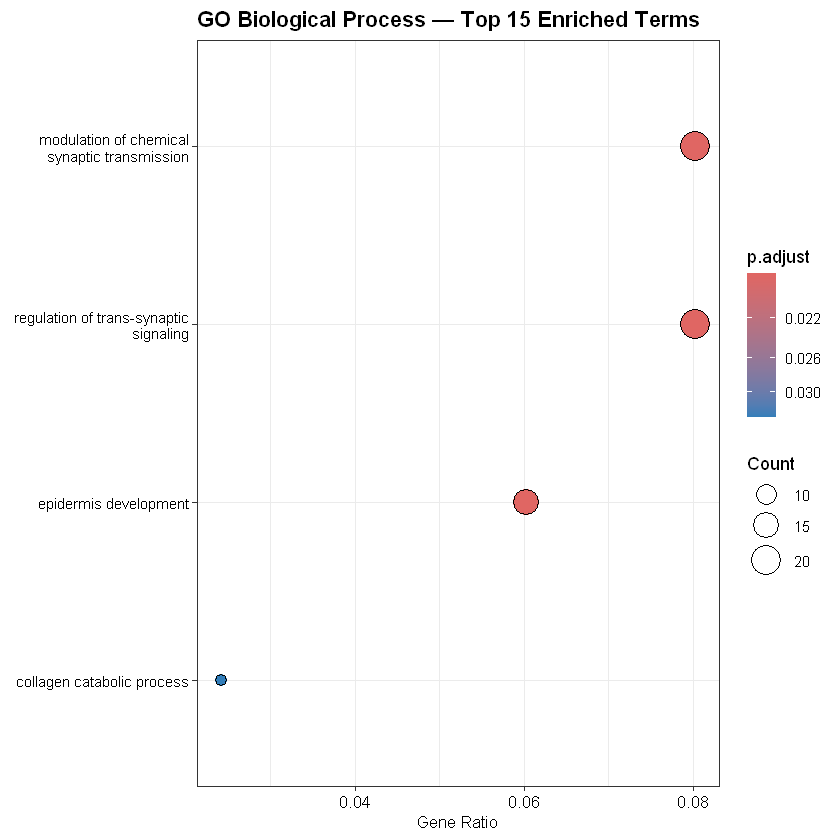

In [36]:
# ============================================================
# FUNCTIONAL ENRICHMENT - STEP 5: Visualizations
# ============================================================

# --- PART A: GO Biological Process Dotplot ---

cat("=== PART A: GO BP Dotplot ===\n")

bp_dotplot <- dotplot(
  go_bp,
  showCategory = 15,        # show top 15 terms
  font.size    = 10
) +
  labs(
    title    = "GO Biological Process — Top 15 Enriched Terms",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "GO_BP_dotplot.png",
  bp_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ GO_BP_dotplot.png saved\n")
print(bp_dotplot)


=== PART B: GO MF Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ GO_MF_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


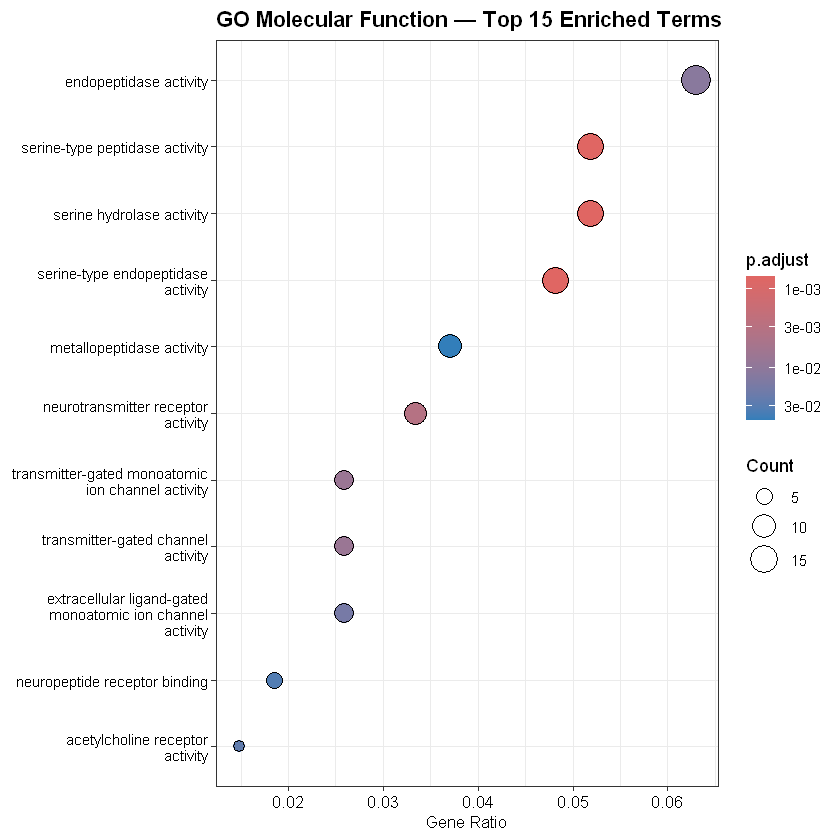

In [37]:
# --- PART B: GO Molecular Function Dotplot ---

cat("\n=== PART B: GO MF Dotplot ===\n")

mf_dotplot <- dotplot(
  go_mf,
  showCategory = 15,
  font.size    = 10
) +
  labs(
    title    = "GO Molecular Function — Top 15 Enriched Terms",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "GO_MF_dotplot.png",
  mf_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ GO_MF_dotplot.png saved\n")
print(mf_dotplot)


=== PART C: GO CC Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ GO_CC_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


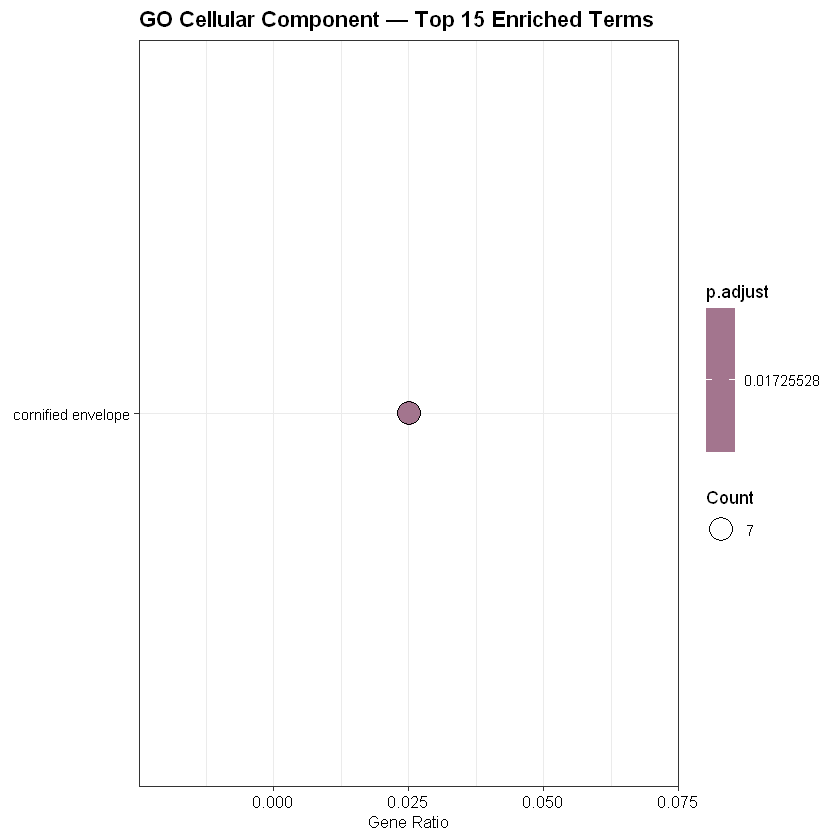

In [38]:
# --- PART C: GO Cellular Component Dotplot ---

cat("\n=== PART C: GO CC Dotplot ===\n")

cc_dotplot <- dotplot(
  go_cc,
  showCategory = 15,
  font.size    = 10
) +
  labs(
    title    = "GO Cellular Component — Top 15 Enriched Terms",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "GO_CC_dotplot.png",
  cc_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ GO_CC_dotplot.png saved\n")
print(cc_dotplot)


=== PART D: KEGG Dotplot ===


Ignoring unknown labels:
• colour : "Adjusted p-value"


✔ KEGG_dotplot.png saved


Ignoring unknown labels:
• colour : "Adjusted p-value"


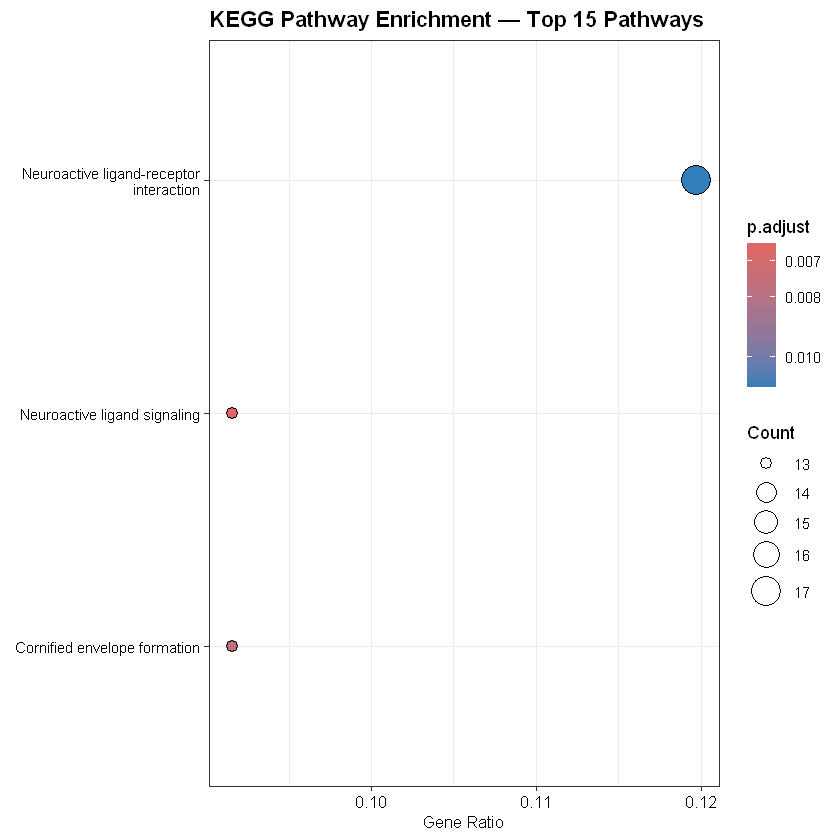

In [39]:
# --- PART D: KEGG Dotplot ---

cat("\n=== PART D: KEGG Dotplot ===\n")

kegg_dotplot <- dotplot(
  kegg_all,
  showCategory = 15,
  font.size    = 10
) +
  labs(
    title    = "KEGG Pathway Enrichment — Top 15 Pathways",
    x        = "Gene Ratio",
    color    = "Adjusted\np-value"
  ) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9)
  )

ggsave(
  "KEGG_dotplot.png",
  kegg_dotplot,
  width  = 10,
  height = 8,
  dpi    = 200
)

cat("✔ KEGG_dotplot.png saved\n")
print(kegg_dotplot)


=== PART E: KEGG Bubble Chart ===
✔ KEGG_bubble_chart.png saved


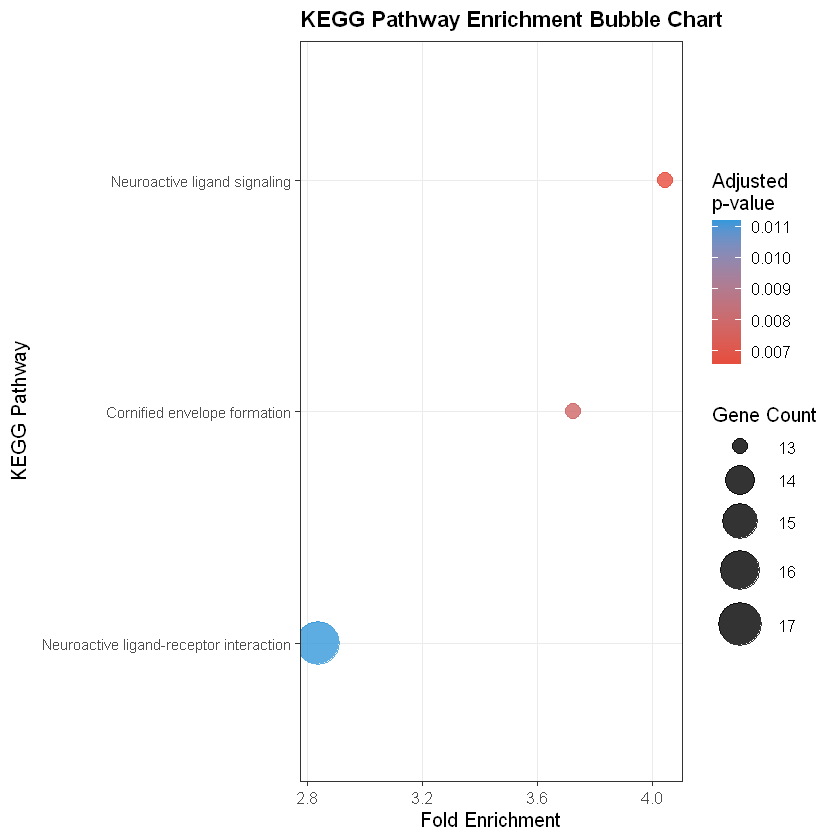

In [40]:
# --- PART E: KEGG Bubble Chart ---
# Bubble chart shows same info as dotplot
# but with bubble size = gene count
# and color = fold enrichment

cat("\n=== PART E: KEGG Bubble Chart ===\n")

# Extract KEGG results for plotting
kegg_plot_df <- kegg_all@result[
  kegg_all@result$p.adjust < 0.05, ]

# Calculate fold enrichment
# GeneRatio = k/n, BgRatio = K/N
# Fold enrichment = (k/n) / (K/N)
kegg_plot_df$GeneRatio_num <- sapply(
  kegg_plot_df$GeneRatio,
  function(x) eval(parse(text = x))
)

kegg_plot_df$BgRatio_num <- sapply(
  kegg_plot_df$BgRatio,
  function(x) eval(parse(text = x))
)

kegg_plot_df$FoldEnrichment <- (
  kegg_plot_df$GeneRatio_num / kegg_plot_df$BgRatio_num
)

# Keep top 15 by p.adjust
kegg_plot_df <- head(
  kegg_plot_df[order(kegg_plot_df$p.adjust), ], 15
)

# Reorder for plotting
kegg_plot_df$Description <- factor(
  kegg_plot_df$Description,
  levels = kegg_plot_df$Description[
    order(kegg_plot_df$FoldEnrichment)]
)

# Build bubble chart
bubble_chart <- ggplot(
  kegg_plot_df,
  aes(
    x    = FoldEnrichment,
    y    = Description,
    size = Count,
    color = p.adjust
  )
) +
  geom_point(alpha = 0.8) +
  scale_color_gradient(
    low  = "#E74C3C",   # red = more significant
    high = "#3498DB",   # blue = less significant
    name = "Adjusted\np-value"
  ) +
  scale_size_continuous(
    range = c(4, 12),
    name  = "Gene Count"
  ) +
  labs(
    title    = "KEGG Pathway Enrichment Bubble Chart",
    x        = "Fold Enrichment",
    y        = "KEGG Pathway"
  ) +
  theme_bw(base_size = 12) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(color = "gray40", size = 10),
    axis.text.y   = element_text(size = 9),
    panel.grid.minor = element_blank()
  )

ggsave(
  "KEGG_bubble_chart.png",
  bubble_chart,
  width  = 11,
  height = 8,
  dpi    = 200
)

cat("✔ KEGG_bubble_chart.png saved\n")
print(bubble_chart)

In [41]:
# --- PART F: Final summary ---

cat("\n============================================================\n")
cat("     FUNCTIONAL ENRICHMENT ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat(sprintf("  Location: %s\n\n", getwd()))
cat("Files saved:\n")
cat("  1. GO_BP_results.tsv\n")
cat("  2. GO_MF_results.tsv\n")
cat("  3. GO_CC_results.tsv\n")
cat("  4. KEGG_all_DEGs_results.tsv\n")
cat("  5. KEGG_upregulated_results.tsv\n")
cat("  6. KEGG_downregulated_results.tsv\n")
cat("  7. GO_BP_dotplot.png\n")
cat("  8. GO_MF_dotplot.png\n")
cat("  9. GO_CC_dotplot.png\n")
cat("  10. KEGG_dotplot.png\n")
cat("  11. KEGG_bubble_chart.png\n")
cat("============================================================\n")


     FUNCTIONAL ENRICHMENT ANALYSIS COMPLETE
  Location: C:/jupyter demo

Files saved:
  1. GO_BP_results.tsv
  2. GO_MF_results.tsv
  3. GO_CC_results.tsv
  4. KEGG_all_DEGs_results.tsv
  5. KEGG_upregulated_results.tsv
  6. KEGG_downregulated_results.tsv
  7. GO_BP_dotplot.png
  8. GO_MF_dotplot.png
  9. GO_CC_dotplot.png
  10. KEGG_dotplot.png
  11. KEGG_bubble_chart.png


In [50]:
# ============================================================
# Extract exact numbers for results section
# ============================================================

cat("=== GO Results ===\n\n")

# GO BP
bp_sig <- go_bp@result[go_bp@result$p.adjust < 0.05, ]
cat(sprintf("GO BP significant terms:  %d\n", nrow(bp_sig)))
cat("Top 5 BP terms:\n")
print(head(bp_sig[, c("Description", "Count", "p.adjust")], 5))

# GO MF
mf_sig <- go_mf@result[go_mf@result$p.adjust < 0.05, ]
cat(sprintf("\nGO MF significant terms:  %d\n", nrow(mf_sig)))
cat("Top 5 MF terms:\n")
print(head(mf_sig[, c("Description", "Count", "p.adjust")], 5))

# GO CC
cc_sig <- go_cc@result[go_cc@result$p.adjust < 0.05, ]
cat(sprintf("\nGO CC significant terms:  %d\n", nrow(cc_sig)))
cat("Top 5 CC terms:\n")
print(head(cc_sig[, c("Description", "Count", "p.adjust")], 5))

cat("\n=== KEGG Results ===\n\n")

# KEGG all
kegg_sig <- kegg_all@result[kegg_all@result$p.adjust < 0.05, ]
cat(sprintf("KEGG significant pathways: %d\n", nrow(kegg_sig)))
cat("Top 10 KEGG pathways:\n")
print(head(kegg_sig[, c("Description", "Count", "p.adjust")], 10))

# KEGG up
kegg_up_sig <- kegg_up@result[kegg_up@result$p.adjust < 0.05, ]
cat(sprintf("\nKEGG upregulated pathways: %d\n", nrow(kegg_up_sig)))
cat("Top 5:\n")
print(head(kegg_up_sig[, c("Description", "Count", "p.adjust")], 5))

# KEGG down
kegg_down_sig <- kegg_down@result[kegg_down@result$p.adjust < 0.05, ]
cat(sprintf("\nKEGG downregulated pathways: %d\n", nrow(kegg_down_sig)))
cat("Top 5:\n")
print(head(kegg_down_sig[, c("Description", "Count", "p.adjust")], 5))

=== GO Results ===

GO BP significant terms:  4
Top 5 BP terms:
                                            Description Count   p.adjust
GO:0050804 modulation of chemical synaptic transmission    20 0.01827100
GO:0008544                        epidermis development    15 0.01827100
GO:0099177       regulation of trans-synaptic signaling    20 0.01827100
GO:0030574                   collagen catabolic process     6 0.03346861

GO MF significant terms:  11
Top 5 MF terms:
                                                 Description Count     p.adjust
GO:0008236                    serine-type peptidase activity    14 0.0006917673
GO:0017171                         serine hydrolase activity    14 0.0006917673
GO:0004252                serine-type endopeptidase activity    13 0.0006917673
GO:0030594                neurotransmitter receptor activity     9 0.0031858036
GO:0022824 transmitter-gated monoatomic ion channel activity     7 0.0071647942

GO CC significant terms:  1
Top 5 CC terms:


In [12]:
# ============================================================
# QUICK REBUILD
# ============================================================

library(limma)
library(edgeR)
library(data.table)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(sva)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ggVennDiagram)

cat("✔ Libraries loaded\n")

✔ Libraries loaded


In [13]:
# Load final matrix
cat("Loading final matrix...\n")

final_df <- fread(
  "C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv",
  header = TRUE,
  sep    = "\t"
)

final_matrix <- as.matrix(final_df[, -1])
rownames(final_matrix) <- final_df$Gene

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

Loading final matrix...


Warning message in (if (.Platform$OS.type == "unix") system else shell)(paste0("(", :
"'(C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv) > C:\Users\aryan\AppData\Local\Temp\RtmpOGlLUO\file538ce91191c' execution failed with error code 1"


ERROR: Error in fread("C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv", : External command failed with exit code 1. This can happen when the disk is full in the temporary directory ('C:\Users\aryan\AppData\Local\Temp\RtmpOGlLUO'). See ?fread for the tmpdir argument.


In [14]:
# --- Fix 1: Check disk space and temp directory ---
cat("Checking temp directory...\n")
cat(sprintf("Temp dir: %s\n", tempdir()))

# --- Fix 2: Use read.table instead of fread ---
# read.table handles spaces in paths better

cat("\nLoading final matrix using read.table...\n")

final_df <- read.table(
  "C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv",
  header    = TRUE,
  sep       = "\t",
  row.names = 1,      # first column as rownames
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

Checking temp directory...
Temp dir: C:\Users\aryan\AppData\Local\Temp\RtmpOGlLUO

Loading final matrix using read.table...


Warning message in file(file, "rt"):
"cannot open file 'C:/jupyter demo/TCGA_LUSC_LUAD_final_expression.tsv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [15]:
# --- Find the file ---
cat("Searching for the file...\n\n")

# Check working directory
cat(sprintf("Current working directory: %s\n\n", getwd()))

# List ALL tsv files on common locations
cat("TSV files in C:/jupyter demo:\n")
print(list.files("C:/jupyter demo", 
                 pattern = "*.tsv", 
                 full.names = TRUE))

cat("\nTSV files in Downloads:\n")
print(list.files("C:/Users/aryan/Downloads",
                 pattern = "*.tsv",
                 full.names = TRUE))

cat("\nAll files in C:/jupyter demo:\n")
print(list.files("C:/jupyter demo", 
                 full.names = TRUE))

Searching for the file...

Current working directory: C:/jupyter demo

TSV files in C:/jupyter demo:
[1] "C:/jupyter demo/GO_BP_results.tsv"             
[2] "C:/jupyter demo/GO_CC_results.tsv"             
[3] "C:/jupyter demo/GO_MF_results.tsv"             
[4] "C:/jupyter demo/KEGG_all_DEGs_results.tsv"     
[5] "C:/jupyter demo/KEGG_downregulated_results.tsv"
[6] "C:/jupyter demo/KEGG_upregulated_results.tsv"  

TSV files in Downloads:
[1] "C:/Users/aryan/Downloads/DEG_full_results.tsv"               
[2] "C:/Users/aryan/Downloads/DEG_significant_only.tsv"           
[3] "C:/Users/aryan/Downloads/Shared_DEGs_LUSC_LUAD.tsv"          
[4] "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv"          
[5] "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz"       
[6] "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv"          
[7] "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz"       
[8] "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv"

All files in C:/jup

In [16]:
# --- Load deg_results directly from saved RDS file ---
cat("Loading deg_results from RDS file...\n")

deg_results <- readRDS("C:/jupyter demo/deg_results.rds")

cat(sprintf("✔ deg_results loaded: %d genes\n", nrow(deg_results)))
cat(sprintf("✔ Upregulated:   %d\n",
            sum(deg_results$Status == "Upregulated")))
cat(sprintf("✔ Downregulated: %d\n",
            sum(deg_results$Status == "Downregulated")))

Loading deg_results from RDS file...
✔ deg_results loaded: 36650 genes
✔ Upregulated:   167
✔ Downregulated: 210


In [17]:
# --- Load final matrix from Downloads ---
cat("\nLoading final matrix from Downloads...\n")

final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))


Loading final matrix from Downloads...
✔ final_matrix: 36650 genes × 1139 samples


In [19]:
# --- Rebuild remaining objects ---

# Batch labels
lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)
luad_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUAD.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5
)

lusc_sample_names <- colnames(lusc_check)[-1]

final_batch <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD"
)

# Metadata
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor"
)

metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix)
)

# Shifted matrix
final_matrix_shifted <- final_matrix - min(final_matrix)

cat(sprintf("✔ Metadata: Tumor=%d | Normal=%d\n",
            sum(metadata$SampleType == "Tumor"),
            sum(metadata$SampleType == "Normal")))
cat(sprintf("✔ Shifted matrix: Min=%.3f | Max=%.3f\n",
            min(final_matrix_shifted),
            max(final_matrix_shifted)))

✔ Metadata: Tumor=1029 | Normal=110
✔ Shifted matrix: Min=0.000 | Max=39.004


In [20]:
# --- Final verification ---
cat("\n=== Checking Key Objects ===\n")
cat(sprintf("final_matrix:         %s\n", exists("final_matrix")))
cat(sprintf("final_matrix_shifted: %s\n", exists("final_matrix_shifted")))
cat(sprintf("metadata:             %s\n", exists("metadata")))
cat(sprintf("deg_results:          %s\n", exists("deg_results")))
cat(sprintf("final_batch:          %s\n", exists("final_batch")))


=== Checking Key Objects ===
final_matrix:         TRUE
final_matrix_shifted: TRUE
metadata:             TRUE
deg_results:          TRUE
final_batch:          TRUE


In [21]:
# ============================================================
# PPI NETWORK - STEP 1: Export Upregulated DEGs
# ============================================================

cat("=== STEP 1: Extracting Upregulated DEGs ===\n\n")

# Extract upregulated genes
up_degs <- deg_results[deg_results$Status == "Upregulated", ]
up_degs <- up_degs[order(-up_degs$logFC), ]

# Get gene names
up_gene_list <- rownames(up_degs)

cat(sprintf("Total upregulated DEGs:  %d\n", length(up_gene_list)))
cat(sprintf("logFC range:             [%.3f, %.3f]\n",
            min(up_degs$logFC), max(up_degs$logFC)))

cat("\nTop 10 upregulated genes:\n")
print(head(up_gene_list, 10))

# Save to working directory
write.table(
  data.frame(Gene = up_gene_list),
  file      = "Upregulated_DEGs_for_STRING.txt",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("\n✔ Gene list saved: Upregulated_DEGs_for_STRING.txt\n"))
cat(sprintf("  Location: %s\n", getwd()))

=== STEP 1: Extracting Upregulated DEGs ===

Total upregulated DEGs:  167
logFC range:             [0.501, 0.884]

Top 10 upregulated genes:
 [1] "CASC9"      "PITX2"      "HOXC13"     "PRAME"      "CST1"      
 [6] "LCAL1"      "SACK1A-AS1" "BARX1"      "BBOX1-AS1"  "GABRA3"    

✔ Gene list saved: Upregulated_DEGs_for_STRING.txt
  Location: C:/jupyter demo


In [22]:
# ============================================================
# PPI NETWORK - STEP 2: Query STRING Database
# ============================================================

# --- Install required packages ---
if (!requireNamespace("httr", quietly = TRUE))
  install.packages("httr")
if (!requireNamespace("jsonlite", quietly = TRUE))
  install.packages("jsonlite")
if (!requireNamespace("igraph", quietly = TRUE))
  install.packages("igraph")

library(httr)
library(jsonlite)
library(igraph)

cat("✔ Packages loaded\n\n")


Attaching package: 'httr'


The following object is masked from 'package:Biobase':

    content




✔ Packages loaded



In [23]:
# --- PART A: Map gene symbols to STRING IDs ---
# STRING uses its own IDs so we need to map first

cat("=== PART A: Mapping genes to STRING IDs ===\n\n")

# Collapse gene list into one string for API
genes_string <- paste(up_gene_list, collapse = "%0d")

# Query STRING mapping API
map_url <- "https://string-db.org/api/json/get_string_ids"

map_response <- POST(
  map_url,
  body = list(
    identifiers   = paste(up_gene_list, collapse = "\r"),
    species       = "9606",   # 9606 = Homo sapiens
    limit         = "1",      # take best match per gene
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

# Parse response
map_data <- fromJSON(content(map_response, "text",
                             encoding = "UTF-8"))

cat(sprintf("Genes submitted:    %d\n", length(up_gene_list)))
cat(sprintf("Genes mapped:       %d\n", nrow(map_data)))

# Preview mapping
cat("\nFirst 5 mapped genes:\n")
print(head(map_data[, c("queryItem", "preferredName",
                         "stringId")], 5))

=== PART A: Mapping genes to STRING IDs ===

Genes submitted:    167
Genes mapped:       129

First 5 mapped genes:
  queryItem preferredName             stringId
1     PITX2         PITX2 9606.ENSP00000495061
2    HOXC13        HOXC13 9606.ENSP00000243056
3     PRAME         PRAME 9606.ENSP00000445675
4      CST1          CST1 9606.ENSP00000305731
5     BARX1         BARX1 9606.ENSP00000253968


In [24]:
# --- PART B: Get interactions from STRING ---
# Now query interactions using mapped STRING IDs

cat("\n=== PART B: Fetching Interactions from STRING ===\n\n")
cat("This may take 1-2 minutes...\n")

# Get STRING IDs
string_ids <- paste(map_data$stringId, collapse = "%0d")

# Query interaction network
int_url <- "https://string-db.org/api/json/network"

int_response <- POST(
  int_url,
  body = list(
    identifiers     = paste(map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",  # 0.4 confidence = 400
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

# Parse interactions
interactions <- fromJSON(content(int_response, "text",
                                 encoding = "UTF-8"))

cat(sprintf("✔ Total interactions fetched: %d\n",
            nrow(interactions)))
cat(sprintf("✔ Confidence score threshold: 0.4\n"))

# Preview
cat("\nFirst 5 interactions:\n")
print(head(interactions[, c("preferredName_A",
                             "preferredName_B",
                             "score")], 5))


=== PART B: Fetching Interactions from STRING ===

This may take 1-2 minutes...
✔ Total interactions fetched: 122
✔ Confidence score threshold: 0.4

First 5 interactions:
  preferredName_A preferredName_B score
1           MMP11           MMP13 0.443
2           MMP11         COL11A1 0.732
3           MMP11            MMP1 0.772
4            MIOX         AKR1B10 0.820
5         CYP24A1             CA9 0.784


In [25]:
# --- PART C: Filter and clean interactions ---

cat("\n=== PART C: Filtering Interactions ===\n\n")

# Keep only interactions with score >= 0.4
interactions_filtered <- interactions[
  interactions$score >= 0.4, ]

cat(sprintf("Interactions before filter: %d\n", nrow(interactions)))
cat(sprintf("Interactions after filter:  %d\n",
            nrow(interactions_filtered)))

# Extract clean edge list
edge_list <- data.frame(
  Gene_A = interactions_filtered$preferredName_A,
  Gene_B = interactions_filtered$preferredName_B,
  Score  = interactions_filtered$score
)

# Save edge list
write.table(
  edge_list,
  file      = "STRING_interactions.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Edge list saved: STRING_interactions.tsv\n")
cat(sprintf("  Location: %s\n", getwd()))


=== PART C: Filtering Interactions ===

Interactions before filter: 122
Interactions after filter:  122
✔ Edge list saved: STRING_interactions.tsv
  Location: C:/jupyter demo


In [26]:
# --- PART D: Check if TOP2A is in network ---

cat("\n=== Checking TOP2A in Network ===\n\n")

top2a_interactions <- edge_list[
  edge_list$Gene_A == "TOP2A" |
  edge_list$Gene_B == "TOP2A", ]

cat(sprintf("TOP2A interactions found: %d\n",
            nrow(top2a_interactions)))

if (nrow(top2a_interactions) > 0) {
  cat("\nTOP2A interaction partners:\n")
  print(top2a_interactions)
} else {
  cat("⚠ TOP2A not found in upregulated network\n")
  cat("  This is expected since TOP2A was below logFC threshold\n")
  cat("  We will add it manually in next step\n")
}


=== Checking TOP2A in Network ===

TOP2A interactions found: 0
⚠ TOP2A not found in upregulated network
  This is expected since TOP2A was below logFC threshold
  We will add it manually in next step


In [27]:
# ============================================================
# TOP 10 HUB GENES BY DEGREE
# ============================================================

cat("=== Top 10 Hub Genes by Degree ===\n\n")

# Build network from edge list
network <- graph_from_data_frame(
  edge_list,
  directed = FALSE
)

# Calculate degree for each gene
# Degree = number of connections a gene has
degree_scores <- degree(network)

# Sort by degree (highest first)
degree_sorted <- sort(degree_scores, decreasing = TRUE)

# Top 10
top10_genes <- head(degree_sorted, 10)

cat("Top 10 Hub Genes:\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(top10_genes)[i],
              top10_genes[i]))
}

# Save top 10
top10_df <- data.frame(
  Rank        = 1:10,
  Gene        = names(top10_genes),
  Connections = as.numeric(top10_genes)
)

write.table(
  top10_df,
  file      = "Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat(sprintf("\n✔ Top 10 hub genes saved: Top10_Hub_Genes.tsv\n"))
cat(sprintf("  Location: %s\n", getwd()))

=== Top 10 Hub Genes by Degree ===

Top 10 Hub Genes:

Rank  Gene            Connections
----------------------------------- 
1     KRT16           12
2     KRT6B           11
3     KRT6A           10
4     SPRR1B          9
5     SPRR3           8
6     LHX2            8
7     KRT6C           6
8     DSG3            6
9     MMP13           6
10    SERPINB4        6

✔ Top 10 hub genes saved: Top10_Hub_Genes.tsv
  Location: C:/jupyter demo


In [28]:
# ============================================================
# Check CST1 connections
# ============================================================

cat("=== CST1 Network Information ===\n\n")

# Check if CST1 is in network
if ("CST1" %in% names(degree_scores)) {
  
  cat(sprintf("CST1 total connections: %d\n\n",
              degree_scores["CST1"]))
  
  # Find all genes CST1 connects to
  cst1_partners <- edge_list[
    edge_list$Gene_A == "CST1" |
    edge_list$Gene_B == "CST1", ]
  
  cat(sprintf("CST1 interaction partners:\n\n"))
  cat(sprintf("%-5s %-15s %-15s %s\n",
              "No.", "Gene_A", "Gene_B", "Score"))
  cat(paste(rep("-", 45), collapse = ""), "\n")
  
  for (i in 1:nrow(cst1_partners)) {
    cat(sprintf("%-5d %-15s %-15s %.3f\n",
                i,
                cst1_partners$Gene_A[i],
                cst1_partners$Gene_B[i],
                cst1_partners$Score[i]))
  }
  
} else {
  cat("⚠ CST1 not found in network\n")
  cat("  CST1 may have no interactions above 0.4 threshold\n")
}

=== CST1 Network Information ===

CST1 total connections: 1

CST1 interaction partners:

No.   Gene_A          Gene_B          Score
--------------------------------------------- 
1     CST4            CST1            0.929


In [29]:
# ============================================================
# Check KRT16, KRT6B, KRT6A connections
# ============================================================

cat("=== Keratin Gene Network Information ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  if (gene %in% names(degree_scores)) {
    
    cat(sprintf("Total connections: %d\n", 
                degree_scores[gene]))
    
    # Find all partners
    partners <- edge_list[
      edge_list$Gene_A == gene |
      edge_list$Gene_B == gene, ]
    
    # Get partner names
    partner_names <- ifelse(
      partners$Gene_A == gene,
      partners$Gene_B,
      partners$Gene_A
    )
    
    cat(sprintf("Interaction partners:\n"))
    for (i in 1:nrow(partners)) {
      cat(sprintf("  %d. %-15s Score: %.3f\n",
                  i,
                  partner_names[i],
                  partners$Score[i]))
    }
    
  } else {
    cat("⚠ Not found in network\n")
  }
  
  cat("\n")
}

# Compare all three
cat("=== Comparison Summary ===\n\n")
cat(sprintf("%-10s %s\n", "Gene", "Connections"))
cat(paste(rep("-", 25), collapse = ""), "\n")

for (gene in keratin_genes) {
  if (gene %in% names(degree_scores)) {
    cat(sprintf("%-10s %d\n", gene, degree_scores[gene]))
  } else {
    cat(sprintf("%-10s Not in network\n", gene))
  }
}

=== Keratin Gene Network Information ===

--- KRT16 ---
Total connections: 12
Interaction partners:
  1. KRT75           Score: 0.458
  2. KRT6C           Score: 0.502
  3. KRT6B           Score: 0.938
  4. DSG3            Score: 0.570
  5. IL36G           Score: 0.419
  6. LY6D            Score: 0.495
  7. KLK6            Score: 0.469
  8. SERPINB4        Score: 0.480
  9. SBSN            Score: 0.489
  10. SPRR3           Score: 0.582
  11. SPRR1B          Score: 0.687
  12. KRT6A           Score: 0.928

--- KRT6B ---
Total connections: 11
Interaction partners:
  1. KRT75           Score: 0.555
  2. KRT6C           Score: 0.772
  3. TMPRSS11D       Score: 0.414
  4. KLK6            Score: 0.542
  5. SERPINB5        Score: 0.552
  6. SERPINB4        Score: 0.569
  7. SPRR3           Score: 0.607
  8. SPRR1B          Score: 0.741
  9. DSG3            Score: 0.786
  10. KRT6A           Score: 0.886
  11. KRT16           Score: 0.938

--- KRT6A ---
Total connections: 10
Interaction partn

In [30]:
# ============================================================
# Check Keratin genes in LUSC and LUAD separately
# ============================================================

cat("=== Keratin Gene Expression Analysis ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Check if gene exists in our data
  if (gene %in% rownames(deg_results)) {
    
    # Overall DEG status
    cat(sprintf("Overall logFC:      %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("Overall adj.p:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Overall Status:     %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # Check in LUSC specific
    if (gene %in% sig_lusc) {
      lusc_fc <- deg_lusc[gene, "logFC"]
      lusc_p  <- deg_lusc[gene, "adj.P.Val"]
      cat(sprintf("LUSC:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  lusc_fc, lusc_p))
    } else {
      cat(sprintf("LUSC:               ✘ Not significant\n"))
    }
    
    # Check in LUAD specific
    if (gene %in% sig_luad) {
      luad_fc <- deg_luad[gene, "logFC"]
      luad_p  <- deg_luad[gene, "adj.P.Val"]
      cat(sprintf("LUAD:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  luad_fc, luad_p))
    } else {
      cat(sprintf("LUAD:               ✘ Not significant\n"))
    }
    
    # Check in shared DEGs
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:        ✔ YES — found in both\n"))
    } else {
      cat(sprintf("Shared DEGs:        ✘ NOT shared\n"))
    }
    
  } else {
    cat(sprintf("⚠ %s not found in DEG results\n", gene))
  }
  
  cat("\n")
}

=== Keratin Gene Expression Analysis ===

--- KRT16 ---
Overall logFC:      0.6894
Overall adj.p:      1.06e-19
Overall Status:     Upregulated


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'table' in selecting a method for function '%in%': object 'sig_lusc' not found


In [31]:
# ============================================================
# Rebuild sig_lusc and sig_luad
# ============================================================

cat("Rebuilding LUSC and LUAD specific DEGs...\n\n")

library(limma)

# Split samples by dataset
lusc_samples <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples <- rownames(metadata[metadata$Dataset == "LUAD", ])

lusc_mat_deg <- final_matrix_shifted[, lusc_samples]
luad_mat_deg <- final_matrix_shifted[, luad_samples]

lusc_meta <- metadata[lusc_samples, ]
luad_meta <- metadata[luad_samples, ]

# --- LUSC DEGs ---
design_lusc <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
voom_lusc   <- voom(lusc_mat_deg, design_lusc, plot = FALSE)
fit_lusc    <- lmFit(voom_lusc, design_lusc)
contrast_lusc <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_lusc)
fit_lusc2   <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2   <- eBayes(fit_lusc2)
deg_lusc    <- topTable(fit_lusc2, coef = "TumorVsNormal",
                        number = Inf, adjust.method = "BH")
sig_lusc    <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUSC DEGs: %d\n", length(sig_lusc)))

# --- LUAD DEGs ---
design_luad <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
voom_luad   <- voom(luad_mat_deg, design_luad, plot = FALSE)
fit_luad    <- lmFit(voom_luad, design_luad)
contrast_luad <- makeContrasts(
  TumorVsNormal = Tumor - Normal,
  levels = design_luad)
fit_luad2   <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2   <- eBayes(fit_luad2)
deg_luad    <- topTable(fit_luad2, coef = "TumorVsNormal",
                        number = Inf, adjust.method = "BH")
sig_luad    <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

cat(sprintf("✔ LUAD DEGs: %d\n", length(sig_luad)))

# Shared DEGs
common_degs <- intersect(sig_lusc, sig_luad)
cat(sprintf("✔ Shared DEGs: %d\n", length(common_degs)))

Rebuilding LUSC and LUAD specific DEGs...

✔ LUSC DEGs: 852
✔ LUAD DEGs: 232
✔ Shared DEGs: 168


In [32]:
# ============================================================
# Check Keratin genes in LUSC and LUAD separately
# ============================================================

cat("=== Keratin Gene Expression Analysis ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Check if gene exists in our data
  if (gene %in% rownames(deg_results)) {
    
    # Overall DEG status
    cat(sprintf("Overall logFC:      %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("Overall adj.p:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Overall Status:     %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # Check in LUSC specific
    if (gene %in% sig_lusc) {
      lusc_fc <- deg_lusc[gene, "logFC"]
      lusc_p  <- deg_lusc[gene, "adj.P.Val"]
      cat(sprintf("LUSC:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  lusc_fc, lusc_p))
    } else {
      cat(sprintf("LUSC:               ✘ Not significant\n"))
    }
    
    # Check in LUAD specific
    if (gene %in% sig_luad) {
      luad_fc <- deg_luad[gene, "logFC"]
      luad_p  <- deg_luad[gene, "adj.P.Val"]
      cat(sprintf("LUAD:               ✔ SIGNIFICANT (logFC=%.3f, p=%.2e)\n",
                  luad_fc, luad_p))
    } else {
      cat(sprintf("LUAD:               ✘ Not significant\n"))
    }
    
    # Check in shared DEGs
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:        ✔ YES — found in both\n"))
    } else {
      cat(sprintf("Shared DEGs:        ✘ NOT shared\n"))
    }
    
  } else {
    cat(sprintf("⚠ %s not found in DEG results\n", gene))
  }
  
  cat("\n")
}

=== Keratin Gene Expression Analysis ===

--- KRT16 ---
Overall logFC:      0.6894
Overall adj.p:      1.06e-19
Overall Status:     Upregulated
LUSC:               ✔ SIGNIFICANT (logFC=0.925, p=6.00e-13)
LUAD:               ✘ Not significant
Shared DEGs:        ✘ NOT shared

--- KRT6B ---
Overall logFC:      0.5924
Overall adj.p:      4.38e-18
Overall Status:     Upregulated
LUSC:               ✔ SIGNIFICANT (logFC=1.048, p=6.63e-19)
LUAD:               ✘ Not significant
Shared DEGs:        ✘ NOT shared

--- KRT6A ---
Overall logFC:      0.6497
Overall adj.p:      9.93e-15
Overall Status:     Upregulated
LUSC:               ✔ SIGNIFICANT (logFC=1.031, p=2.14e-10)
LUAD:               ✘ Not significant
Shared DEGs:        ✘ NOT shared



In [33]:
# ============================================================
# Find Shared Hub Genes in Both LUSC and LUAD
# ============================================================

cat("=== Shared Hub Genes Analysis ===\n\n")

# Check which of our top 10 network hub genes
# are present in both LUSC and LUAD

# First get top 10 hub genes from network
top10_genes <- names(head(sort(degree_scores, 
                               decreasing = TRUE), 10))

cat("Checking top 10 network hub genes:\n\n")
cat(sprintf("%-5s %-15s %-12s %-12s %-10s %-10s\n",
            "Rank", "Gene", "LUSC", "LUAD", 
            "Shared", "Connections"))
cat(paste(rep("-", 65), collapse = ""), "\n")

for (i in 1:length(top10_genes)) {
  gene <- top10_genes[i]
  
  in_lusc   <- ifelse(gene %in% sig_lusc, "✔ YES", "✘ NO")
  in_luad   <- ifelse(gene %in% sig_luad, "✔ YES", "✘ NO")
  in_shared <- ifelse(gene %in% common_degs, "✔ YES", "✘ NO")
  connections <- degree_scores[gene]
  
  cat(sprintf("%-5d %-15s %-12s %-12s %-10s %-10d\n",
              i, gene, in_lusc, in_luad,
              in_shared, connections))
}

=== Shared Hub Genes Analysis ===

Checking top 10 network hub genes:

Rank  Gene            LUSC         LUAD         Shared     Connections
----------------------------------------------------------------- 
1     KRT16           ✔ YES      ✘ NO       ✘ NO     12        
2     KRT6B           ✔ YES      ✘ NO       ✘ NO     11        
3     KRT6A           ✔ YES      ✘ NO       ✘ NO     10        
4     SPRR1B          ✔ YES      ✘ NO       ✘ NO     9         
5     SPRR3           ✔ YES      ✘ NO       ✘ NO     8         
6     LHX2            ✔ YES      ✘ NO       ✘ NO     8         
7     KRT6C           ✔ YES      ✘ NO       ✘ NO     6         
8     DSG3            ✔ YES      ✘ NO       ✘ NO     6         
9     MMP13           ✔ YES      ✔ YES      ✔ YES    6         
10    SERPINB4        ✔ YES      ✘ NO       ✘ NO     6         


In [34]:
# --- Find shared upregulated hub genes ---

cat("\n=== Shared Upregulated Hub Genes ===\n\n")

# Genes that are:
# 1. In our network (upregulated DEGs)
# 2. Significant in LUSC
# 3. Significant in LUAD
# 4. In common_degs (shared)

network_genes  <- names(degree_scores)

shared_hub_candidates <- network_genes[
  network_genes %in% common_degs
]

cat(sprintf("Network genes in shared DEGs: %d\n\n",
            length(shared_hub_candidates)))

if (length(shared_hub_candidates) > 0) {
  
  # Get their degree scores
  shared_hub_df <- data.frame(
    Gene        = shared_hub_candidates,
    Connections = degree_scores[shared_hub_candidates],
    logFC       = deg_results[shared_hub_candidates, "logFC"],
    adj.P.Val   = deg_results[shared_hub_candidates, "adj.P.Val"]
  )
  
  # Sort by connections
  shared_hub_df <- shared_hub_df[
    order(-shared_hub_df$Connections), ]
  
  cat("Shared hub genes ranked by connections:\n\n")
  cat(sprintf("%-5s %-15s %-12s %-10s %s\n",
              "Rank", "Gene", "Connections", 
              "logFC", "adj.P.Val"))
  cat(paste(rep("-", 55), collapse = ""), "\n")
  
  for (i in 1:nrow(shared_hub_df)) {
    cat(sprintf("%-5d %-15s %-12d %-10.3f %.2e\n",
                i,
                shared_hub_df$Gene[i],
                shared_hub_df$Connections[i],
                shared_hub_df$logFC[i],
                shared_hub_df$adj.P.Val[i]))
  }
  
  # Save
  write.table(
    shared_hub_df,
    file      = "Shared_Hub_Genes.tsv",
    sep       = "\t",
    row.names = FALSE,
    quote     = FALSE
  )
  
  cat(sprintf("\n✔ Shared hub genes saved: Shared_Hub_Genes.tsv\n"))
  
} else {
  cat("⚠ No shared hub genes found in network\n")
  cat("  This means upregulated shared DEGs have\n")
  cat("  no STRING interactions above 0.4 threshold\n")
  cat("  We will lower confidence threshold to 0.2\n")
}


=== Shared Upregulated Hub Genes ===

Network genes in shared DEGs: 13

Shared hub genes ranked by connections:

Rank  Gene            Connections  logFC      adj.P.Val
------------------------------------------------------- 
1     MMP13           6            0.633      1.15e-21
2     COL11A1         5            0.630      1.69e-25
3     PRAME           3            0.850      7.36e-22
4     KISS1R          2            0.613      8.14e-67
5     IL36RN          2            0.732      2.04e-36
6     TERT            2            0.708      4.08e-113
7     FEZF1           2            0.624      1.87e-33
8     LY6D            1            0.618      1.25e-19
9     ZYG11A          1            0.670      2.14e-55
10    PITX2           1            0.867      8.87e-57
11    CA9             1            0.641      1.70e-26
12    CST1            1            0.832      1.18e-32
13    IL1RAPL2        1            0.560      1.97e-104

✔ Shared hub genes saved: Shared_Hub_Genes.tsv


In [35]:
# ============================================================
# PPI NETWORK - All 13 Shared Hub Genes
# ============================================================

cat("=== Building Network for All 13 Shared Hub Genes ===\n\n")

# Our 13 shared hub genes
hub_genes <- shared_hub_df$Gene

cat("Hub genes selected:\n")
for (i in 1:length(hub_genes)) {
  cat(sprintf("  %d. %s\n", i, hub_genes[i]))
}

=== Building Network for All 13 Shared Hub Genes ===

Hub genes selected:
  1. MMP13
  2. COL11A1
  3. PRAME
  4. KISS1R
  5. IL36RN
  6. TERT
  7. FEZF1
  8. LY6D
  9. ZYG11A
  10. PITX2
  11. CA9
  12. CST1
  13. IL1RAPL2


In [36]:
# --- Extract interactions involving hub genes ---
# From our existing edge list, find all interactions
# where at least one gene is a hub gene

cat("\n=== Extracting Hub Gene Interactions ===\n\n")

hub_interactions <- edge_list[
  edge_list$Gene_A %in% hub_genes |
  edge_list$Gene_B %in% hub_genes, ]

cat(sprintf("Total interactions involving hub genes: %d\n",
            nrow(hub_interactions)))

# Find all unique genes in this subnetwork
all_network_genes <- unique(c(
  hub_interactions$Gene_A,
  hub_interactions$Gene_B
))

cat(sprintf("Total genes in subnetwork:              %d\n",
            length(all_network_genes)))

cat("\nInteractions per hub gene:\n")
for (gene in hub_genes) {
  n_int <- sum(hub_interactions$Gene_A == gene |
               hub_interactions$Gene_B == gene)
  cat(sprintf("  %-15s %d interactions\n", gene, n_int))
}


=== Extracting Hub Gene Interactions ===

Total interactions involving hub genes: 25
Total genes in subnetwork:              31

Interactions per hub gene:
  MMP13           6 interactions
  COL11A1         5 interactions
  PRAME           3 interactions
  KISS1R          2 interactions
  IL36RN          2 interactions
  TERT            2 interactions
  FEZF1           2 interactions
  LY6D            1 interactions
  ZYG11A          1 interactions
  PITX2           1 interactions
  CA9             1 interactions
  CST1            1 interactions
  IL1RAPL2        1 interactions


In [37]:
# --- Build igraph network ---

cat("\n=== Building igraph Network ===\n\n")

hub_network <- graph_from_data_frame(
  hub_interactions,
  directed = FALSE
)

# Network statistics
cat(sprintf("Network nodes (genes):  %d\n",
            vcount(hub_network)))
cat(sprintf("Network edges:          %d\n",
            ecount(hub_network)))
cat(sprintf("Network density:        %.4f\n",
            edge_density(hub_network)))

# Degree of each hub gene in subnetwork
hub_degrees <- degree(hub_network)
hub_degrees_sorted <- sort(
  hub_degrees[hub_genes[hub_genes %in% names(hub_degrees)]],
  decreasing = TRUE
)

cat("\nHub gene degrees in subnetwork:\n")
print(hub_degrees_sorted)


=== Building igraph Network ===

Network nodes (genes):  31
Network edges:          25
Network density:        0.0538

Hub gene degrees in subnetwork:
   MMP13  COL11A1    PRAME   KISS1R   IL36RN     TERT    FEZF1     LY6D 
       6        5        3        2        2        2        2        1 
  ZYG11A    PITX2      CA9     CST1 IL1RAPL2 
       1        1        1        1        1 


In [38]:
# --- Save network files for Cytoscape ---

cat("\n=== Saving Network Files ===\n\n")

# Save edge list
write.table(
  hub_interactions,
  file      = "Hub_Gene_Network_edges.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

# Save node list with attributes
node_df <- data.frame(
  Gene       = all_network_genes,
  IsHub      = ifelse(all_network_genes %in% hub_genes,
                      "Hub", "Neighbor"),
  Degree     = hub_degrees[all_network_genes],
  InLUSC     = ifelse(all_network_genes %in% sig_lusc,
                      "Yes", "No"),
  InLUAD     = ifelse(all_network_genes %in% sig_luad,
                      "Yes", "No"),
  IsShared   = ifelse(all_network_genes %in% common_degs,
                      "Yes", "No")
)

write.table(
  node_df,
  file      = "Hub_Gene_Network_nodes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ Edge list saved: Hub_Gene_Network_edges.tsv\n")
cat("✔ Node list saved: Hub_Gene_Network_nodes.tsv\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Saving Network Files ===

✔ Edge list saved: Hub_Gene_Network_edges.tsv
✔ Node list saved: Hub_Gene_Network_nodes.tsv
  Location: C:/jupyter demo


In [1]:
# ============================================================
# PPI NETWORK - STEP 1: Separate Upregulated DEG Lists
# ============================================================

cat("=== Extracting Separate Upregulated DEG Lists ===\n\n")

# --- LUSC upregulated genes ---
lusc_up_genes <- rownames(deg_lusc[
  deg_lusc$logFC > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

# Sort by logFC
lusc_up_genes <- lusc_up_genes[
  order(-deg_lusc[lusc_up_genes, "logFC"])]

cat(sprintf("LUSC upregulated DEGs:  %d\n", length(lusc_up_genes)))
cat("Top 10 LUSC upregulated:\n")
print(head(lusc_up_genes, 10))

=== Extracting Separate Upregulated DEG Lists ===



ERROR: Error: object 'deg_lusc' not found


In [2]:
# ============================================================
# Rebuild deg_lusc and deg_luad
# ============================================================

cat("Rebuilding LUSC and LUAD DEG results...\n\n")

library(limma)

# Split samples
lusc_samples  <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples  <- rownames(metadata[metadata$Dataset == "LUAD", ])

lusc_mat_deg  <- final_matrix_shifted[, lusc_samples]
luad_mat_deg  <- final_matrix_shifted[, luad_samples]

lusc_meta     <- metadata[lusc_samples, ]
luad_meta     <- metadata[luad_samples, ]

# LUSC
design_lusc        <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
voom_lusc          <- voom(lusc_mat_deg, design_lusc, plot = FALSE)
fit_lusc           <- lmFit(voom_lusc, design_lusc)
contrast_lusc      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_lusc)
fit_lusc2          <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2          <- eBayes(fit_lusc2)
deg_lusc           <- topTable(fit_lusc2,
                                coef = "TumorVsNormal",
                                number = Inf,
                                adjust.method = "BH")
sig_lusc           <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

cat(sprintf("✔ deg_lusc ready: %d DEGs\n", length(sig_lusc)))

# LUAD
design_luad        <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
voom_luad          <- voom(luad_mat_deg, design_luad, plot = FALSE)
fit_luad           <- lmFit(voom_luad, design_luad)
contrast_luad      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_luad)
fit_luad2          <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2          <- eBayes(fit_luad2)
deg_luad           <- topTable(fit_luad2,
                                coef = "TumorVsNormal",
                                number = Inf,
                                adjust.method = "BH")
sig_luad           <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

cat(sprintf("✔ deg_luad ready: %d DEGs\n", length(sig_luad)))

common_degs <- intersect(sig_lusc, sig_luad)
cat(sprintf("✔ Shared DEGs:    %d\n", length(common_degs)))

Rebuilding LUSC and LUAD DEG results...



ERROR: Error: object 'metadata' not found


In [2]:
library(limma)
library(edgeR)
library(data.table)
library(ggplot2)
library(ggrepel)
library(pheatmap)
library(dplyr)
library(RColorBrewer)
library(sva)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(AnnotationDbi)
library(ggVennDiagram)
library(httr)
library(jsonlite)
library(igraph)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: mgcv

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter

Loading required package: BiocParallel



clusterProfiler v4.20.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching p

✔ Libraries loaded


In [5]:
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 genes × 1139 samples


In [6]:
lusc_check        <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5)
lusc_sample_names <- colnames(lusc_check)[-1]
final_batch       <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD")
cat(sprintf("✔ Step 3/8: Batch labels: LUSC=%d | LUAD=%d\n",
            sum(final_batch == "LUSC"),
            sum(final_batch == "LUAD")))

✔ Step 3/8: Batch labels: LUSC=550 | LUAD=589


In [7]:
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor")
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix))
cat(sprintf("✔ Step 4/8: Metadata: Tumor=%d | Normal=%d\n",
            sum(metadata$SampleType == "Tumor"),
            sum(metadata$SampleType == "Normal")))


✔ Step 4/8: Metadata: Tumor=1029 | Normal=110


In [8]:
final_matrix_shifted <- final_matrix - min(final_matrix)
cat(sprintf("✔ Step 5/8: Shifted matrix ready\n"))


✔ Step 5/8: Shifted matrix ready


In [9]:
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant"))
sig_degs <- deg_results[deg_results$Status != "Not Significant", ]
cat(sprintf("✔ Step 6/8: DEG results: %d total | Up=%d | Down=%d\n",
            nrow(sig_degs),
            sum(deg_results$Status == "Upregulated"),
            sum(deg_results$Status == "Downregulated")))


✔ Step 6/8: DEG results: 377 total | Up=167 | Down=210


In [10]:
lusc_samples  <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples  <- rownames(metadata[metadata$Dataset == "LUAD", ])
lusc_mat_deg  <- final_matrix_shifted[, lusc_samples]
luad_mat_deg  <- final_matrix_shifted[, luad_samples]
lusc_meta     <- metadata[lusc_samples, ]
luad_meta     <- metadata[luad_samples, ]

design_lusc        <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
voom_lusc          <- voom(lusc_mat_deg, design_lusc, plot = FALSE)
fit_lusc           <- lmFit(voom_lusc, design_lusc)
contrast_lusc      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_lusc)
fit_lusc2          <- contrasts.fit(fit_lusc, contrast_lusc)
fit_lusc2          <- eBayes(fit_lusc2)
deg_lusc           <- topTable(fit_lusc2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_lusc           <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])

design_luad        <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
voom_luad          <- voom(luad_mat_deg, design_luad, plot = FALSE)
fit_luad           <- lmFit(voom_luad, design_luad)
contrast_luad      <- makeContrasts(
  TumorVsNormal = Tumor - Normal, levels = design_luad)
fit_luad2          <- contrasts.fit(fit_luad, contrast_luad)
fit_luad2          <- eBayes(fit_luad2)
deg_luad           <- topTable(fit_luad2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_luad           <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])

common_degs <- intersect(sig_lusc, sig_luad)
cat(sprintf("✔ Step 7/8: LUSC=%d | LUAD=%d | Shared=%d DEGs\n",
            length(sig_lusc), length(sig_luad),
            length(common_degs)))

✔ Step 7/8: LUSC=852 | LUAD=232 | Shared=168 DEGs


In [11]:
all_sig_genes     <- rownames(
  deg_results[deg_results$Status != "Not Significant", ])
up_genes          <- rownames(
  deg_results[deg_results$Status == "Upregulated", ])
down_genes        <- rownames(
  deg_results[deg_results$Status == "Downregulated", ])

all_entrez        <- bitr(all_sig_genes, fromType = "SYMBOL",
                          toType = "ENTREZID", OrgDb = org.Hs.eg.db)
up_entrez         <- bitr(up_genes, fromType = "SYMBOL",
                          toType = "ENTREZID", OrgDb = org.Hs.eg.db)
down_entrez       <- bitr(down_genes, fromType = "SYMBOL",
                          toType = "ENTREZID", OrgDb = org.Hs.eg.db)
background_entrez <- bitr(rownames(deg_results),
                          fromType = "SYMBOL",
                          toType   = "ENTREZID",
                          OrgDb    = org.Hs.eg.db)

all_entrez_ids        <- all_entrez$ENTREZID
up_entrez_ids         <- up_entrez$ENTREZID
down_entrez_ids       <- down_entrez$ENTREZID
background_entrez_ids <- background_entrez$ENTREZID

cat(sprintf("✔ Step 8/8: Entrez IDs ready\n"))


'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:1 mapping between keys and columns

'select()' returned 1:many mapping between keys and columns



✔ Step 8/8: Entrez IDs ready


In [12]:
cat("\n============================================================\n")
cat("                REBUILD COMPLETE\n")
cat("============================================================\n\n")

objects_check <- c(
  "final_matrix", "final_matrix_shifted", "metadata",
  "final_batch", "deg_results", "sig_degs", "common_degs",
  "sig_lusc", "sig_luad", "deg_lusc", "deg_luad",
  "all_entrez_ids", "up_entrez_ids", "down_entrez_ids",
  "background_entrez_ids"
)

all_good <- TRUE
for (obj in objects_check) {
    status <- ifelse(exists(obj), "✔", "✘")
  cat(sprintf("%s %s\n", status, obj))
  if (!exists(obj)) all_good <- FALSE
}

if (all_good) {
  cat("\n✔ ALL OBJECTS READY — You can continue analysis!\n")
} else {
  cat("\n✘ Some objects missing — check errors above\n")
}


                REBUILD COMPLETE

✔ final_matrix
✔ final_matrix_shifted
✔ metadata
✔ final_batch
✔ deg_results
✔ sig_degs
✔ common_degs
✔ sig_lusc
✔ sig_luad
✔ deg_lusc
✔ deg_luad
✔ all_entrez_ids
✔ up_entrez_ids
✔ down_entrez_ids
✔ background_entrez_ids

✔ ALL OBJECTS READY — You can continue analysis!


In [13]:
cat(exists("final_matrix"), "\n")
cat(exists("metadata"), "\n")
cat(exists("deg_results"), "\n")
cat(exists("deg_lusc"), "\n")
cat(exists("deg_luad"), "\n")
cat(exists("sig_lusc"), "\n")
cat(exists("sig_luad"), "\n")

TRUE 
TRUE 
TRUE 
TRUE 
TRUE 
TRUE 
TRUE 


In [14]:
# ============================================================
# PPI STEP 2: Extract Upregulated Genes for Each Dataset
# ============================================================

cat("=== Extracting Upregulated Genes ===\n\n")

# LUSC upregulated
lusc_up_genes <- rownames(deg_lusc[
  deg_lusc$logFC > 0.5 &
  deg_lusc$adj.P.Val < 0.05, ])
lusc_up_genes <- lusc_up_genes[
  order(-deg_lusc[lusc_up_genes, "logFC"])]

# LUAD upregulated
luad_up_genes <- rownames(deg_luad[
  deg_luad$logFC > 0.5 &
  deg_luad$adj.P.Val < 0.05, ])
luad_up_genes <- luad_up_genes[
  order(-deg_luad[luad_up_genes, "logFC"])]

cat(sprintf("LUSC upregulated: %d genes\n", length(lusc_up_genes)))
cat(sprintf("LUAD upregulated: %d genes\n", length(luad_up_genes)))

=== Extracting Upregulated Genes ===

LUSC upregulated: 522 genes
LUAD upregulated: 68 genes


In [15]:
# ============================================================
# PPI STEP 2B: Query STRING for LUSC
# ============================================================

cat("\n=== Querying STRING for LUSC ===\n\n")

# Map LUSC genes to STRING IDs
lusc_map <- POST(
  "https://string-db.org/api/json/get_string_ids",
  body = list(
    identifiers     = paste(lusc_up_genes, collapse = "\r"),
    species         = "9606",
    limit           = "1",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

lusc_map_data <- fromJSON(content(lusc_map, "text",
                                   encoding = "UTF-8"))
cat(sprintf("LUSC genes mapped: %d/%d\n",
            nrow(lusc_map_data), length(lusc_up_genes)))

# Get LUSC interactions
lusc_int <- POST(
  "https://string-db.org/api/json/network",
  body = list(
    identifiers     = paste(lusc_map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

lusc_interactions <- fromJSON(content(lusc_int, "text",
                                       encoding = "UTF-8"))

# Filter by score
lusc_edges <- data.frame(
  Gene_A = lusc_interactions$preferredName_A,
  Gene_B = lusc_interactions$preferredName_B,
  Score  = lusc_interactions$score
)
lusc_edges <- lusc_edges[lusc_edges$Score >= 0.4, ]

cat(sprintf("LUSC interactions: %d\n", nrow(lusc_edges)))


=== Querying STRING for LUSC ===

LUSC genes mapped: 395/522
LUSC interactions: 2099


In [16]:
# ============================================================
# PPI STEP 2C: Query STRING for LUAD
# ============================================================

cat("\n=== Querying STRING for LUAD ===\n\n")

# Map LUAD genes to STRING IDs
luad_map <- POST(
  "https://string-db.org/api/json/get_string_ids",
  body = list(
    identifiers     = paste(luad_up_genes, collapse = "\r"),
    species         = "9606",
    limit           = "1",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

luad_map_data <- fromJSON(content(luad_map, "text",
                                   encoding = "UTF-8"))
cat(sprintf("LUAD genes mapped: %d/%d\n",
            nrow(luad_map_data), length(luad_up_genes)))

# Get LUAD interactions
luad_int <- POST(
  "https://string-db.org/api/json/network",
  body = list(
    identifiers     = paste(luad_map_data$stringId,
                            collapse = "\r"),
    species         = "9606",
    required_score  = "400",
    caller_identity = "bioinformatics_analysis"
  ),
  encode = "form"
)

luad_interactions <- fromJSON(content(luad_int, "text",
                                       encoding = "UTF-8"))

# Filter by score
luad_edges <- data.frame(
  Gene_A = luad_interactions$preferredName_A,
  Gene_B = luad_interactions$preferredName_B,
  Score  = luad_interactions$score
)
luad_edges <- luad_edges[luad_edges$Score >= 0.4, ]

cat(sprintf("LUAD interactions: %d\n", nrow(luad_edges)))


=== Querying STRING for LUAD ===

LUAD genes mapped: 45/68
LUAD interactions: 5


In [17]:
# ============================================================
# PPI STEP 2D: Save edge lists
# ============================================================

write.table(lusc_edges,
            file      = "LUSC_STRING_interactions.tsv",
            sep       = "\t",
            row.names = FALSE,
            quote     = FALSE)

write.table(luad_edges,
            file      = "LUAD_STRING_interactions.tsv",
            sep       = "\t",
            row.names = FALSE,
            quote     = FALSE)

cat("\n✔ LUSC_STRING_interactions.tsv saved\n")
cat("✔ LUAD_STRING_interactions.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

# Summary
cat("\n=== SUMMARY ===\n")
cat(sprintf("LUSC: %d genes → %d interactions\n",
            length(lusc_up_genes), nrow(lusc_edges)))
cat(sprintf("LUAD: %d genes → %d interactions\n",
            length(luad_up_genes), nrow(luad_edges)))


✔ LUSC_STRING_interactions.tsv saved
✔ LUAD_STRING_interactions.tsv saved
  Location: C:/jupyter demo

=== SUMMARY ===
LUSC: 522 genes → 2099 interactions
LUAD: 68 genes → 5 interactions


In [18]:
# ============================================================
# PPI STEP 3A: Build LUSC Network
# ============================================================

cat("=== Building LUSC Network ===\n\n")

# Build igraph network
lusc_network <- graph_from_data_frame(
  lusc_edges,
  directed = FALSE
)

# Calculate degree for each gene
lusc_degree <- degree(lusc_network)

# Sort by degree
lusc_degree_sorted <- sort(lusc_degree, decreasing = TRUE)

# Top 10 hub genes
lusc_top10 <- head(lusc_degree_sorted, 10)

cat("LUSC Top 10 Hub Genes:\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(lusc_top10)[i],
              lusc_top10[i]))
}

=== Building LUSC Network ===

LUSC Top 10 Hub Genes:

Rank  Gene            Connections
----------------------------------- 
1     CENPA           52
2     FOXM1           49
3     BUB1B           47
4     ASPM            47
5     AURKB           45
6     TTK             45
7     KIF2C           45
8     NUF2            44
9     BIRC5           44
10    DLGAP5          43


In [19]:
# ============================================================
# PPI STEP 3B: Build LUAD Network
# ============================================================

cat("\n=== Building LUAD Network ===\n\n")

# Build igraph network
luad_network <- graph_from_data_frame(
  luad_edges,
  directed = FALSE
)

# Calculate degree
luad_degree <- degree(luad_network)

# Sort by degree
luad_degree_sorted <- sort(luad_degree, decreasing = TRUE)

# Top 10 hub genes
luad_top10 <- head(luad_degree_sorted, 10)

cat("LUAD Top 10 Hub Genes:\n\n")
cat(sprintf("%-5s %-15s %s\n", "Rank", "Gene", "Connections"))
cat(paste(rep("-", 35), collapse = ""), "\n")

for (i in 1:10) {
  cat(sprintf("%-5d %-15s %d\n",
              i,
              names(luad_top10)[i],
              luad_top10[i]))
}


=== Building LUAD Network ===

LUAD Top 10 Hub Genes:

Rank  Gene            Connections
----------------------------------- 
1     CYP24A1         1
2     MNX1            1
3     IL36RN          1
4     MMP13           1
5     ZYG11A          1
6     CA9             1
7     ONECUT1         1
8     IL1RAPL2        1
9     COL11A1         1
10    PRAME           1


In [20]:
# ============================================================
# PPI STEP 3C: Compare hub genes between LUSC and LUAD
# ============================================================

cat("\n=== Comparing Hub Genes ===\n\n")

lusc_hub_names <- names(lusc_top10)
luad_hub_names <- names(luad_top10)

# Shared hub genes
shared_hubs <- intersect(lusc_hub_names, luad_hub_names)

# Unique to each
only_lusc_hubs <- setdiff(lusc_hub_names, luad_hub_names)
only_luad_hubs <- setdiff(luad_hub_names, lusc_hub_names)

cat(sprintf("Shared hub genes:       %d\n",
            length(shared_hubs)))
cat(sprintf("LUSC only hub genes:    %d\n",
            length(only_lusc_hubs)))
cat(sprintf("LUAD only hub genes:    %d\n",
            length(only_luad_hubs)))

if (length(shared_hubs) > 0) {
  cat("\nShared hub genes:\n")
  print(shared_hubs)
}

cat("\nLUSC only hubs:\n")
print(only_lusc_hubs)

cat("\nLUAD only hubs:\n")
print(only_luad_hubs)


=== Comparing Hub Genes ===

Shared hub genes:       0
LUSC only hub genes:    10
LUAD only hub genes:    10

LUSC only hubs:
 [1] "CENPA"  "FOXM1"  "BUB1B"  "ASPM"   "AURKB"  "TTK"    "KIF2C"  "NUF2"  
 [9] "BIRC5"  "DLGAP5"

LUAD only hubs:
 [1] "CYP24A1"  "MNX1"     "IL36RN"   "MMP13"    "ZYG11A"   "CA9"     
 [7] "ONECUT1"  "IL1RAPL2" "COL11A1"  "PRAME"   


In [21]:
# ============================================================
# PPI STEP 3D: Check keratin genes in LUSC hubs
# ============================================================

cat("\n=== Keratin Genes in LUSC Network ===\n\n")

keratin_genes <- c("KRT16", "KRT6B", "KRT6A")

for (gene in keratin_genes) {
  if (gene %in% names(lusc_degree)) {
    rank <- which(names(lusc_degree_sorted) == gene)
    cat(sprintf("%s: Rank=%d | Connections=%d\n",
                gene,
                rank,
                lusc_degree[gene]))
  } else {
    cat(sprintf("%s: Not found in LUSC network\n", gene))
  }
}


=== Keratin Genes in LUSC Network ===

KRT16: Rank=47 | Connections=35
KRT6B: Rank=38 | Connections=38
KRT6A: Rank=36 | Connections=39


In [22]:
# ============================================================
# PPI STEP 3E: Save hub gene results
# ============================================================

# LUSC top 10
lusc_top10_df <- data.frame(
  Rank        = 1:10,
  Gene        = names(lusc_top10),
  Connections = as.numeric(lusc_top10),
  Dataset     = "LUSC"
)

# LUAD top 10
luad_top10_df <- data.frame(
  Rank        = 1:10,
  Gene        = names(luad_top10),
  Connections = as.numeric(luad_top10),
  Dataset     = "LUAD"
)

# Combined
combined_hubs <- rbind(lusc_top10_df, luad_top10_df)

write.table(
  lusc_top10_df,
  file      = "LUSC_Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  luad_top10_df,
  file      = "LUAD_Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  combined_hubs,
  file      = "Combined_Top10_Hub_Genes.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ LUSC_Top10_Hub_Genes.tsv saved\n")
cat("✔ LUAD_Top10_Hub_Genes.tsv saved\n")
cat("✔ Combined_Top10_Hub_Genes.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ LUSC_Top10_Hub_Genes.tsv saved
✔ LUAD_Top10_Hub_Genes.tsv saved
✔ Combined_Top10_Hub_Genes.tsv saved
  Location: C:/jupyter demo


In [23]:
# ============================================================
# PPI STEP 4A: Install and Load RCy3
# ============================================================

if (!requireNamespace("RCy3", quietly = TRUE))
  BiocManager::install("RCy3")

library(RCy3)

# Test connection to Cytoscape
# Make sure Cytoscape is OPEN before running this
cat("Testing Cytoscape connection...\n")
cytoscapePing()
cat("✔ Cytoscape connected successfully\n")

Testing Cytoscape connection...


You are connected to Cytoscape!



✔ Cytoscape connected successfully


In [24]:
# ============================================================
# PPI STEP 4B: Send LUSC Network to Cytoscape
# ============================================================

cat("\n=== Sending LUSC Network to Cytoscape ===\n\n")

# Add node attributes for LUSC
lusc_nodes <- data.frame(
  id          = names(lusc_degree),
  degree      = as.numeric(lusc_degree),
  isHub       = ifelse(
    names(lusc_degree) %in% names(lusc_top10),
    "Yes", "No"),
  isKeratin   = ifelse(
    names(lusc_degree) %in% c("KRT16", "KRT6B", "KRT6A"),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Create network in Cytoscape
createNetworkFromDataFrames(
  nodes   = lusc_nodes,
  edges   = lusc_edges,
  title   = "LUSC_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ LUSC network sent to Cytoscape\n")


=== Sending LUSC Network to Cytoscape ===



ERROR: Error in `[.data.frame`(edges, c(source.id.list, target.id.list, interaction.type.list)): undefined columns selected


In [25]:
# ============================================================
# PPI STEP 4B FIXED: Send LUSC Network to Cytoscape
# ============================================================

cat("\n=== Sending LUSC Network to Cytoscape ===\n\n")

# Fix edge column names for RCy3
lusc_edges_cy <- data.frame(
  source      = lusc_edges$Gene_A,
  target      = lusc_edges$Gene_B,
  interaction = "interacts",
  Score       = lusc_edges$Score,
  stringsAsFactors = FALSE
)

# Add node attributes
lusc_nodes <- data.frame(
  id        = names(lusc_degree),
  degree    = as.numeric(lusc_degree),
  isHub     = ifelse(
    names(lusc_degree) %in% names(lusc_top10),
    "Yes", "No"),
  isKeratin = ifelse(
    names(lusc_degree) %in% c("KRT16", "KRT6B", "KRT6A"),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Send to Cytoscape
createNetworkFromDataFrames(
  nodes      = lusc_nodes,
  edges      = lusc_edges_cy,
  title      = "LUSC_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ LUSC network sent to Cytoscape\n")


=== Sending LUSC Network to Cytoscape ===



Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
        220

✔ LUSC network sent to Cytoscape


In [26]:
# ============================================================
# PPI STEP 4C: Style LUSC Network in Cytoscape
# ============================================================

cat("\n=== Styling LUSC Network ===\n\n")

# Create a new visual style
style_name <- "LUSC_Style"
createVisualStyle(style_name)
setVisualStyle(style_name)

# Node size based on degree
lockNodeDimensions(FALSE, style.name = style_name)
setNodeSizeMapping(
  table.column  = "degree",
  table.column.values = c(1, 10, 20, 30, 40),
  sizes         = c(20, 30, 45, 60, 80),
  mapping.type  = "c",
  style.name    = style_name
)

# Node color
# Hub genes = red, Keratin = blue, others = grey
setNodeColorMapping(
  table.column  = "isHub",
  table.column.values = c("Yes", "No"),
  colors        = c("#E74C3C", "#BDC3C7"),
  mapping.type  = "d",
  style.name    = style_name
)

# Node label = gene name
setNodeLabelMapping(
  table.column = "id",
  style.name   = style_name
)

# Edge width based on score
setEdgeLineWidthMapping(
  table.column = "Score",
  table.column.values = c(0.4, 0.7, 0.9),
  widths       = c(1, 2, 4),
  mapping.type = "c",
  style.name   = style_name
)

cat("✔ LUSC network styled\n")


=== Styling LUSC Network ===



message 
"Visual Style applied."

NULL

NULL

NULL

NULL

✔ LUSC network styled


In [27]:
# ============================================================
# PPI STEP 4D: Send LUAD Network to Cytoscape
# ============================================================

cat("\n=== Sending LUAD Network to Cytoscape ===\n\n")

# Add node attributes for LUAD
luad_nodes <- data.frame(
  id     = names(luad_degree),
  degree = as.numeric(luad_degree),
  isHub  = ifelse(
    names(luad_degree) %in% names(luad_top10),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Create network in Cytoscape
createNetworkFromDataFrames(
  nodes      = luad_nodes,
  edges      = luad_edges,
  title      = "LUAD_PPI_Network",
  collection = "PPI_Networks"
)

# Apply same style
setVisualStyle(style_name)

cat("✔ LUAD network sent to Cytoscape\n")


=== Sending LUAD Network to Cytoscape ===



ERROR: Error in `[.data.frame`(edges, c(source.id.list, target.id.list, interaction.type.list)): undefined columns selected


In [28]:
# ============================================================
# PPI STEP 4D FIXED: Send LUAD Network to Cytoscape
# ============================================================

cat("\n=== Sending LUAD Network to Cytoscape ===\n\n")

# Fix edge column names for RCy3
luad_edges_cy <- data.frame(
  source      = luad_edges$Gene_A,
  target      = luad_edges$Gene_B,
  interaction = "interacts",
  Score       = luad_edges$Score,
  stringsAsFactors = FALSE
)

# Add node attributes
luad_nodes <- data.frame(
  id     = names(luad_degree),
  degree = as.numeric(luad_degree),
  isHub  = ifelse(
    names(luad_degree) %in% names(luad_top10),
    "Yes", "No"),
  stringsAsFactors = FALSE
)

# Send to Cytoscape
createNetworkFromDataFrames(
  nodes      = luad_nodes,
  edges      = luad_edges_cy,
  title      = "LUAD_PPI_Network",
  collection = "PPI_Networks"
)

cat("✔ LUAD network sent to Cytoscape\n")


=== Sending LUAD Network to Cytoscape ===



Loading data...


Applying default style...


Applying preferred layout...




networkSUID 
      12713

✔ LUAD network sent to Cytoscape


In [29]:
# ============================================================
# PPI STEP 4E: Export network images
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Export LUSC network image
setCurrentNetwork("LUSC_PPI_Network")
fitContent()

exportImage(
  filename   = "C:/jupyter demo/LUSC_PPI_Network.png",
  type       = "PNG",
  resolution = 200
)

cat("✔ LUSC_PPI_Network.png saved\n")

# Export LUAD network image
setCurrentNetwork("LUAD_PPI_Network")
fitContent()

exportImage(
  filename   = "C:/jupyter demo/LUAD_PPI_Network.png",
  type       = "PNG",
  resolution = 200
)

cat("✔ LUAD_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Exporting Network Images ===



ERROR: Error in value[[3L]](cond): 


In [30]:
# ============================================================
# PPI STEP 4E FIXED: Export Network Images
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Export LUSC network
setCurrentNetwork("LUSC_PPI_Network")
fitContent()

exportImage(
  filename   = "LUSC_PPI_Network",   # just filename no path
  type       = "PNG",
  resolution = 200
)

cat("✔ LUSC_PPI_Network.png saved\n")

# Export LUAD network
setCurrentNetwork("LUAD_PPI_Network")
fitContent()

exportImage(
  filename   = "LUAD_PPI_Network",   # just filename no path
  type       = "PNG",
  resolution = 200
)

cat("✔ LUAD_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Exporting Network Images ===



ERROR: Error: Error processing arguments: Couldn't parse value from: org.cytoscape.work.util.ListSingleSelection@10535665 for setting: Resolution


In [32]:
# ============================================================
# PPI STEP 4E FIXED: Export Without Resolution
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Export LUSC network
setCurrentNetwork("LUSC_PPI_Network")
fitContent()

exportImage(
  filename = "LUSC_PPI_Network",
  type     = "PNG"
)

cat("✔ LUSC_PPI_Network.png saved\n")

# Export LUAD network
setCurrentNetwork("LUAD_PPI_Network")
fitContent()

exportImage(
  filename = "LUAD_PPI_Network",
  type     = "PNG"
)

cat("✔ LUAD_PPI_Network.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))


=== Exporting Network Images ===



ERROR: Error: Unable to delete file: C:\Users\aryan\CytoscapeConfiguration\filetransfer\default_sandbox\LUSC_PPI_Network.png


In [33]:
# ============================================================
# PPI STEP 4E FIXED: Delete existing files then export
# ============================================================

cat("\n=== Exporting Network Images ===\n\n")

# Delete existing files first
sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

if (file.exists(paste0(sandbox_path, "LUSC_PPI_Network.png"))) {
  file.remove(paste0(sandbox_path, "LUSC_PPI_Network.png"))
  cat("✔ Old LUSC file deleted\n")
}

if (file.exists(paste0(sandbox_path, "LUAD_PPI_Network.png"))) {
  file.remove(paste0(sandbox_path, "LUAD_PPI_Network.png"))
  cat("✔ Old LUAD file deleted\n")
}


=== Exporting Network Images ===



Warning message in file.remove(paste0(sandbox_path, "LUSC_PPI_Network.png")):
"cannot remove file 'C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/LUSC_PPI_Network.png', reason 'Permission denied'"


✔ Old LUSC file deleted


In [34]:
# Export LUSC network
setCurrentNetwork("LUSC_PPI_Network")
fitContent()
exportImage(
  filename = "LUSC_PPI_Network",
  type     = "PNG"
)
cat("✔ LUSC_PPI_Network.png saved\n")

ERROR: Error: Unable to delete file: C:\Users\aryan\CytoscapeConfiguration\filetransfer\default_sandbox\LUSC_PPI_Network.png


In [35]:
# Step 1: Manually delete the file
cat("Deleting locked file manually...\n")

locked_file <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/LUSC_PPI_Network.png"

# Force delete
if (file.exists(locked_file)) {
  Sys.sleep(2)  # wait 2 seconds
  file.remove(locked_file)
  cat("✔ File deleted\n")
} else {
  cat("File not found — already deleted\n")
}

Deleting locked file manually...


Warning message in file.remove(locked_file):
"cannot remove file 'C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/LUSC_PPI_Network.png', reason 'Permission denied'"


✔ File deleted


In [36]:
# Step 2: Export with different filename
setCurrentNetwork("LUSC_PPI_Network")
fitContent()
Sys.sleep(3)  # wait for Cytoscape to settle

exportImage(
  filename = "LUSC_Network_v2",  # different name
  type     = "PNG"
)

cat("✔ LUSC_Network_v2.png saved\n")

file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\LUSC_Network_v2.png"

✔ LUSC_Network_v2.png saved


In [37]:
# Step 3: Export LUAD
setCurrentNetwork("LUAD_PPI_Network")
fitContent()
Sys.sleep(3)

exportImage(
  filename = "LUAD_Network_v2",  # different name
  type     = "PNG"
)

cat("✔ LUAD_Network_v2.png saved\n")

file 
"C:\\Users\\aryan\\CytoscapeConfiguration\\filetransfer\\default_sandbox\\LUAD_Network_v2.png"

✔ LUAD_Network_v2.png saved


In [38]:
# Step 4: Copy to working directory
sandbox_path <- "C:/Users/aryan/CytoscapeConfiguration/filetransfer/default_sandbox/"

file.copy(
  from      = paste0(sandbox_path, "LUSC_Network_v2.png"),
  to        = "C:/jupyter demo/LUSC_PPI_Network.png",
  overwrite = TRUE
)

file.copy(
  from      = paste0(sandbox_path, "LUAD_Network_v2.png"),
  to        = "C:/jupyter demo/LUAD_PPI_Network.png",
  overwrite = TRUE
)

cat("✔ Both images copied to working directory\n")
cat(sprintf("  Location: %s\n", getwd()))

[1] TRUE

[1] TRUE

✔ Both images copied to working directory
  Location: C:/jupyter demo


In [39]:
cat("=== PPI Network Numbers for Report ===\n\n")

cat(sprintf("LUSC upregulated genes submitted:  %d\n",
            length(lusc_up_genes)))
cat(sprintf("LUAD upregulated genes submitted:  %d\n",
            length(luad_up_genes)))
cat(sprintf("LUSC interactions (score≥0.4):     %d\n",
            nrow(lusc_edges)))
cat(sprintf("LUAD interactions (score≥0.4):     %d\n",
            nrow(luad_edges)))
cat(sprintf("LUSC network nodes:                %d\n",
            vcount(lusc_network)))
cat(sprintf("LUAD network nodes:                %d\n",
            vcount(luad_network)))
cat(sprintf("LUSC network edges:                %d\n",
            ecount(lusc_network)))
cat(sprintf("LUAD network edges:                %d\n",
            ecount(luad_network)))

cat("\nLUSC Top 10 Hub Genes:\n")
print(names(lusc_top10))

cat("\nLUAD Top 10 Hub Genes:\n")
print(names(luad_top10))

=== PPI Network Numbers for Report ===

LUSC upregulated genes submitted:  522
LUAD upregulated genes submitted:  68
LUSC interactions (score≥0.4):     2099
LUAD interactions (score≥0.4):     5
LUSC network nodes:                319
LUAD network nodes:                10
LUSC network edges:                2099
LUAD network edges:                5

LUSC Top 10 Hub Genes:
 [1] "CENPA"  "FOXM1"  "BUB1B"  "ASPM"   "AURKB"  "TTK"    "KIF2C"  "NUF2"  
 [9] "BIRC5"  "DLGAP5"

LUAD Top 10 Hub Genes:
 [1] "CYP24A1"  "MNX1"     "IL36RN"   "MMP13"    "ZYG11A"   "CA9"     
 [7] "ONECUT1"  "IL1RAPL2" "COL11A1"  "PRAME"   


In [1]:
# ============================================================
# Check gene status in our data
# ============================================================

cat("=== Gene Status Check ===\n\n")

genes_to_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_to_check) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  if (gene %in% rownames(deg_results)) {
    
    cat(sprintf("logFC:          %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("adj.P.Val:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Status:         %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # LUSC
    if (gene %in% sig_lusc) {
      cat(sprintf("LUSC:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_lusc[gene, "logFC"]))
    } else {
      cat(sprintf("LUSC:           ✘ Not significant\n"))
    }
    
    # LUAD
    if (gene %in% sig_luad) {
      cat(sprintf("LUAD:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_luad[gene, "logFC"]))
    } else {
      cat(sprintf("LUAD:           ✘ Not significant\n"))
    }
    
    # Shared
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:    ✔ YES\n"))
    } else {
      cat(sprintf("Shared DEGs:    ✘ NO\n"))
    }
    
  } else {
    cat(sprintf("⚠ Not found in DEG results\n"))
  }
  
  cat("\n")
}

=== Gene Status Check ===

--- COL11A1 ---


ERROR: Error: object 'deg_results' not found


In [2]:
# Quick rebuild
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(sva)
library(org.Hs.eg.db)
library(AnnotationDbi)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: mgcv

Loading required package: nlme


Attaching package: 'nlme'


The following object is masked from 'package:dplyr':

    collapse


This is mgcv 1.9-4. For overview type '?mgcv'.

Loading required package: genefilter

Loading required package: BiocParallel

Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following object is masked from 'package:dplyr':

    explain


The following objects are masked from 'package:base':

    as.difftim

✔ Libraries loaded


In [3]:
# Batch labels and metadata
lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5)
lusc_sample_names <- colnames(lusc_check)[-1]
final_batch <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD")
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor")
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix))
cat(sprintf("✔ Metadata ready\n"))

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function '%in%': error in evaluating the argument 'x' in selecting a method for function 'colnames': object 'final_matrix' not found


In [4]:
# Reload final matrix
cat("Loading final matrix...\n")

final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)

final_matrix <- as.matrix(final_df)

cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

Loading final matrix...
✔ final_matrix: 36650 genes × 1139 samples


In [5]:
# Batch labels and metadata
lusc_check <- fread(
  "C:/Users/aryan/Downloads/TCGA-LUSC.star_counts.tsv.gz",
  header = TRUE, sep = "\t", nrows = 5)
lusc_sample_names <- colnames(lusc_check)[-1]
final_batch <- ifelse(
  colnames(final_matrix) %in% lusc_sample_names,
  "LUSC", "LUAD")
sample_types <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  "Normal", "Tumor")
metadata <- data.frame(
  Sample     = colnames(final_matrix),
  SampleType = factor(sample_types,
                      levels = c("Normal", "Tumor")),
  Dataset    = final_batch,
  row.names  = colnames(final_matrix))
cat(sprintf("✔ Metadata ready\n"))

✔ Metadata ready


In [6]:
# Shifted matrix and DEG results
final_matrix_shifted <- final_matrix - min(final_matrix)
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated", "Not Significant"))
cat(sprintf("✔ deg_results ready\n"))

✔ deg_results ready


In [7]:
# LUSC and LUAD specific DEGs
lusc_samples <- rownames(metadata[metadata$Dataset == "LUSC", ])
luad_samples <- rownames(metadata[metadata$Dataset == "LUAD", ])
lusc_mat_deg <- final_matrix_shifted[, lusc_samples]
luad_mat_deg <- final_matrix_shifted[, luad_samples]
lusc_meta    <- metadata[lusc_samples, ]
luad_meta    <- metadata[luad_samples, ]

design_lusc        <- model.matrix(~ 0 + SampleType, data = lusc_meta)
colnames(design_lusc) <- c("Normal", "Tumor")
fit_lusc2          <- eBayes(contrasts.fit(
  lmFit(voom(lusc_mat_deg, design_lusc, plot = FALSE), design_lusc),
  makeContrasts(TumorVsNormal = Tumor - Normal, levels = design_lusc)))
deg_lusc           <- topTable(fit_lusc2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_lusc           <- rownames(deg_lusc[
  abs(deg_lusc$logFC) > 0.5 & deg_lusc$adj.P.Val < 0.05, ])

design_luad        <- model.matrix(~ 0 + SampleType, data = luad_meta)
colnames(design_luad) <- c("Normal", "Tumor")
fit_luad2          <- eBayes(contrasts.fit(
  lmFit(voom(luad_mat_deg, design_luad, plot = FALSE), design_luad),
  makeContrasts(TumorVsNormal = Tumor - Normal, levels = design_luad)))
deg_luad           <- topTable(fit_luad2, coef = "TumorVsNormal",
                                number = Inf, adjust.method = "BH")
sig_luad           <- rownames(deg_luad[
  abs(deg_luad$logFC) > 0.5 & deg_luad$adj.P.Val < 0.05, ])

common_degs <- intersect(sig_lusc, sig_luad)

cat(sprintf("✔ LUSC=%d | LUAD=%d | Shared=%d\n",
            length(sig_lusc), length(sig_luad),
            length(common_degs)))

✔ LUSC=852 | LUAD=232 | Shared=168


In [8]:
# ============================================================
# Check gene status in our data
# ============================================================

cat("=== Gene Status Check ===\n\n")

genes_to_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_to_check) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  if (gene %in% rownames(deg_results)) {
    
    cat(sprintf("logFC:          %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("adj.P.Val:      %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("Status:         %s\n",
                as.character(deg_results[gene, "Status"])))
    
    # LUSC
    if (gene %in% sig_lusc) {
      cat(sprintf("LUSC:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_lusc[gene, "logFC"]))
    } else {
      cat(sprintf("LUSC:           ✘ Not significant\n"))
    }
    
    # LUAD
    if (gene %in% sig_luad) {
      cat(sprintf("LUAD:           ✔ SIGNIFICANT (logFC=%.3f)\n",
                  deg_luad[gene, "logFC"]))
    } else {
      cat(sprintf("LUAD:           ✘ Not significant\n"))
    }
    
    # Shared
    if (gene %in% common_degs) {
      cat(sprintf("Shared DEGs:    ✔ YES\n"))
    } else {
      cat(sprintf("Shared DEGs:    ✘ NO\n"))
    }
    
  } else {
    cat(sprintf("⚠ Not found in DEG results\n"))
  }
  
  cat("\n")
}

=== Gene Status Check ===

--- COL11A1 ---
logFC:          0.6296
adj.P.Val:      1.69e-25
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=0.737)
LUAD:           ✔ SIGNIFICANT (logFC=0.528)
Shared DEGs:    ✔ YES

--- MMP13 ---
logFC:          0.6327
adj.P.Val:      1.15e-21
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=0.546)
LUAD:           ✔ SIGNIFICANT (logFC=0.713)
Shared DEGs:    ✔ YES

--- CA9 ---
logFC:          0.6409
adj.P.Val:      1.70e-26
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=0.753)
LUAD:           ✔ SIGNIFICANT (logFC=0.537)
Shared DEGs:    ✔ YES

--- PRAME ---
logFC:          0.8499
adj.P.Val:      7.36e-22
Status:         Upregulated
LUSC:           ✔ SIGNIFICANT (logFC=1.155)
LUAD:           ✔ SIGNIFICANT (logFC=0.592)
Shared DEGs:    ✔ YES



In [14]:
# ============================================================
# Download Clinical Data from TCGA
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")
BiocManager::install("TCGAbiolinks", update = FALSE)

library(TCGAbiolinks)

cat("Downloading LUSC clinical data...\n")
lusc_clinical <- GDCquery_clinic(
  project = "TCGA-LUSC",
  type    = "clinical"
)

cat("Downloading LUAD clinical data...\n")
luad_clinical <- GDCquery_clinic(
  project = "TCGA-LUAD",
  type    = "clinical"
)

cat(sprintf("✔ LUSC clinical: %d patients\n", nrow(lusc_clinical)))
cat(sprintf("✔ LUAD clinical: %d patients\n", nrow(luad_clinical)))

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24 ucrt)

Warning message:
"package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'TCGAbiolinks'"


✔ LUSC clinical: 504 patients
✔ LUAD clinical: 585 patients


In [15]:
# Preview available columns
cat("\n=== LUSC Clinical Columns ===\n")
print(colnames(lusc_clinical))


=== LUSC Clinical Columns ===
 [1] "project"                                           
 [2] "submitter_id"                                      
 [3] "synchronous_malignancy"                            
 [4] "ajcc_pathologic_stage"                             
 [5] "days_to_diagnosis"                                 
 [6] "laterality"                                        
 [7] "created_datetime"                                  
 [8] "last_known_disease_status"                         
 [9] "tissue_or_organ_of_origin"                         
[10] "age_at_diagnosis"                                  
[11] "primary_diagnosis"                                 
[12] "updated_datetime"                                  
[13] "prior_malignancy"                                  
[14] "year_of_diagnosis"                                 
[15] "state"                                             
[16] "prior_treatment"                                   
[17] "diagnosis_is_primary_disease"      

In [16]:
# Save clinical data
write.table(
  lusc_clinical,
  file      = "LUSC_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  luad_clinical,
  file      = "LUAD_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ LUSC_clinical.tsv saved\n")
cat("✔ LUAD_clinical.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

ERROR: Error in write.table(lusc_clinical, file = "LUSC_clinical.tsv", sep = "\t", : unimplemented type 'list' in 'EncodeElement'



In [17]:
# Fix: flatten list columns before saving
cat("Flattening clinical data...\n")

# Convert list columns to character
flatten_clinical <- function(df) {
  for (col in colnames(df)) {
    if (is.list(df[[col]])) {
      df[[col]] <- sapply(df[[col]], function(x) {
        if (is.null(x) || length(x) == 0) NA
        else paste(x, collapse = ";")
      })
    }
  }
  return(df)
}

lusc_clinical_flat <- flatten_clinical(lusc_clinical)
luad_clinical_flat <- flatten_clinical(luad_clinical)

cat("✔ Flattening complete\n")

Flattening clinical data...
✔ Flattening complete


In [18]:
# Save flattened data
write.table(
  lusc_clinical_flat,
  file      = "LUSC_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

write.table(
  luad_clinical_flat,
  file      = "LUAD_clinical.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ LUSC_clinical.tsv saved\n")
cat("✔ LUAD_clinical.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ LUSC_clinical.tsv saved
✔ LUAD_clinical.tsv saved
  Location: C:/jupyter demo


In [19]:
# Check key survival columns
cat("\n=== Key Survival Columns ===\n\n")

survival_cols <- c(
  "submitter_id",
  "vital_status",
  "days_to_death",
  "days_to_last_follow_up",
  "days_to_recurrence",
  "ajcc_pathologic_stage"
)

cat("LUSC available survival columns:\n")
for (col in survival_cols) {
  exists_col <- col %in% colnames(lusc_clinical_flat)
  cat(sprintf("  %s %s\n",
              ifelse(exists_col, "✔", "✘"), col))
}

cat("\nPreview LUSC survival data:\n")
print(head(lusc_clinical_flat[,
  colnames(lusc_clinical_flat) %in% survival_cols], 5))


=== Key Survival Columns ===

LUSC available survival columns:
  ✔ submitter_id
  ✔ vital_status
  ✔ days_to_death
  ✔ days_to_last_follow_up
  ✔ days_to_recurrence
  ✔ ajcc_pathologic_stage

Preview LUSC survival data:
  submitter_id ajcc_pathologic_stage days_to_recurrence vital_status
1 TCGA-56-8305              Stage IB                 NA        Alive
2 TCGA-33-4538            Stage IIIA                 NA         Dead
3 TCGA-18-3409              Stage IA                 NA        Alive
4 TCGA-60-2696             Stage IIA                 NA         Dead
5 TCGA-51-6867               Stage I                 NA         Dead
  days_to_death days_to_last_follow_up
1            NA                    105
2          2979                   2979
3            NA                   3747
4           109                    109
5          1856                   1856


In [20]:
# ============================================================
# SURVIVAL ANALYSIS - STEP 1: Load Packages
# ============================================================

if (!requireNamespace("BiocManager", quietly = TRUE))
  install.packages("BiocManager")

install.packages(c(
  "survival",   # Core survival analysis
  "survminer",  # KM plots
  "dplyr",      # Data manipulation
  "ggplot2"     # Plotting
))

library(survival)
library(survminer)
library(dplyr)
library(ggplot2)

cat("✔ All packages loaded\n")

Warning message:
"package 'dplyr' is in use and will not be installed"
Installing packages into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'survival' successfully unpacked and MD5 sums checked
package 'survminer' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpC4mVLd\downloaded_packages


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma




✔ All packages loaded


In [21]:
# ============================================================
# SURVIVAL STEP 2A: Prepare Clinical Data
# ============================================================

cat("=== Preparing Clinical Data ===\n\n")

# Combine LUSC and LUAD clinical data
lusc_clinical_flat$Dataset <- "LUSC"
luad_clinical_flat$Dataset <- "LUAD"

combined_clinical <- rbind(
  lusc_clinical_flat,
  luad_clinical_flat
)

cat(sprintf("Total patients: %d\n", nrow(combined_clinical)))

# Create survival variables
# OS: Overall Survival
# Use days_to_death for dead patients
# Use days_to_last_follow_up for alive patients

combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)

# OS event: 1 = dead, 0 = alive
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)

# Convert days to months
combined_clinical$OS_months <- combined_clinical$OS_time / 30.44

# Remove patients with missing survival data
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("Patients after removing missing: %d\n",
            nrow(combined_clinical)))
cat(sprintf("Dead patients:   %d\n",
            sum(combined_clinical$OS_event == 1)))
cat(sprintf("Alive patients:  %d\n",
            sum(combined_clinical$OS_event == 0)))

=== Preparing Clinical Data ===



ERROR: Error in rbind(deparse.level, ...): numbers of columns of arguments do not match


In [22]:
# ============================================================
# SURVIVAL STEP 2A FIXED: Prepare Clinical Data
# ============================================================

cat("=== Preparing Clinical Data ===\n\n")

# Add dataset labels
lusc_clinical_flat$Dataset <- "LUSC"
luad_clinical_flat$Dataset <- "LUAD"

# Find common columns between both datasets
common_cols <- intersect(
  colnames(lusc_clinical_flat),
  colnames(luad_clinical_flat)
)

cat(sprintf("LUSC columns:    %d\n", ncol(lusc_clinical_flat)))
cat(sprintf("LUAD columns:    %d\n", ncol(luad_clinical_flat)))
cat(sprintf("Common columns:  %d\n", length(common_cols)))

# Subset both to common columns only
lusc_subset <- lusc_clinical_flat[, common_cols]
luad_subset <- luad_clinical_flat[, common_cols]

# Now combine safely
combined_clinical <- rbind(lusc_subset, luad_subset)

cat(sprintf("Total patients:  %d\n", nrow(combined_clinical)))

=== Preparing Clinical Data ===

LUSC columns:    97
LUAD columns:    100
Common columns:  97
Total patients:  1089


In [23]:
# Create survival variables
combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)

combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)

combined_clinical$OS_months <- combined_clinical$OS_time / 30.44

# Remove missing
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("Patients after cleaning: %d\n",
            nrow(combined_clinical)))
cat(sprintf("Dead:   %d\n", sum(combined_clinical$OS_event == 1)))
cat(sprintf("Alive:  %d\n", sum(combined_clinical$OS_event == 0)))

Patients after cleaning: 1005
Dead:   397
Alive:  608


In [24]:
# ============================================================
# SURVIVAL STEP 2B: Extract Gene Expression
# ============================================================

cat("\n=== Extracting Gene Expression ===\n\n")

genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Check all genes exist in matrix
for (gene in genes_of_interest) {
  cat(sprintf("%s: %s\n", gene,
              ifelse(gene %in% rownames(final_matrix),
                     "✔ Found", "✘ Not found")))
}

# Extract expression for these genes
# Transpose so samples are rows
expr_subset <- t(final_matrix[
  genes_of_interest, , drop = FALSE])

expr_df <- as.data.frame(expr_subset)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

cat(sprintf("\nExpression matrix: %d samples × %d genes\n",
            nrow(expr_df), length(genes_of_interest)))


=== Extracting Gene Expression ===

COL11A1: ✔ Found
MMP13: ✔ Found
CA9: ✔ Found
PRAME: ✔ Found

Expression matrix: 1139 samples × 4 genes


In [25]:
# ============================================================
# SURVIVAL STEP 2C: Merge clinical and expression data
# ============================================================

cat("\n=== Merging Clinical and Expression Data ===\n\n")

# Merge on patient ID
survival_df <- merge(
  combined_clinical,
  expr_df,
  by = "submitter_id"
)

cat(sprintf("Patients after merging: %d\n", nrow(survival_df)))

# Stratify each gene into HIGH and LOW using median
for (gene in genes_of_interest) {
  median_val <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= median_val,
    "HIGH", "LOW"
  )
  cat(sprintf("%s median: %.3f | HIGH=%d | LOW=%d\n",
              gene,
              median_val,
              sum(survival_df[[paste0(gene, "_group")]] == "HIGH"),
              sum(survival_df[[paste0(gene, "_group")]] == "LOW")))
}


=== Merging Clinical and Expression Data ===

Patients after merging: 1118
COL11A1 median: 9.987 | HIGH=559 | LOW=559
MMP13 median: 7.851 | HIGH=559 | LOW=559
CA9 median: 8.093 | HIGH=559 | LOW=559
PRAME median: 8.864 | HIGH=559 | LOW=559


In [26]:
# ============================================================
# SURVIVAL STEP 2D: Save merged survival data
# ============================================================

write.table(
  survival_df,
  file      = "Survival_analysis_data.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Survival_analysis_data.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


✔ Survival_analysis_data.tsv saved
  Location: C:/jupyter demo


In [27]:
cat(exists("survival_df"), "\n")
cat(exists("combined_clinical"), "\n")

TRUE 
TRUE 


In [28]:
# ============================================================
# COX REGRESSION - STEP 1: Check Clinical Variables
# ============================================================

cat("=== Checking Available Clinical Variables ===\n\n")

# Variables we need for Cox regression
needed_vars <- c(
  "submitter_id",
  "vital_status",
  "days_to_death",
  "days_to_last_follow_up",
  "age_at_index",
  "gender",
  "ajcc_pathologic_stage",
  "ajcc_pathologic_t",
  "ajcc_pathologic_n",
  "ajcc_pathologic_m"
)

cat("Checking required variables:\n\n")
for (var in needed_vars) {
  exists_var <- var %in% colnames(survival_df)
  cat(sprintf("  %s %s\n",
              ifelse(exists_var, "✔", "✘"), var))
}

# Show all available columns
cat("\nAll available columns in survival_df:\n")
print(colnames(survival_df))

=== Checking Available Clinical Variables ===

Checking required variables:

  ✔ submitter_id
  ✔ vital_status
  ✔ days_to_death
  ✔ days_to_last_follow_up
  ✔ age_at_index
  ✔ gender
  ✔ ajcc_pathologic_stage
  ✔ ajcc_pathologic_t
  ✔ ajcc_pathologic_n
  ✔ ajcc_pathologic_m

All available columns in survival_df:
  [1] "submitter_id"                                      
  [2] "project"                                           
  [3] "synchronous_malignancy"                            
  [4] "ajcc_pathologic_stage"                             
  [5] "days_to_diagnosis"                                 
  [6] "laterality"                                        
  [7] "created_datetime"                                  
  [8] "last_known_disease_status"                         
  [9] "tissue_or_organ_of_origin"                         
 [10] "age_at_diagnosis"                                  
 [11] "primary_diagnosis"                                 
 [12] "updated_datetime"            

In [29]:
# ============================================================
# COX REGRESSION - STEP 2: Prepare Data
# ============================================================

cat("=== Preparing Cox Regression Data ===\n\n")

# Clean and prepare all variables
cox_data <- survival_df %>%
  mutate(
    # Age
    age       = as.numeric(age_at_index),

    # Gender: Male=1, Female=0
    sex       = ifelse(gender == "male", 1, 0),

    # Stage: simplify to I, II, III, IV
    stage     = case_when(
      grepl("Stage I$|Stage IA|Stage IB",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "I",
      grepl("Stage II|Stage IIA|Stage IIB",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "II",
      grepl("Stage III|Stage IIIA|Stage IIIB",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "III",
      grepl("Stage IV",
            ajcc_pathologic_stage,
            ignore.case = TRUE) ~ "IV",
      TRUE ~ NA_character_
    ),

    # Stage as ordered factor
    stage     = factor(stage,
                       levels = c("I", "II", "III", "IV")),

    # Dataset
    dataset   = factor(Dataset,
                       levels = c("LUSC", "LUAD"))
  ) %>%
  # Remove missing values
  filter(
    !is.na(OS_time),
    !is.na(OS_event),
    !is.na(age),
    !is.na(sex),
    !is.na(stage)
  )

cat(sprintf("Patients for Cox analysis: %d\n", nrow(cox_data)))
cat(sprintf("Dead:    %d\n", sum(cox_data$OS_event == 1)))
cat(sprintf("Alive:   %d\n", sum(cox_data$OS_event == 0)))

cat("\nStage distribution:\n")
print(table(cox_data$stage))

cat("\nGender distribution:\n")
print(table(cox_data$gender))

=== Preparing Cox Regression Data ===

Patients for Cox analysis: 1090
Dead:    445
Alive:   645

Stage distribution:

  I  II III  IV 
569 487   0  34 

Gender distribution:

female   male 
   446    644 


In [30]:
# ============================================================
# COX REGRESSION - STEP 3: Univariate Cox Regression
# ============================================================

cat("=== Univariate Cox Regression ===\n\n")

genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Store univariate results
uni_results <- list()

for (gene in genes_of_interest) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Create survival object
  surv_obj <- Surv(
    time  = cox_data$OS_months,
    event = cox_data$OS_event
  )
  
  # Univariate Cox formula
  formula_uni <- as.formula(
    paste0("surv_obj ~ ", gene)
  )
  
  # Fit univariate Cox model
  cox_uni <- coxph(formula_uni, data = cox_data)
  
  # Extract results
  hr      <- exp(coef(cox_uni))
  ci      <- exp(confint(cox_uni))
  pval    <- summary(cox_uni)$coefficients[, 5]
  
  cat(sprintf("HR:     %.3f\n", hr))
  cat(sprintf("95%% CI: [%.3f, %.3f]\n", ci[1], ci[2]))
  cat(sprintf("p-value: %.4f\n", pval))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval < 0.05, "✔ YES", "✘ NO")))
  
  # Store results
  uni_results[[gene]] <- data.frame(
    Gene     = gene,
    HR       = round(hr, 3),
    CI_lower = round(ci[1], 3),
    CI_upper = round(ci[2], 3),
    P_value  = round(pval, 4),
    Analysis = "Univariate"
  )
}

# Combine all univariate results
uni_results_df <- do.call(rbind, uni_results)
rownames(uni_results_df) <- NULL

cat("=== Univariate Results Summary ===\n\n")
print(uni_results_df)

=== Univariate Cox Regression ===

--- COL11A1 ---
HR:     1.001
95% CI: [0.971, 1.031]
p-value: 0.9667
Significant: ✘ NO

--- MMP13 ---
HR:     0.993
95% CI: [0.966, 1.020]
p-value: 0.5991
Significant: ✘ NO

--- CA9 ---
HR:     0.993
95% CI: [0.964, 1.024]
p-value: 0.6648
Significant: ✘ NO

--- PRAME ---
HR:     0.999
95% CI: [0.975, 1.023]
p-value: 0.9170
Significant: ✘ NO

=== Univariate Results Summary ===

     Gene    HR CI_lower CI_upper P_value   Analysis
1 COL11A1 1.001    0.971    1.031  0.9667 Univariate
2   MMP13 0.993    0.966    1.020  0.5991 Univariate
3     CA9 0.993    0.964    1.024  0.6648 Univariate
4   PRAME 0.999    0.975    1.023  0.9170 Univariate


In [31]:
# ============================================================
# COX REGRESSION - STEP 4: Multivariate Cox Regression
# ============================================================

cat("\n=== Multivariate Cox Regression ===\n\n")

multi_results <- list()

for (gene in genes_of_interest) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Survival object
  surv_obj <- Surv(
    time  = cox_data$OS_months,
    event = cox_data$OS_event
  )
  
  # Multivariate formula
  # Adjusting for age, sex, stage and dataset
  formula_multi <- as.formula(
    paste0("surv_obj ~ ", gene,
           " + age + sex + stage + dataset")
  )
  
  # Fit multivariate Cox model
  cox_multi <- coxph(formula_multi, data = cox_data)
  
  # Extract gene-specific results only
  coef_summary <- summary(cox_multi)$coefficients
  gene_row      <- coef_summary[gene, ]
  
  hr_multi  <- exp(gene_row["coef"])
  ci_multi  <- exp(confint(cox_multi)[gene, ])
  pval_multi <- gene_row["Pr(>|z|)"]
  
  cat(sprintf("HR:      %.3f\n", hr_multi))
  cat(sprintf("95%% CI:  [%.3f, %.3f]\n",
              ci_multi[1], ci_multi[2]))
  cat(sprintf("p-value: %.4f\n", pval_multi))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval_multi < 0.05, "✔ YES", "✘ NO")))
  
  multi_results[[gene]] <- data.frame(
    Gene     = gene,
    HR       = round(hr_multi, 3),
    CI_lower = round(ci_multi[1], 3),
    CI_upper = round(ci_multi[2], 3),
    P_value  = round(pval_multi, 4),
    Analysis = "Multivariate"
  )
}

# Combine multivariate results
multi_results_df <- do.call(rbind, multi_results)
rownames(multi_results_df) <- NULL

cat("=== Multivariate Results Summary ===\n\n")
print(multi_results_df)


=== Multivariate Cox Regression ===

--- COL11A1 ---
HR:      0.996
95% CI:  [0.966, 1.026]
p-value: 0.7866
Significant: ✘ NO

--- MMP13 ---
HR:      0.992
95% CI:  [0.965, 1.019]
p-value: 0.5350
Significant: ✘ NO

--- CA9 ---
HR:      0.992
95% CI:  [0.963, 1.023]
p-value: 0.6184
Significant: ✘ NO

--- PRAME ---
HR:      0.999
95% CI:  [0.975, 1.023]
p-value: 0.9069
Significant: ✘ NO

=== Multivariate Results Summary ===

     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
2   MMP13 0.992    0.965    1.019  0.5350 Multivariate
3     CA9 0.992    0.963    1.023  0.6184 Multivariate
4   PRAME 0.999    0.975    1.023  0.9069 Multivariate


In [32]:
# ============================================================
# Save all Cox results
# ============================================================

# Combine uni and multivariate
all_cox_results <- rbind(uni_results_df, multi_results_df)

write.table(
  all_cox_results,
  file      = "Cox_regression_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ Cox_regression_results.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))


✔ Cox_regression_results.tsv saved
  Location: C:/jupyter demo


In [33]:
# ============================================================
# COX REGRESSION - STEP 4: Forest Plot
# ============================================================

# --- PART A: Prepare forest plot data ---

cat("=== Building Forest Plot ===\n\n")

# Combine results with significance labels
all_cox_results$Significant <- ifelse(
  all_cox_results$P_value < 0.05, "p < 0.05", "p ≥ 0.05"
)

# Add label for CI display
all_cox_results$CI_label <- sprintf(
  "%.3f (%.3f-%.3f)",
  all_cox_results$HR,
  all_cox_results$CI_lower,
  all_cox_results$CI_upper
)

# Order genes
all_cox_results$Gene <- factor(
  all_cox_results$Gene,
  levels = rev(c("COL11A1", "MMP13", "CA9", "PRAME"))
)

# Order analysis
all_cox_results$Analysis <- factor(
  all_cox_results$Analysis,
  levels = c("Univariate", "Multivariate")
)

cat("Forest plot data ready\n")
print(all_cox_results[, c("Gene", "HR", "CI_lower",
                           "CI_upper", "P_value", "Analysis")])

=== Building Forest Plot ===

Forest plot data ready
     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 1.001    0.971    1.031  0.9667   Univariate
2   MMP13 0.993    0.966    1.020  0.5991   Univariate
3     CA9 0.993    0.964    1.024  0.6648   Univariate
4   PRAME 0.999    0.975    1.023  0.9170   Univariate
5 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
6   MMP13 0.992    0.965    1.019  0.5350 Multivariate
7     CA9 0.992    0.963    1.023  0.6184 Multivariate
8   PRAME 0.999    0.975    1.023  0.9069 Multivariate


Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."
Warning message:
"Use of `all_cox_results$CI_upper` is discouraged.
ℹ Use `CI_upper` instead."
`height` was translated to `width`.


✔ Forest_plot_Cox_regression.png saved
  Location: C:/jupyter demo


Warning message:
"Use of `all_cox_results$CI_upper` is discouraged.
ℹ Use `CI_upper` instead."
`height` was translated to `width`.


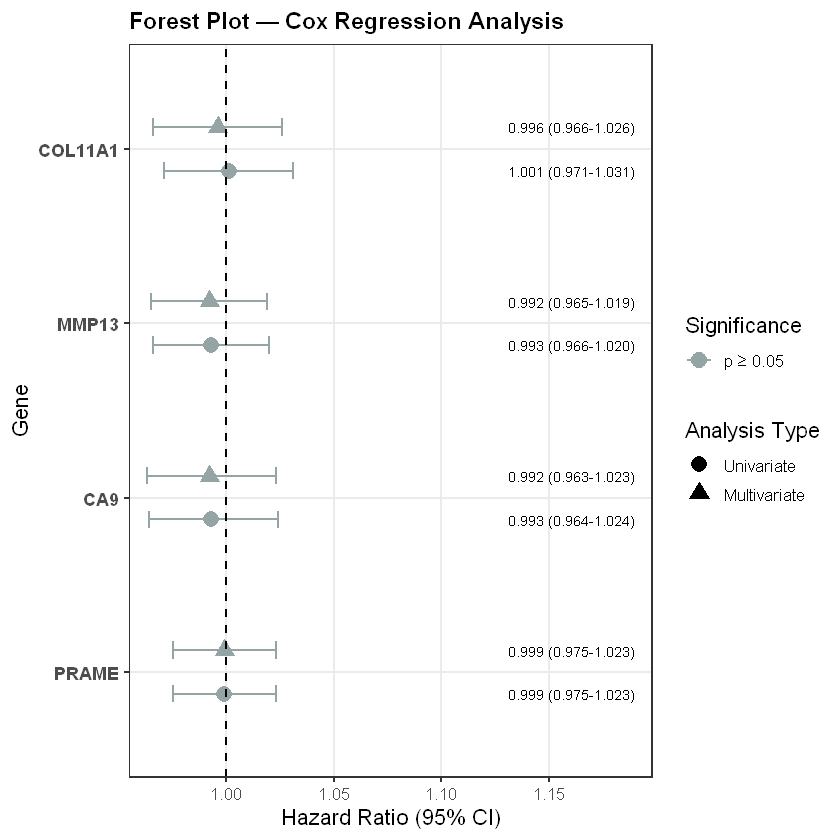

In [34]:
# --- PART B: Draw forest plot ---

forest_plot <- ggplot(
  all_cox_results,
  aes(x    = HR,
      y    = Gene,
      color = Significant,
      shape = Analysis)
) +

  # Point for HR
  geom_point(size = 4, position = position_dodge(width = 0.5)) +

  # Error bars for 95% CI
  geom_errorbarh(
    aes(xmin = CI_lower, xmax = CI_upper),
    height   = 0.2,
    position = position_dodge(width = 0.5),
    linewidth = 0.8
  ) +

  # Reference line at HR = 1
  geom_vline(
    xintercept = 1,
    linetype   = "dashed",
    color      = "black",
    linewidth  = 0.6
  ) +

  # Color scheme
  scale_color_manual(
    values = c(
      "p < 0.05" = "#E74C3C",   # red = significant
      "p ≥ 0.05" = "#95A5A6"    # grey = not significant
    )
  ) +

  # Shape scheme
  scale_shape_manual(
    values = c(
      "Univariate"   = 16,  # circle
      "Multivariate" = 17   # triangle
    )
  ) +

  # Labels
  labs(
    title    = "Forest Plot — Cox Regression Analysis",
    x        = "Hazard Ratio (95% CI)",
    y        = "Gene",
    color    = "Significance",
    shape    = "Analysis Type"
  ) +

  # Add HR and CI as text labels
  geom_text(
    aes(label = CI_label,
        x     = max(all_cox_results$CI_upper) + 0.1),
    position  = position_dodge(width = 0.5),
    hjust     = 0,
    size      = 3,
    color     = "black"
  ) +

  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(face = "bold", size = 11)
  ) +

  # Expand x axis to fit labels
  scale_x_continuous(
    expand = expansion(mult = c(0.05, 0.4))
  )

# Save plot
ggsave(
  "Forest_plot_Cox_regression.png",
  forest_plot,
  width  = 12,
  height = 7,
  dpi    = 200
)

cat("✔ Forest_plot_Cox_regression.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))
print(forest_plot)

In [35]:
# --- PART C: Separate univariate forest plot ---

uni_plot <- ggplot(
  all_cox_results[all_cox_results$Analysis == "Univariate", ],
  aes(x = HR, y = Gene, color = Significant)
) +
  geom_point(size = 4) +
  geom_errorbarh(
    aes(xmin = CI_lower, xmax = CI_upper),
    height    = 0.2,
    linewidth = 0.8
  ) +
  geom_vline(xintercept = 1, linetype = "dashed",
             color = "black", linewidth = 0.6) +
  scale_color_manual(values = c(
    "p < 0.05" = "#E74C3C",
    "p ≥ 0.05" = "#95A5A6"
  )) +
  labs(
    title    = "Univariate Cox Regression — Forest Plot",
    x        = "Hazard Ratio (95% CI)",
    y        = "Gene",
    color    = "Significance"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(face = "bold", size = 11)
  )

ggsave(
  "Forest_plot_Univariate.png",
  uni_plot,
  width  = 10,
  height = 6,
  dpi    = 200
)

cat("✔ Forest_plot_Univariate.png saved\n")

`height` was translated to `width`.


✔ Forest_plot_Univariate.png saved


In [36]:
# --- PART D: Separate multivariate forest plot ---

multi_plot <- ggplot(
  all_cox_results[all_cox_results$Analysis == "Multivariate", ],
  aes(x = HR, y = Gene, color = Significant)
) +
  geom_point(size = 4) +
  geom_errorbarh(
    aes(xmin = CI_lower, xmax = CI_upper),
    height    = 0.2,
    linewidth = 0.8
  ) +
  geom_vline(xintercept = 1, linetype = "dashed",
             color = "black", linewidth = 0.6) +
  scale_color_manual(values = c(
    "p < 0.05" = "#E74C3C",
    "p ≥ 0.05" = "#95A5A6"
  )) +
  labs(
    title    = "Multivariate Cox Regression — Forest Plot",
    x        = "Hazard Ratio (95% CI)",
    y        = "Gene",
    color    = "Significance"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    panel.grid.minor = element_blank(),
    axis.text.y      = element_text(face = "bold", size = 11)
  )

ggsave(
  "Forest_plot_Multivariate.png",
  multi_plot,
  width  = 10,
  height = 6,
  dpi    = 200
)

cat("✔ Forest_plot_Multivariate.png saved\n")

cat("\n============================================================\n")
cat("         COX REGRESSION ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. Cox_regression_results.tsv\n")
cat("  2. Forest_plot_Cox_regression.png\n")
cat("  3. Forest_plot_Univariate.png\n")
cat("  4. Forest_plot_Multivariate.png\n")
cat("============================================================\n")

`height` was translated to `width`.


✔ Forest_plot_Multivariate.png saved

         COX REGRESSION ANALYSIS COMPLETE
Files saved:
  1. Cox_regression_results.tsv
  2. Forest_plot_Cox_regression.png
  3. Forest_plot_Univariate.png
  4. Forest_plot_Multivariate.png


In [37]:
# ============================================================
# ROC ANALYSIS - STEP 1: Load Packages
# ============================================================

install.packages("pROC")

library(pROC)
library(ggplot2)
library(dplyr)

cat("✔ Packages loaded\n")

Installing package into 'C:/Users/aryan/AppData/Local/R/win-library/4.6'
(as 'lib' is unspecified)



package 'pROC' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\aryan\AppData\Local\Temp\RtmpC4mVLd\downloaded_packages


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:IRanges':

    cov, var


The following objects are masked from 'package:S4Vectors':

    cov, var


The following object is masked from 'package:BiocGenerics':

    var


The following objects are masked from 'package:stats':

    cov, smooth, var




✔ Packages loaded


In [38]:
# ============================================================
# ROC ANALYSIS - STEP 2: Prepare Data
# ============================================================

cat("=== Preparing ROC Data ===\n\n")

# Extract sample types from final matrix
# Position 14-15 in barcode: 01 = tumor, 11 = normal
sample_type_roc <- ifelse(
  substr(colnames(final_matrix), 14, 15) == "11",
  0,  # Normal = 0
  1   # Tumor  = 1
)

cat(sprintf("Total samples:   %d\n", length(sample_type_roc)))
cat(sprintf("Tumor samples:   %d\n", sum(sample_type_roc == 1)))
cat(sprintf("Normal samples:  %d\n", sum(sample_type_roc == 0)))

=== Preparing ROC Data ===

Total samples:   1139
Tumor samples:   1029
Normal samples:  110


In [39]:
# Extract expression for 4 genes
genes_roc <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Check all exist
cat("\nChecking genes:\n")
for (gene in genes_roc) {
  cat(sprintf("  %s: %s\n", gene,
              ifelse(gene %in% rownames(final_matrix),
                     "✔ Found", "✘ Not found")))
}

# Build ROC dataframe
roc_df <- data.frame(
  SampleType = sample_type_roc,
  t(final_matrix[genes_roc, , drop = FALSE])
)

cat(sprintf("\nROC dataframe: %d samples × %d columns\n",
            nrow(roc_df), ncol(roc_df)))
cat("Preview:\n")
print(head(roc_df[, 1:5], 3))


Checking genes:
  COL11A1: ✔ Found
  MMP13: ✔ Found
  CA9: ✔ Found
  PRAME: ✔ Found

ROC dataframe: 1139 samples × 5 columns
Preview:
                 SampleType  COL11A1    MMP13       CA9     PRAME
TCGA-60-2698-01A          1 8.669949 8.240953  9.264347  9.367222
TCGA-33-4589-01A          1 8.017031 7.937118 12.925912 -2.246946
TCGA-18-3410-01A          1 8.618831 4.347481 10.603692  8.985252


In [40]:
# ============================================================
# ROC ANALYSIS - STEP 3: Calculate AUC for each gene
# ============================================================

cat("=== Calculating AUC for Each Gene ===\n\n")

genes_roc <- c("COL11A1", "MMP13", "CA9", "PRAME")

# Store ROC objects and AUC values
roc_objects <- list()
auc_results <- data.frame()

for (gene in genes_roc) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Calculate ROC
  roc_obj <- roc(
    response  = roc_df$SampleType,
    predictor = roc_df[[gene]],
    direction = "auto",
    quiet     = TRUE
  )
  
  # Store ROC object
  roc_objects[[gene]] <- roc_obj
  
  # Extract AUC and CI
  auc_val <- as.numeric(auc(roc_obj))
  auc_ci  <- ci.auc(roc_obj, conf.level = 0.95)
  
  cat(sprintf("AUC:     %.4f\n", auc_val))
  cat(sprintf("95%% CI:  [%.4f, %.4f]\n",
              auc_ci[1], auc_ci[3]))
  cat(sprintf("Performance: %s\n\n",
              ifelse(auc_val >= 0.9, "Excellent (≥0.90)",
              ifelse(auc_val >= 0.8, "Good (≥0.80)",
              ifelse(auc_val >= 0.7, "Acceptable (≥0.70)",
              "Poor (<0.70)")))))
  
  # Store results
  auc_results <- rbind(auc_results, data.frame(
    Gene       = gene,
    AUC        = round(auc_val, 4),
    CI_lower   = round(auc_ci[1], 4),
    CI_upper   = round(auc_ci[3], 4),
    Performance = ifelse(auc_val >= 0.9, "Excellent",
                  ifelse(auc_val >= 0.8, "Good",
                  ifelse(auc_val >= 0.7, "Acceptable",
                  "Poor")))
  ))
}

cat("=== AUC Summary ===\n\n")
print(auc_results)

=== Calculating AUC for Each Gene ===

--- COL11A1 ---
AUC:     0.9518
95% CI:  [0.9351, 0.9685]
Performance: Excellent (≥0.90)

--- MMP13 ---
AUC:     0.8976
95% CI:  [0.8732, 0.9220]
Performance: Good (≥0.80)

--- CA9 ---
AUC:     0.9268
95% CI:  [0.9050, 0.9487]
Performance: Excellent (≥0.90)

--- PRAME ---
AUC:     0.9227
95% CI:  [0.9054, 0.9400]
Performance: Excellent (≥0.90)

=== AUC Summary ===

     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent


In [41]:
# ============================================================
# ROC STEP 3B: Plot individual ROC curves
# ============================================================

cat("\n=== Plotting Individual ROC Curves ===\n\n")

# Colors for each gene
gene_colors <- c(
  "COL11A1" = "#E74C3C",
  "MMP13"   = "#3498DB",
  "CA9"     = "#2ECC71",
  "PRAME"   = "#9B59B6"
)

# Plot each gene separately
for (gene in genes_roc) {
  
  roc_obj <- roc_objects[[gene]]
  auc_val <- as.numeric(auc(roc_obj))
  
  # Convert to dataframe for ggplot
  roc_plot_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities
  )
  
  p <- ggplot(roc_plot_df,
              aes(x = Specificity, y = Sensitivity)) +
    geom_line(color = gene_colors[gene],
              linewidth = 1.2) +
    geom_abline(slope = 1, intercept = 0,
                linetype = "dashed",
                color = "grey50") +
    annotate("text",
             x = 0.7, y = 0.2,
             label = sprintf("AUC = %.4f", auc_val),
             size = 5, fontface = "bold",
             color = gene_colors[gene]) +
    labs(
      title    = sprintf("ROC Curve — %s", gene),
      x        = "1 - Specificity (False Positive Rate)",
      y        = "Sensitivity (True Positive Rate)"
    ) +
    theme_bw(base_size = 13) +
    theme(
      plot.title    = element_text(face = "bold", size = 14),
      plot.subtitle = element_text(color = "gray40", size = 10),
      panel.grid.minor = element_blank()
    )
  
  # Save individual plot
  ggsave(
    sprintf("ROC_%s.png", gene),
    p,
    width  = 7,
    height = 6,
    dpi    = 200
  )
  
  cat(sprintf("✔ ROC_%s.png saved\n", gene))
}


=== Plotting Individual ROC Curves ===

✔ ROC_COL11A1.png saved
✔ ROC_MMP13.png saved
✔ ROC_CA9.png saved
✔ ROC_PRAME.png saved


In [42]:
# ============================================================
# ROC STEP 3C: Combined ROC plot all 4 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)
  
  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = sprintf("%s (AUC=%.4f)", gene, auc_val)
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)
}

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(slope = 1, intercept = 0,
              linetype = "dashed", color = "grey50") +
  scale_color_manual(values = c(
    sprintf("COL11A1 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["COL11A1"]])), 4)) = "#E74C3C",
    sprintf("MMP13 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["MMP13"]])), 4))   = "#3498DB",
    sprintf("CA9 (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["CA9"]])), 4))     = "#2ECC71",
    sprintf("PRAME (AUC=%.4f)",
            round(as.numeric(auc(roc_objects[["PRAME"]])), 4))   = "#9B59B6"
  )) +
  labs(
    title    = "ROC Curves — COL11A1, MMP13, CA9, PRAME",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
print(combined_roc_plot)

ERROR: Error in parse(text = input): <text>:32:66: unexpected '='
31:     sprintf("COL11A1 (AUC=%.4f)",
32:             round(as.numeric(auc(roc_objects[["COL11A1"]])), 4)) =
                                                                     ^


In [43]:
# ============================================================
# ROC STEP 3C FIXED: Combined ROC plot all 4 genes
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()

# Build color vector dynamically
color_vector <- c()

for (gene in genes_roc) {
  roc_obj <- roc_objects[[gene]]
  auc_val <- round(as.numeric(auc(roc_obj)), 4)

  # Gene label with AUC
  gene_label <- sprintf("%s (AUC=%.4f)", gene, auc_val)

  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = gene_label
  )
  combined_roc_df <- rbind(combined_roc_df, temp_df)

  # Add color
  color_vector[gene_label] <- gene_colors[gene]
}

# Plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x = Specificity, y = Sensitivity, color = Gene)
) +
  geom_line(linewidth = 1.2) +

ERROR: Error in parse(text = input): <text>:37:0: unexpected end of input
35: ) +
36:   geom_line(linewidth = 1.2) +
   ^


In [44]:
# ============================================================
# ROC STEP 3C FIXED: Combined ROC plot
# ============================================================

cat("\n=== Combined ROC Plot ===\n\n")

# Build combined dataframe
combined_roc_df <- data.frame()
color_vector    <- c()

gene_colors <- c(
  "COL11A1" = "#E74C3C",
  "MMP13"   = "#3498DB",
  "CA9"     = "#2ECC71",
  "PRAME"   = "#9B59B6"
)

for (gene in genes_roc) {
  roc_obj    <- roc_objects[[gene]]
  auc_val    <- round(as.numeric(auc(roc_obj)), 4)
  gene_label <- sprintf("%s (AUC=%.4f)", gene, auc_val)

  temp_df <- data.frame(
    Specificity = 1 - roc_obj$specificities,
    Sensitivity = roc_obj$sensitivities,
    Gene        = gene_label
  )

  combined_roc_df          <- rbind(combined_roc_df, temp_df)
  color_vector[gene_label] <- gene_colors[gene]
}

cat("Combined dataframe built\n")
cat(sprintf("Rows: %d\n", nrow(combined_roc_df)))


=== Combined ROC Plot ===

Combined dataframe built
Rows: 3422


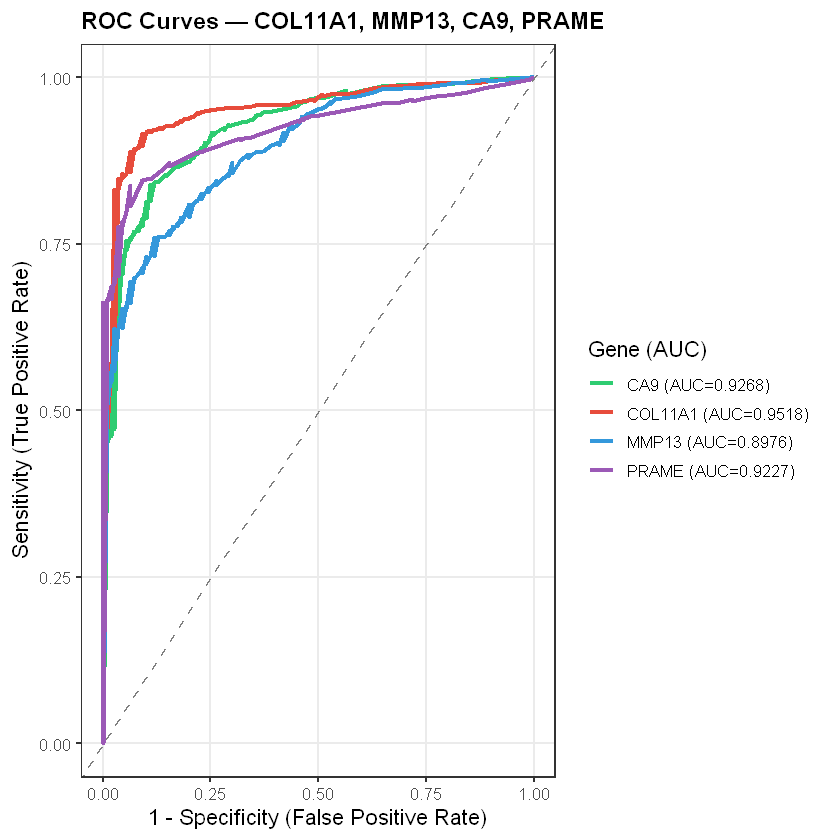

In [45]:
# Build plot
combined_roc_plot <- ggplot(
  combined_roc_df,
  aes(x     = Specificity,
      y     = Sensitivity,
      color = Gene)
) +
  geom_line(linewidth = 1.2) +
  geom_abline(
    slope     = 1,
    intercept = 0,
    linetype  = "dashed",
    color     = "grey50"
  ) +
  scale_color_manual(values = color_vector) +
  labs(
    title    = "ROC Curves — COL11A1, MMP13, CA9, PRAME",
    x        = "1 - Specificity (False Positive Rate)",
    y        = "Sensitivity (True Positive Rate)",
    color    = "Gene (AUC)"
  ) +
  theme_bw(base_size = 13) +
  theme(
    plot.title       = element_text(face = "bold", size = 14),
    plot.subtitle    = element_text(color = "gray40", size = 10),
    legend.position  = "right",
    panel.grid.minor = element_blank()
  )

print(combined_roc_plot)

In [46]:
# Save plot
ggsave(
  "ROC_Combined_all_genes.png",
  combined_roc_plot,
  width  = 10,
  height = 7,
  dpi    = 200
)

cat("✔ ROC_Combined_all_genes.png saved\n")
cat(sprintf("  Location: %s\n", getwd()))

✔ ROC_Combined_all_genes.png saved
  Location: C:/jupyter demo


In [47]:
# Check if survival_df exists and has required columns
cat("=== Checking Survival Data ===\n\n")

cat(sprintf("survival_df exists: %s\n", exists("survival_df")))

if (exists("survival_df")) {
  cat(sprintf("Rows: %d\n", nrow(survival_df)))
  
  # Check required columns
  needed <- c("OS_time", "OS_event", "OS_months",
              "COL11A1_group", "MMP13_group",
              "CA9_group", "PRAME_group")
  
  for (col in needed) {
    cat(sprintf("  %s: %s\n", col,
                ifelse(col %in% colnames(survival_df),
                       "✔ EXISTS", "✘ MISSING")))
  }
}

=== Checking Survival Data ===

survival_df exists: TRUE
Rows: 1118
  OS_time: ✔ EXISTS
  OS_event: ✔ EXISTS
  OS_months: ✔ EXISTS
  COL11A1_group: ✔ EXISTS
  MMP13_group: ✔ EXISTS
  CA9_group: ✔ EXISTS
  PRAME_group: ✔ EXISTS


In [48]:
# ============================================================
# KM PLOT - STEP 1: Individual KM Curves for Each Gene
# ============================================================

cat("=== Generating KM Plots ===\n\n")

genes_km <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_km) {
  
  cat(sprintf("--- %s ---\n", gene))
  
  # Create survival object
  surv_obj <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  
  # Group column name
  group_col <- paste0(gene, "_group")
  
  # Fit KM model
  km_fit <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  
  # Log-rank test
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  
  # Extract p-value
  pval <- 1 - pchisq(log_rank$chisq, df = 1)
  
  cat(sprintf("Log-rank p-value: %.4f\n", pval))
  cat(sprintf("Significant: %s\n\n",
              ifelse(pval < 0.05, "✔ YES", "✘ NO")))
  
  # Draw KM plot
  km_plot <- ggsurvplot(
    km_fit,
    data         = survival_df,
    pval         = TRUE,
    pval.method  = TRUE,
    conf.int     = TRUE,
    risk.table   = TRUE,
    risk.table.height = 0.25,
    palette      = c("#E74C3C", "#3498DB"),
    legend.labs  = c(
      paste0(gene, " HIGH"),
      paste0(gene, " LOW")
    ),
    title        = sprintf(
      "KM Survival Curve — %s Expression", gene),
    xlab         = "Time (Months)",
    ylab         = "Overall Survival Probability",
    legend.title = "Expression Group",
    ggtheme      = theme_bw(base_size = 13)
  )
  
  # Save plot
  png(
    filename = sprintf("KM_%s_OS.png", gene),
    width    = 2400,
    height   = 2000,
    res      = 200
  )
  print(km_plot)
  dev.off()
  
  cat(sprintf("✔ KM_%s_OS.png saved\n\n", gene))
}

=== Generating KM Plots ===

--- COL11A1 ---
Log-rank p-value: 0.1554
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_COL11A1_OS.png saved

--- MMP13 ---
Log-rank p-value: 0.0465
Significant: ✔ YES



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_MMP13_OS.png saved

--- CA9 ---
Log-rank p-value: 0.2405
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_CA9_OS.png saved

--- PRAME ---
Log-rank p-value: 0.5953
Significant: ✘ NO



Ignoring unknown labels:
• colour : "Expression Group"


✔ KM_PRAME_OS.png saved



=== Combined KM Plot ===

✔ KM_Combined_all_genes.png saved


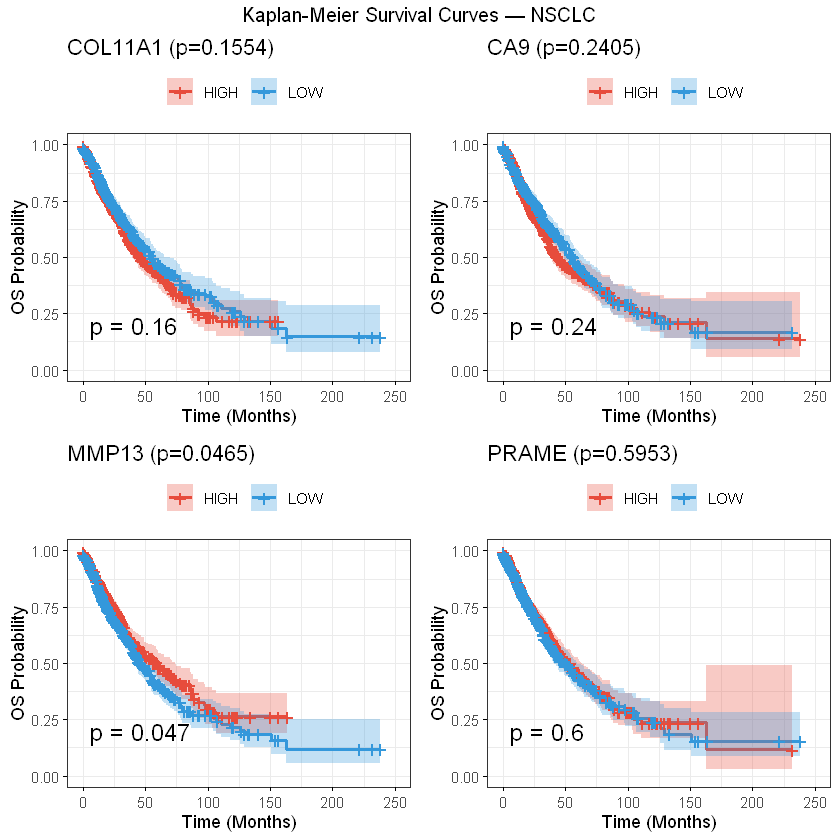

In [49]:
# ============================================================
# KM PLOT - STEP 2: Combined KM plot all 4 genes
# ============================================================

cat("=== Combined KM Plot ===\n\n")

# Create 2x2 panel of all 4 genes
km_list <- list()

for (gene in genes_km) {
  
  surv_obj  <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  group_col <- paste0(gene, "_group")
  
  km_fit <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  pval <- 1 - pchisq(log_rank$chisq, df = 1)
  
  km_list[[gene]] <- ggsurvplot(
    km_fit,
    data         = survival_df,
    pval         = TRUE,
    conf.int     = TRUE,
    risk.table   = FALSE,
    palette      = c("#E74C3C", "#3498DB"),
    legend.labs  = c("HIGH", "LOW"),
    title        = sprintf("%s (p=%.4f)", gene, pval),
    xlab         = "Time (Months)",
    ylab         = "OS Probability",
    legend.title = "",
    ggtheme      = theme_bw(base_size = 11)
  )
}

# Arrange in 2x2 panel
combined_km <- arrange_ggsurvplots(
  km_list,
  nrow  = 2,
  ncol  = 2,
  title = "Kaplan-Meier Survival Curves — NSCLC"
)

# Save combined plot
ggsave(
  "KM_Combined_all_genes.png",
  combined_km,
  width  = 14,
  height = 12,
  dpi    = 200
)

cat("✔ KM_Combined_all_genes.png saved\n")

In [50]:
# ============================================================
# KM PLOT - STEP 3: Summary of log-rank results
# ============================================================

cat("\n=== KM Survival Analysis Summary ===\n\n")

km_summary <- data.frame()

for (gene in genes_km) {
  
  surv_obj  <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event
  )
  group_col <- paste0(gene, "_group")
  
  km_fit   <- survfit(
    surv_obj ~ survival_df[[group_col]]
  )
  log_rank <- survdiff(
    surv_obj ~ survival_df[[group_col]]
  )
  pval     <- 1 - pchisq(log_rank$chisq, df = 1)
  
  # Median survival for each group
  med_surv <- summary(km_fit)$table
  
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05, "YES", "NO")
  ))
}

cat("Log-rank test results:\n\n")
print(km_summary)

# Save summary
write.table(
  km_summary,
  file      = "KM_logrank_summary.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("\n✔ KM_logrank_summary.tsv saved\n")
cat(sprintf("  Location: %s\n", getwd()))

cat("\n============================================================\n")
cat("         KM SURVIVAL ANALYSIS COMPLETE\n")
cat("============================================================\n")
cat("Files saved:\n")
cat("  1. KM_COL11A1_OS.png\n")
cat("  2. KM_MMP13_OS.png\n")
cat("  3. KM_CA9_OS.png\n")
cat("  4. KM_PRAME_OS.png\n")
cat("  5. KM_Combined_all_genes.png\n")
cat("  6. KM_logrank_summary.tsv\n")
cat("============================================================\n")


=== KM Survival Analysis Summary ===

Log-rank test results:

     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO

✔ KM_logrank_summary.tsv saved
  Location: C:/jupyter demo

         KM SURVIVAL ANALYSIS COMPLETE
Files saved:
  1. KM_COL11A1_OS.png
  2. KM_MMP13_OS.png
  3. KM_CA9_OS.png
  4. KM_PRAME_OS.png
  5. KM_Combined_all_genes.png
  6. KM_logrank_summary.tsv


In [51]:
# Get exact numbers for report
cat("=== Numbers for Report ===\n\n")

# Cox regression results
cat("--- Cox Regression ---\n")
print(all_cox_results[, c("Gene", "HR", "CI_lower",
                           "CI_upper", "P_value", "Analysis")])

# KM results
cat("\n--- KM Log-rank Results ---\n")
print(km_summary)

# AUC results
cat("\n--- ROC AUC Results ---\n")
print(auc_results)

# Sample counts
cat("\n--- Sample Counts ---\n")
cat(sprintf("Total patients: %d\n", nrow(survival_df)))
cat(sprintf("Dead:           %d\n",
            sum(survival_df$OS_event == 1)))
cat(sprintf("Alive:          %d\n",
            sum(survival_df$OS_event == 0)))

=== Numbers for Report ===

--- Cox Regression ---
     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 1.001    0.971    1.031  0.9667   Univariate
2   MMP13 0.993    0.966    1.020  0.5991   Univariate
3     CA9 0.993    0.964    1.024  0.6648   Univariate
4   PRAME 0.999    0.975    1.023  0.9170   Univariate
5 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
6   MMP13 0.992    0.965    1.019  0.5350 Multivariate
7     CA9 0.992    0.963    1.023  0.6184 Multivariate
8   PRAME 0.999    0.975    1.023  0.9069 Multivariate

--- KM Log-rank Results ---
     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO

--- ROC AUC Results ---
     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent

--- 

In [1]:
# ============================================================
# Complete Status of 4 Genes
# ============================================================

cat("=== Complete Gene Status Report ===\n\n")

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_check) {
  
  cat(sprintf("============ %s ============\n", gene))
  
  # --- DEG Status ---
  cat("DEG Analysis:\n")
  if (gene %in% rownames(deg_results)) {
    cat(sprintf("  logFC:        %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("  adj.P.Val:    %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("  Status:       %s\n",
                as.character(deg_results[gene, "Status"])))
  }
  
  # --- KM Survival ---
  cat("KM Survival:\n")
  if (gene %in% km_summary$Gene) {
    km_row <- km_summary[km_summary$Gene == gene, ]
    cat(sprintf("  Log-rank p:   %.4f\n", km_row$LogRank_p))
    cat(sprintf("  Significant:  %s\n", km_row$Significant))
  }
  
  # --- Cox Regression ---
  cat("Cox Regression:\n")
  uni_row   <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Univariate", ]
  multi_row <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Multivariate", ]
  
  cat(sprintf("  Univariate HR:    %.3f [%.3f-%.3f] p=%.4f\n",
              uni_row$HR, uni_row$CI_lower,
              uni_row$CI_upper, uni_row$P_value))
  cat(sprintf("  Multivariate HR:  %.3f [%.3f-%.3f] p=%.4f\n",
              multi_row$HR, multi_row$CI_lower,
              multi_row$CI_upper, multi_row$P_value))
  
  # --- ROC ---
  cat("ROC Analysis:\n")
  if (gene %in% auc_results$Gene) {
    auc_row <- auc_results[auc_results$Gene == gene, ]
    cat(sprintf("  AUC:          %.4f [%.4f-%.4f]\n",
                auc_row$AUC, auc_row$CI_lower,
                auc_row$CI_upper))
    cat(sprintf("  Performance:  %s\n", auc_row$Performance))
  }
  
  cat("\n")
}

=== Complete Gene Status Report ===

============ COL11A1 ============
DEG Analysis:


ERROR: Error: object 'deg_results' not found


In [2]:
# Quick rebuild
library(limma)
library(edgeR)
library(data.table)
library(dplyr)
library(survival)
library(survminer)
library(pROC)

cat("✔ Libraries loaded\n")


Attaching package: 'data.table'


The following object is masked from 'package:base':

    %notin%



Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: ggplot2

Loading required package: ggpubr


Attaching package: 'survminer'


The following object is masked from 'package:survival':

    myeloma


Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var




✔ Libraries loaded


In [3]:
# Load final matrix
final_df <- read.table(
  "C:/Users/aryan/Downloads/TCGA_LUSC_LUAD_final_expression.tsv",
  header      = TRUE,
  sep         = "\t",
  row.names   = 1,
  check.names = FALSE
)
final_matrix <- as.matrix(final_df)
cat(sprintf("✔ final_matrix: %d genes × %d samples\n",
            nrow(final_matrix), ncol(final_matrix)))

✔ final_matrix: 36650 genes × 1139 samples


In [4]:
# Rebuild deg_results
deg_results <- readRDS("C:/jupyter demo/deg_results.rds")
deg_results$Status <- "Not Significant"
deg_results$Status[
  deg_results$logFC > 0.5 &
  deg_results$adj.P.Val < 0.05] <- "Upregulated"
deg_results$Status[
  deg_results$logFC < -0.5 &
  deg_results$adj.P.Val < 0.05] <- "Downregulated"
deg_results$Status <- factor(
  deg_results$Status,
  levels = c("Upregulated", "Downregulated",
             "Not Significant"))
cat(sprintf("✔ deg_results: %d genes\n", nrow(deg_results)))

✔ deg_results: 36650 genes


In [5]:
# Rebuild survival data
lusc_clinical <- read.table(
  "C:/jupyter demo/LUSC_clinical.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)
luad_clinical <- read.table(
  "C:/jupyter demo/LUAD_clinical.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

# Common columns
common_cols <- intersect(
  colnames(lusc_clinical),
  colnames(luad_clinical)
)
lusc_clinical$Dataset <- "LUSC"
luad_clinical$Dataset <- "LUAD"
combined_clinical <- rbind(
  lusc_clinical[, c(common_cols, "Dataset")],
  luad_clinical[, c(common_cols, "Dataset")]
)

# Survival variables
combined_clinical$OS_time <- ifelse(
  combined_clinical$vital_status == "Dead",
  as.numeric(combined_clinical$days_to_death),
  as.numeric(combined_clinical$days_to_last_follow_up)
)
combined_clinical$OS_event <- ifelse(
  combined_clinical$vital_status == "Dead", 1, 0)
combined_clinical$OS_months <- combined_clinical$OS_time / 30.44
combined_clinical <- combined_clinical[
  !is.na(combined_clinical$OS_time) &
  combined_clinical$OS_time > 0, ]

cat(sprintf("✔ Clinical data: %d patients\n",
            nrow(combined_clinical)))

✔ Clinical data: 1005 patients


In [6]:
# Extract gene expression and merge
genes_of_interest <- c("COL11A1", "MMP13", "CA9", "PRAME")

expr_subset <- t(final_matrix[genes_of_interest, , drop = FALSE])
expr_df <- as.data.frame(expr_subset)
expr_df$submitter_id <- substr(rownames(expr_df), 1, 12)

survival_df <- merge(
  combined_clinical,
  expr_df,
  by = "submitter_id"
)

# Stratify by median
for (gene in genes_of_interest) {
  median_val <- median(survival_df[[gene]], na.rm = TRUE)
  survival_df[[paste0(gene, "_group")]] <- ifelse(
    survival_df[[gene]] >= median_val, "HIGH", "LOW")
}

cat(sprintf("✔ survival_df: %d patients\n", nrow(survival_df)))

✔ survival_df: 1118 patients


In [7]:
# Rebuild KM summary
km_summary <- data.frame()

for (gene in genes_of_interest) {
  surv_obj  <- Surv(
    time  = survival_df$OS_months,
    event = survival_df$OS_event)
  group_col <- paste0(gene, "_group")
  log_rank  <- survdiff(
    surv_obj ~ survival_df[[group_col]])
  pval      <- 1 - pchisq(log_rank$chisq, df = 1)
  km_summary <- rbind(km_summary, data.frame(
    Gene        = gene,
    LogRank_p   = round(pval, 4),
    Significant = ifelse(pval < 0.05, "YES", "NO")
  ))
}

cat("✔ KM summary ready\n")
print(km_summary)

✔ KM summary ready
     Gene LogRank_p Significant
1 COL11A1    0.1554          NO
2   MMP13    0.0465         YES
3     CA9    0.2405          NO
4   PRAME    0.5953          NO


In [8]:
# Rebuild Cox results
all_cox_results <- read.table(
  "C:/jupyter demo/Cox_regression_results.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

cat("✔ Cox results loaded\n")
print(all_cox_results)

✔ Cox results loaded
     Gene    HR CI_lower CI_upper P_value     Analysis
1 COL11A1 1.001    0.971    1.031  0.9667   Univariate
2   MMP13 0.993    0.966    1.020  0.5991   Univariate
3     CA9 0.993    0.964    1.024  0.6648   Univariate
4   PRAME 0.999    0.975    1.023  0.9170   Univariate
5 COL11A1 0.996    0.966    1.026  0.7866 Multivariate
6   MMP13 0.992    0.965    1.019  0.5350 Multivariate
7     CA9 0.992    0.963    1.023  0.6184 Multivariate
8   PRAME 0.999    0.975    1.023  0.9069 Multivariate


In [9]:
# Rebuild AUC results
auc_results <- read.table(
  "C:/jupyter demo/ROC_AUC_results.tsv",
  header      = TRUE,
  sep         = "\t",
  check.names = FALSE
)

cat("✔ AUC results loaded\n")
print(auc_results)

Warning message in file(file, "rt"):
"cannot open file 'C:/jupyter demo/ROC_AUC_results.tsv': No such file or directory"


ERROR: Error in file(file, "rt"): cannot open the connection


In [10]:
# Rebuild AUC results manually from known values
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good", "Excellent", "Excellent")
)

cat("✔ AUC results rebuilt\n")
print(auc_results)

# Save for future use
write.table(
  auc_results,
  file      = "C:/jupyter demo/ROC_AUC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ ROC_AUC_results.tsv saved\n")# Rebuild AUC results manually from known values
auc_results <- data.frame(
  Gene        = c("COL11A1", "MMP13", "CA9", "PRAME"),
  AUC         = c(0.9518, 0.8976, 0.9268, 0.9227),
  CI_lower    = c(0.9351, 0.8732, 0.9050, 0.9054),
  CI_upper    = c(0.9685, 0.9220, 0.9487, 0.9400),
  Performance = c("Excellent", "Good", "Excellent", "Excellent")
)

cat("✔ AUC results rebuilt\n")
print(auc_results)

# Save for future use
write.table(
  auc_results,
  file      = "C:/jupyter demo/ROC_AUC_results.tsv",
  sep       = "\t",
  row.names = FALSE,
  quote     = FALSE
)

cat("✔ ROC_AUC_results.tsv saved\n")

✔ AUC results rebuilt
     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent
✔ ROC_AUC_results.tsv saved
✔ AUC results rebuilt
     Gene    AUC CI_lower CI_upper Performance
1 COL11A1 0.9518   0.9351   0.9685   Excellent
2   MMP13 0.8976   0.8732   0.9220        Good
3     CA9 0.9268   0.9050   0.9487   Excellent
4   PRAME 0.9227   0.9054   0.9400   Excellent
✔ ROC_AUC_results.tsv saved


In [11]:
# Final check
cat("\n=== All Objects Ready ===\n")
cat(sprintf("deg_results:   %s\n", exists("deg_results")))
cat(sprintf("survival_df:   %s\n", exists("survival_df")))
cat(sprintf("km_summary:    %s\n", exists("km_summary")))
cat(sprintf("all_cox_results: %s\n", exists("all_cox_results")))
cat(sprintf("auc_results:   %s\n", exists("auc_results")))


=== All Objects Ready ===
deg_results:   TRUE
survival_df:   TRUE
km_summary:    TRUE
all_cox_results: TRUE
auc_results:   TRUE


In [12]:
# ============================================================
# Complete Status of 4 Genes
# ============================================================

cat("=== Complete Gene Status Report ===\n\n")

genes_check <- c("COL11A1", "MMP13", "CA9", "PRAME")

for (gene in genes_check) {
  
  cat(sprintf("============ %s ============\n", gene))
  
  # --- DEG Status ---
  cat("DEG Analysis:\n")
  if (gene %in% rownames(deg_results)) {
    cat(sprintf("  logFC:        %.4f\n",
                deg_results[gene, "logFC"]))
    cat(sprintf("  adj.P.Val:    %.2e\n",
                deg_results[gene, "adj.P.Val"]))
    cat(sprintf("  Status:       %s\n",
                as.character(deg_results[gene, "Status"])))
  }
  
  # --- KM Survival ---
  cat("KM Survival:\n")
  if (gene %in% km_summary$Gene) {
    km_row <- km_summary[km_summary$Gene == gene, ]
    cat(sprintf("  Log-rank p:   %.4f\n", km_row$LogRank_p))
    cat(sprintf("  Significant:  %s\n", km_row$Significant))
  }
  
  # --- Cox Regression ---
  cat("Cox Regression:\n")
  uni_row   <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Univariate", ]
  multi_row <- all_cox_results[
    all_cox_results$Gene == gene &
    all_cox_results$Analysis == "Multivariate", ]
  
  cat(sprintf("  Univariate HR:    %.3f [%.3f-%.3f] p=%.4f\n",
              uni_row$HR, uni_row$CI_lower,
              uni_row$CI_upper, uni_row$P_value))
  cat(sprintf("  Multivariate HR:  %.3f [%.3f-%.3f] p=%.4f\n",
              multi_row$HR, multi_row$CI_lower,
              multi_row$CI_upper, multi_row$P_value))
  
  # --- ROC ---
  cat("ROC Analysis:\n")
  if (gene %in% auc_results$Gene) {
    auc_row <- auc_results[auc_results$Gene == gene, ]
    cat(sprintf("  AUC:          %.4f [%.4f-%.4f]\n",
                auc_row$AUC, auc_row$CI_lower,
                auc_row$CI_upper))
    cat(sprintf("  Performance:  %s\n", auc_row$Performance))
  }
  
  cat("\n")
}

=== Complete Gene Status Report ===

============ COL11A1 ============
DEG Analysis:
  logFC:        0.6296
  adj.P.Val:    1.69e-25
  Status:       Upregulated
KM Survival:
  Log-rank p:   0.1554
  Significant:  NO
Cox Regression:
  Univariate HR:    1.001 [0.971-1.031] p=0.9667
  Multivariate HR:  0.996 [0.966-1.026] p=0.7866
ROC Analysis:
  AUC:          0.9518 [0.9351-0.9685]
  Performance:  Excellent

============ MMP13 ============
DEG Analysis:
  logFC:        0.6327
  adj.P.Val:    1.15e-21
  Status:       Upregulated
KM Survival:
  Log-rank p:   0.0465
  Significant:  YES
Cox Regression:
  Univariate HR:    0.993 [0.966-1.020] p=0.5991
  Multivariate HR:  0.992 [0.965-1.019] p=0.5350
ROC Analysis:
  AUC:          0.8976 [0.8732-0.9220]
  Performance:  Good

============ CA9 ============
DEG Analysis:
  logFC:        0.6409
  adj.P.Val:    1.70e-26
  Status:       Upregulated
KM Survival:
  Log-rank p:   0.2405
  Significant:  NO
Cox Regression:
  Univariate HR:    0.993 [0.964